Install Dependencies

In [1]:
!pip install catboost quantile-forest optuna tqdm shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.1 MB/s eta 0:00:00


Imports

In [2]:
import kagglehub, os, warnings, time, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests, shap
from io import StringIO
from scipy.optimize import minimize
from scipy.stats import rankdata
from scipy.interpolate import interp1d
from matplotlib.patches import Patch

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgboost_lib
from xgboost import XGBRegressor
import lightgbm as lightgbm_lib
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor
from quantile_forest import RandomForestQuantileRegressor

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, BayesianRidge, HuberRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    HistGradientBoostingRegressor, StackingRegressor, GradientBoostingClassifier,
)
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, cross_val_score,
    KFold, StratifiedKFold,
)
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    median_absolute_error, explained_variance_score,
    mean_squared_log_error, max_error, roc_auc_score,
)
from scipy.stats import randint as sp_randint
from tqdm.auto import tqdm
import joblib

warnings.filterwarnings('ignore')
print("All libraries loaded.")

All libraries loaded.


Configuration

In [3]:
# ---------------------------------------------------------------------------
# Central configuration. Adjust these values to control the pipeline
# without hunting through the notebook.
# ---------------------------------------------------------------------------
CFG = dict(
    # Data
    test_size        = 0.20,
    random_state     = 42,
    outlier_pct      = 0.01,   # trim bottom/top 1% from training set

    # CV
    n_folds          = 5,      # KFold splits used throughout
    val_fraction     = 0.10,   # hold-out for early stopping

    # Trees (untuned baselines)
    n_rf             = 300,
    n_et             = 300,
    n_rfq            = 300,
    n_hgb_max        = 1000,

    # Boosting (with early stopping)
    n_xgb_max        = 1000,
    n_lgbm_max       = 1000,
    n_cat_max        = 1000,
    early_stop       = 50,

    # Optuna
    optuna_xgb       = 80,
    optuna_lgbm      = 80,
    optuna_cat       = 50,

    # SHAP selection
    shap_keep_pct    = 0.90,   # keep features covering 90% cumulative importance

    # Pseudo-labeling
    pseudo_conf_thr  = 0.08,   # keep test rows where model std < 8% of prediction
    pseudo_weight    = 0.5,    # sample_weight assigned to pseudo-labeled rows
)
print("Config loaded.")
for k, v in CFG.items():
    print(f"  {k:<22}: {v}")

Config loaded.
  test_size             : 0.2
  random_state          : 42
  outlier_pct           : 0.01
  n_folds               : 5
  val_fraction          : 0.1
  n_rf                  : 300
  n_et                  : 300
  n_rfq                 : 300
  n_hgb_max             : 1000
  n_xgb_max             : 1000
  n_lgbm_max            : 1000
  n_cat_max             : 1000
  early_stop            : 50
  optuna_xgb            : 80
  optuna_lgbm           : 80
  optuna_cat            : 50
  shap_keep_pct         : 0.9
  pseudo_conf_thr       : 0.08
  pseudo_weight         : 0.5


Progress Bar Utilities

In [4]:
class XGBTqdmCallback(xgboost_lib.callback.TrainingCallback):
    # Uses .n = epoch+1 (absolute), so bar never drifts with early stopping.
    def __init__(self, total, desc="XGBoost"):
        super().__init__()
        self.pbar = tqdm(total=total, desc=desc, unit="tree",
                         bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]")
    def after_iteration(self, model, epoch, evals_log):
        self.pbar.n = epoch + 1
        if evals_log:
            try:
                data = next(iter(evals_log.values()))
                m, v = next(iter(data.items()))
                self.pbar.set_postfix({m[:8]: f"{v[-1]:.4f}"}, refresh=False)
            except (StopIteration, IndexError):
                pass
        self.pbar.refresh()
        return False
    def after_training(self, model):
        self.pbar.n = self.pbar.total
        self.pbar.refresh(); self.pbar.close()
        return model

def lgbm_tqdm_cb(pbar):
    def _cb(env):
        pbar.n = env.iteration + 1
        if env.evaluation_result_list:
            pbar.set_postfix(
                {env.evaluation_result_list[-1][1][:8]: f"{env.evaluation_result_list[-1][2]:.4f}"},
                refresh=False)
        pbar.refresh()
    _cb.order = 10
    return _cb

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class _CB(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *a, **kw):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*a, **kw)
    old = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = _CB
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old
        tqdm_object.close()

def time_section(label):
    class _T:
        def __enter__(self): self._t = time.perf_counter()
        def __exit__(self, *_): print(f"  [{label}] {time.perf_counter()-self._t:.1f}s")
    return _T()

print("Progress bar utilities ready.")

Progress bar utilities ready.


Data Loading

In [5]:
# REPRODUCIBILITY NOTE:
# fetch_data() tries four sources in order (live web first, Kaggle fallback).
# If aijobs.net is reachable at run-time you may get a different (newer/larger)
# dataset than the Kaggle fallback. For reproducible results:
#   - Set FORCE_KAGGLE_ONLY = True to skip live sources.
#   - Record the exact row count printed after loading and pin it in the paper.
#   - Pin KAGGLE_LATEST to the exact dataset version hash you used.
FORCE_KAGGLE_ONLY = False  # Set True for reproducibility

AIJOBS_URL    = 'https://aijobs.net/salaries/download/salaries.csv'
AIJOBS_MIRROR = 'https://raw.githubusercontent.com/foorilla/ai-jobs-net-salaries/main/salaries.csv'
KAGGLE_LATEST = 'mohankrishnathalla/global-ai-and-data-jobs-salary-dataset'
KAGGLE_OLD    = 'adilshamim8/salaries-for-data-science-jobs'
KAGGLE_CSV    = 'salaries.csv'

# Required columns and safe fallback values if columns are missing.
# The notebook will warn and fill defaults rather than crashing.
REQUIRED_COLS = {
    'salary_usd':       None,         # must exist; no fallback
    'experience_level': 'MI',         # mid-level if unknown
    'job_title':        'Unknown',
    'company_size':     'M',
    'company_location': 'US',
    'employee_residence':'US',
    'remote_ratio':     50,
    'work_year':        2023,
}

def defensive_fill(df):
    for col, default in REQUIRED_COLS.items():
        if col not in df.columns:
            if default is None:
                raise ValueError(f"Column '{col}' is required and has no fallback.")
            print(f"  WARNING: '{col}' missing -- filling with default '{default}'")
            df[col] = default
    return df

def normalize_schema(df):
    if 'salary_in_usd' in df.columns and 'salary_usd' not in df.columns:
        df = df.rename(columns={'salary_in_usd': 'salary_usd'})
    df = defensive_fill(df)
    df['years_experience'] = df['experience_level'].map(
        {'EN':1,'MI':3,'SE':7,'EX':12}).fillna(3)
    return df.dropna(subset=['salary_usd']).query('salary_usd > 0').reset_index(drop=True)

def validate_schema(df, label):
    col = 'salary_in_usd' if 'salary_in_usd' in df.columns else 'salary_usd'
    if col not in df.columns:
        raise ValueError(f"{label} -- salary column missing")

def fetch_data():
    if FORCE_KAGGLE_ONLY:
        print("  FORCE_KAGGLE_ONLY=True: skipping live sources for reproducibility.")
        sources = [
            ("Kaggle (2026 dataset)", lambda: pd.read_csv(os.path.join(kagglehub.dataset_download(KAGGLE_LATEST), KAGGLE_CSV))),
            ("Kaggle (fallback)",     lambda: pd.read_csv(os.path.join(kagglehub.dataset_download(KAGGLE_OLD),    KAGGLE_CSV))),
        ]
    else:
        sources = [
        ("aijobs.net (direct)",   lambda: pd.read_csv(StringIO(requests.get(AIJOBS_URL,    timeout=15).text))),
        ("aijobs.net (mirror)",   lambda: pd.read_csv(StringIO(requests.get(AIJOBS_MIRROR, timeout=15).text))),
        ("Kaggle (2026 dataset)", lambda: pd.read_csv(os.path.join(kagglehub.dataset_download(KAGGLE_LATEST), KAGGLE_CSV))),
        ("Kaggle (fallback)",     lambda: pd.read_csv(os.path.join(kagglehub.dataset_download(KAGGLE_OLD),    KAGGLE_CSV))),
        ]
    for label, fn in sources:
        print(f"  Trying {label}...")
        try:
            df = fn()
            validate_schema(df, label)
            df = normalize_schema(df)
            print(f"  Loaded {df.shape[0]:,} rows")
            return df, label
        except Exception as e:
            print(f"  Failed: {e}")
    raise RuntimeError("All sources failed.")

print("Fetching salary dataset...")
with time_section("Data Loading"):
    df, source_name = fetch_data()

print(f"Source  : {source_name}")
print(f"Rows    : {df.shape[0]:,}")
print(f"Salary  : ${df['salary_usd'].min():,.0f} to ${df['salary_usd'].max():,.0f}")
print(f"Columns : {list(df.columns)}")

Fetching salary dataset...
  Trying aijobs.net (direct)...
  Failed: aijobs.net (direct) -- salary column missing
  Trying aijobs.net (mirror)...
  Loaded 151,445 rows
  [Data Loading] 3.0s
Source  : aijobs.net (mirror)
Rows    : 151,445
Salary  : $15,000 to $800,000
Columns : ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size', 'years_experience']


Feature Engineering

In [6]:
with time_section("Feature Engineering"):
    df_fe = df.copy()

    # 1. JOB TITLE CLUSTERING (8 categories)
    #    Reduces hundreds of unique titles to 8 salary-predictive clusters.
    #    Paper reference: "domain-informed categorical feature reduction."
    def job_cluster(title):
        t = str(title).lower()
        if any(x in t for x in ['machine learning','ml engineer','deep learning',
                                  'ai engineer','nlp','llm','generative','neural','computer vision']):
            return 'ML_AI_Engineer'
        if any(x in t for x in ['data scientist','data science','applied scientist','quantitative']):
            return 'Data_Scientist'
        if any(x in t for x in ['data engineer','pipeline','etl','databricks','spark','kafka']):
            return 'Data_Engineer'
        if any(x in t for x in ['analyst','analytics','business intelligence','bi developer']):
            return 'Analyst'
        if any(x in t for x in ['manager','director','head of','vp ','chief','principal','lead ','staff ']):
            return 'Manager_Lead'
        if any(x in t for x in ['architect','cloud','devops','mlops','site reliability']):
            return 'Architect_Ops'
        if any(x in t for x in ['research','scientist','statistician','modeler']):
            return 'Researcher'
        return 'Other'
    df_fe['job_cluster'] = df_fe['job_title'].apply(job_cluster)

    # 2. LOCATION GROUPING -- collapse rare countries to 'Other'
    for sc, dc in [('company_location','location_group'),('employee_residence','residence_group')]:
        if sc in df_fe.columns:
            top = df_fe[sc].value_counts().nlargest(15).index
            df_fe[dc] = df_fe[sc].where(df_fe[sc].isin(top), other='Other')

    # 3. EXPERIENCE FLAGS
    df_fe['is_executive']    = (df_fe['experience_level']=='EX').astype(int)
    df_fe['is_entry']        = (df_fe['experience_level']=='EN').astype(int)
    df_fe['is_senior']       = (df_fe['experience_level']=='SE').astype(int)
    df_fe['is_fully_remote'] = (df_fe.get('remote_ratio', pd.Series(50,index=df_fe.index)) == 100).astype(int)

    # 4. RECENCY AND POLYNOMIAL TERMS
    df_fe['years_since_2020']    = df_fe.get('work_year', pd.Series(2023,index=df_fe.index)) - 2020
    df_fe['years_since_2020_sq'] = df_fe['years_since_2020'] ** 2
    df_fe['experience_sq']       = df_fe['years_experience'] ** 2

    # country_tier, frequency encoding, and interaction features are computed
    # in Preprocessing AFTER the train/test split, using training data only.
    # This eliminates all target leakage from those features.

print(f"Feature engineering complete. Shape: {df_fe.shape}")
print(f"Job cluster distribution:\n{df_fe['job_cluster'].value_counts().to_string()}")

  [Feature Engineering] 2.3s
Feature engineering complete. Shape: (151445, 22)
Job cluster distribution:
job_cluster
Other             44891
Analyst           28073
Data_Scientist    21582
Data_Engineer     16470
Manager_Lead      14537
ML_AI_Engineer    12691
Researcher         6864
Architect_Ops      6337


Preprocessing

In [7]:
with time_section("Preprocessing"):
    target_col = 'salary_usd'
    # Drop 'work_year': it is a temporal proxy that introduces non-stationarity.
    # A model trained on historical year labels does not generalise to future years.
    # This is not merely a 'distribution shift' — it is a fundamental stationarity
    # assumption violation. Paper must justify this choice explicitly if claiming
    # cross-year generalisability.
    leaky_cols = ['salary', 'salary_currency', 'salary_in_usd', 'work_year']

    X_raw    = df_fe.drop(columns=[c for c in [target_col]+leaky_cols if c in df_fe.columns], errors='ignore')
    y        = df_fe[target_col]
    cat_cols = X_raw.select_dtypes(include=['object']).columns.tolist()

    # Prepare for stratification: Combine the most problematic categorical features
    # This needs to be done on the *raw* data before any encoding that changes feature types.
    stratify_cols = []
    if 'job_cluster' in X_raw.columns: stratify_cols.append('job_cluster')
    # Re-adding 'residence_group' for stratification as it was a top adversarial feature
    if 'residence_group' in X_raw.columns: stratify_cols.append('residence_group')
    # Add company_location to stratification to help balance country_tier which is derived from it
    if 'company_location' in X_raw.columns: stratify_cols.append('company_location')
    # ADDED: Include experience_level and company_size for more robust stratification
    # These were identified as drivers for the highly adversarial 'grp_exp_x_size'
    if 'experience_level' in X_raw.columns: stratify_cols.append('experience_level')
    if 'company_size' in X_raw.columns: stratify_cols.append('company_size')

    if stratify_cols:
        temp_strat_df = X_raw[stratify_cols].copy()
        temp_strat_df['strat_key'] = temp_strat_df[stratify_cols].astype(str).agg('_'.join, axis=1)

        # --- MODIFICATION START ---
        # Ensure each strat_key has at least `min_samples_for_split` occurrences
        # This is crucial to prevent strata that end up entirely in train or test, leading to AUC 1.0
        min_samples_for_split = 10 # Heuristic to ensure sufficient samples for splitting
        vc = temp_strat_df['strat_key'].value_counts()
        rare_keys = vc[vc < min_samples_for_split].index
        temp_strat_df['strat_key'] = temp_strat_df['strat_key'].replace(rare_keys, 'Other_Strat_Rare')

        stratify_bins = temp_strat_df['strat_key']
        # --- MODIFICATION END ---
    else:
        stratify_bins = None # No stratification if no suitable columns

    # STEP 1: Split first -- ALL transforms are fitted on training data only.
    # Apply stratification here
    if stratify_bins is not None:
        X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
            X_raw, y, test_size=CFG['test_size'], random_state=CFG['random_state'],
            stratify=stratify_bins # Add stratification
        )
    else:
        X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
            X_raw, y, test_size=CFG['test_size'], random_state=CFG['random_state']
        )
    y_test = y_test_raw

    # STEP 2: Outlier removal -- training only.
    # Test set is untouched for unbiased final evaluation.
    # Paper note: "1-percentile symmetric trimming of training observations."
    q_low, q_high = y_train_raw.quantile(CFG['outlier_pct']), y_train_raw.quantile(1-CFG['outlier_pct'])
    mask        = (y_train_raw >= q_low) & (y_train_raw <= q_high)
    X_train_raw = X_train_raw[mask]; y_train_raw = y_train_raw[mask]
    print(f"Outlier removal: {(~mask).sum()} rows removed  (${q_low:,.0f} -- ${q_high:,.0f})")

    # STEP 3: Log-transform target.
    y_train_log = np.log1p(y_train_raw)

    # Validation split for early stopping.
    # Stratify validation split by the same key, but re-calculate if the strat_key changed due to trimming
    val_strat_bins = None
    if stratify_bins is not None and 'strat_key' in temp_strat_df.columns:
        temp_strat_df_train = temp_strat_df.loc[X_train_raw.index]
        # --- MODIFICATION START ---
        # Apply the same robust grouping to the validation split stratification bins
        vc_train = temp_strat_df_train['strat_key'].value_counts()
        rare_keys_train = vc_train[vc_train < min_samples_for_split].index
        temp_strat_df_train['strat_key'] = temp_strat_df_train['strat_key'].replace(rare_keys_train, 'Other_Strat_Rare_Val')
        val_strat_bins = temp_strat_df_train['strat_key']
        # --- MODIFICATION END ---

    if val_strat_bins is not None:
        X_tr, X_val, y_tr_log, y_val_log = train_test_split(
            X_train_raw, y_train_log, test_size=CFG['val_fraction'], random_state=CFG['random_state'],
            stratify=val_strat_bins
        )
    else:
        X_tr, X_val, y_tr_log, y_val_log = train_test_split(
            X_train_raw, y_train_log, test_size=CFG['val_fraction'], random_state=CFG['random_state']
        )


    X_train, X_test = X_train_raw.copy(), X_test_raw.copy()
    X_tr,    X_val  = X_tr.copy(),        X_val.copy()

    # STEP 4: COUNTRY TIERS -- derived from training medians only.
    # Tier thresholds are tertiles of per-country median salary in training data.
    # Paper reference: "data-driven economic tier grouping (training fold only)."
    if 'company_location' in X_train.columns:
        _tmp    = X_train_raw.copy(); _tmp['_y'] = y_train_raw.values
        ctry_tr = _tmp.groupby('company_location')['_y'].median(); del _tmp
        t33_tr, t67_tr, gm = ctry_tr.quantile(0.33), ctry_tr.quantile(0.67), ctry_tr.median()
        def _tier(c): m=ctry_tr.get(c,gm); return 3 if m>=t67_tr else (2 if m>=t33_tr else 1)
        for sp in [X_train, X_test, X_tr, X_val]:
            sp['country_tier'] = sp['company_location'].map(_tier).fillna(2).astype(int)
        print("Country tiers computed from training medians only (leakage-free).")
    else:
        for sp in [X_train, X_test, X_tr, X_val]: sp['country_tier'] = 2

    # STEP 5: INTERACTION FEATURES -- computed here because they depend on country_tier.
    # NOTE: salary_per_year_exp = salary / years_exp is TARGET LEAKAGE and is excluded.
    size_map = {'S':1,'M':2,'L':3}
    for sp in [X_train, X_test, X_tr, X_val]:
        exp_col = sp.get('experience_level', pd.Series('MI',index=sp.index)) if 'experience_level' in sp.columns else pd.Series('MI',index=sp.index)
        loc_col = sp.get('company_location', pd.Series('US',index=sp.index)) if 'company_location' in sp.columns else pd.Series('US',index=sp.index)
        sp['is_senior_us']   = ((exp_col=='SE') & (loc_col=='US')).astype(int)
        sp['exp_x_size']     = sp['years_experience'] * sp['company_size'].map(size_map).fillna(2)
        sp['tier_x_exp']     = sp['country_tier'] * sp['years_experience']
        sp['remote_x_size']  = sp.get('remote_ratio', pd.Series(50,index=sp.index)).fillna(50) * sp['company_size'].map(size_map).fillna(2)
        sp['exec_x_tier']    = sp['is_executive'] * sp['country_tier']
        sp['cluster_x_tier'] = sp['job_cluster'].map(
            {'ML_AI_Engineer':4,'Manager_Lead':3,'Data_Scientist':3,'Architect_Ops':3,
             'Data_Engineer':2,'Researcher':2,'Analyst':2,'Other':1}
        ).fillna(1) * sp['country_tier']

    # STEP 6: FREQUENCY ENCODING -- computed from training set only.
    # Encodes category popularity (not salary), so leakage risk is minimal, but
    # computing from training data is still the correct approach.
    freq_cols = [c for c in ['job_title','job_cluster','company_location',
                              'employee_residence','employment_type','company_size']
                 if c in X_train.columns]
    for col in freq_cols:
        freq_map = X_train[col].value_counts().to_dict()
        for sp in [X_train, X_test, X_tr, X_val]:
            min_freq = 1  # smoothing value
            sp[f'{col}_freq'] = sp[col].map(freq_map).fillna(min_freq).astype(int)

    # STEP 7: OOF TARGET ENCODING (cv=5) for high-cardinality string columns.
    # Training rows encoded using mean log-salary from other folds only.
    # Paper reference: "out-of-fold target encoding (TE-OOF) with k=5."
    high_card = [c for c in ['job_title','job_cluster','company_location',
                              'employee_residence','location_group','residence_group']
                 if c in X_train.columns]
    te = TargetEncoder(target_type='continuous', smooth='auto', cv=5, random_state=CFG['random_state'])
    # --- MODIFICATION START ---
    # Set unknown_value to the mean of the training target to prevent leakage from unseen categories.
    # This ensures that test set categories not present in the training set are imputed with a neutral value.
    te.fit(X_train[high_card], y_train_log)
    te.unknown_value = y_train_log.mean()
    # --- MODIFICATION END ---
    X_train[high_card] = te.transform(X_train[high_card])
    for sp in [X_test, X_tr, X_val]: sp[high_card] = te.transform(sp[high_card])

    # STEP 8: Label-encode remaining low-cardinality categoricals.
    low_card = [c for c in cat_cols if c not in high_card]
    for col in low_card:
        le = LabelEncoder(); X_train[col] = le.fit_transform(X_train[col].astype(str))
        ld = dict(zip(le.classes_, le.transform(le.classes_)))

        unknown_value = len(le.classes_)  # assign a new category index

        for sp in [X_test, X_tr, X_val]:
            sp[col] = sp[col].apply(lambda x: ld.get(x, unknown_value))

    # Full encoding for EDA heatmap only (never used in model training).
    X_full = X_raw.copy()
    for col in cat_cols: X_full[col] = LabelEncoder().fit_transform(X_full[col].astype(str))

    X_train_fs = X_train.copy()
    X_test_fs  = X_test.copy()

print(f"Train {X_train.shape[0]:,} | Val {X_val.shape[0]:,} | Test {X_test.shape[0]:,}")
print(f"Features ({X_train.shape[1]}): {list(X_train.columns)}")


Outlier removal: 2370 rows removed  ($36,935 -- $385,000)
Country tiers computed from training medians only (leakage-free).
  [Preprocessing] 33.1s
Train 118,786 | Val 11,879 | Test 30,289
Features (31): ['experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size', 'years_experience', 'job_cluster', 'location_group', 'residence_group', 'is_executive', 'is_entry', 'is_senior', 'is_fully_remote', 'years_since_2020', 'years_since_2020_sq', 'experience_sq', 'country_tier', 'is_senior_us', 'exp_x_size', 'tier_x_exp', 'remote_x_size', 'exec_x_tier', 'cluster_x_tier', 'job_title_freq', 'job_cluster_freq', 'company_location_freq', 'employee_residence_freq', 'employment_type_freq', 'company_size_freq']


In [8]:
print(" Checking for unseen category leakage...\n")

for col in X_train.columns:
    if col in X_test.columns:
        train_vals = set(X_train[col].unique())
        test_vals = set(X_test[col].unique())

        unseen = test_vals - train_vals
        if len(unseen) > 0:
            print(f"⚠️ {col}: {len(unseen)} unseen values in test")

 Checking for unseen category leakage...

⚠️ job_title: 1 unseen values in test
⚠️ employee_residence: 1 unseen values in test
⚠️ company_location: 1 unseen values in test


Group Statistics Features

In [9]:
# ---------------------------------------------------------------------------
# Group Statistics (Out-of-Fold)
# Adds mean log-salary per cross-group combination computed with KFold
# to prevent target leakage. These features are DIFFERENT from target
# encoding: target encoding replaces a high-cardinality string column;
# group statistics add new numeric features for pre-computed/engineered
# groupings (clusters, tiers, experience) that target encoding does not
# directly capture as cross-product interactions.
#
# Features added:
#   grp_job_x_tier  : mean log-sal for (job_cluster, country_tier) pairs
#   grp_exp_x_size  : mean log-sal for (experience_level, company_size) pairs
#   grp_tier        : mean log-sal per country_tier alone
#   grp_cluster     : mean log-sal per job_cluster alone
#
# NOTE ON ADVERSARIAL VALIDATION:
#   OOF group features have slightly different statistical properties in train
#   vs test (train=OOF-noisy, test=full-training-smooth). A classifier can
#   trivially detect this -> AUC=1.0. We therefore:
#     1. Store full-training group maps so AV can re-map grp_* consistently.
#     2. Snapshot the raw grouping-column keys NOW (before SHAP may drop them),
#        so the re-mapping works even after SHAP feature selection.
# ---------------------------------------------------------------------------
print("Computing OOF group statistics...")
t0 = time.perf_counter()

kf_grp = KFold(n_splits=CFG['n_folds'], shuffle=True, random_state=CFG['random_state'])

# feat_name -> (group_cols, full_gm Series, global_mean,
#               train_key Series, test_key Series)
# train_key / test_key are the raw group-column string combinations,
# snapshotted here before SHAP selection can drop those columns.
_grp_full_maps = {}

def oof_group_mean(X_raw_df, y_log_series, X_train_df, X_test_df, group_cols, feat_name):
    """
    Computes mean log-salary per group using K-Fold OOF on training data.
    Returns (train_oof_values, test_values) aligned to X_train_df / X_test_df index.
    The test values use full-training statistics (correct: no leakage since test
    labels are never seen). The train values use OOF to avoid within-fold leakage.
    """
    group_key   = X_raw_df[group_cols].astype(str).agg('-'.join, axis=1)
    oof_series  = pd.Series(np.nan, index=X_raw_df.index, dtype=float)
    global_mean = y_log_series.mean()

    for tr_idx, val_idx in kf_grp.split(X_raw_df):
        tr_index  = X_raw_df.index[tr_idx]
        val_index = X_raw_df.index[val_idx]
        gm        = y_log_series[tr_index].groupby(group_key[tr_index]).mean()
        oof_series[val_index] = group_key[val_index].map(gm).fillna(global_mean)

    oof_series = oof_series.fillna(global_mean)

    # Test: map using full-training statistics (no leakage -- test labels not used)
    full_gm  = y_log_series.groupby(group_key).mean()
    test_key = X_test_df[group_cols].astype(str).agg('-'.join, axis=1)
    test_vals = test_key.map(full_gm).fillna(global_mean)

    # Snapshot keys NOW so AV can re-map after SHAP drops source columns.
    _grp_full_maps[feat_name] = (group_cols, full_gm, global_mean,
                                  group_key.copy(),   # train group keys (index-aligned)
                                  test_key.copy())    # test  group keys (index-aligned)

    return oof_series, test_vals


# Ensure the grouping columns exist (handle missing columns gracefully)
GS_CONFIGS = []
if 'job_cluster' in X_train.columns and 'country_tier' in X_train.columns:
    GS_CONFIGS.append((['job_cluster','country_tier'],  'grp_job_x_tier'))
if 'experience_level' in X_train.columns and 'company_size' in X_train.columns:
    GS_CONFIGS.append((['experience_level','company_size'], 'grp_exp_x_size'))
if 'country_tier' in X_train.columns:
    GS_CONFIGS.append((['country_tier'],                 'grp_tier'))
if 'job_cluster' in X_train.columns:
    GS_CONFIGS.append((['job_cluster'],                  'grp_cluster'))

for gcols, fname in GS_CONFIGS:
    tr_vals, te_vals = oof_group_mean(
        X_train, y_train_log, X_train, X_test, gcols, fname
    )
    X_train[fname] = tr_vals.values
    X_test[fname]  = te_vals.values
    X_tr[fname]    = tr_vals[X_tr.index].values
    X_val[fname]   = tr_vals[X_val.index].values
    print(f"  Added: {fname}  (groups: {'+'.join(gcols)})")

print(f"  [{time.perf_counter()-t0:.1f}s] Group stats added. "
      f"Feature count: {X_train.shape[0]:,} rows x {X_train.shape[1]} features")


Computing OOF group statistics...
  Added: grp_job_x_tier  (groups: job_cluster+country_tier)
  Added: grp_exp_x_size  (groups: experience_level+company_size)
  Added: grp_tier  (groups: country_tier)
  Added: grp_cluster  (groups: job_cluster)
  [12.3s] Group stats added. Feature count: 118,786 rows x 35 features


Preprocessing Summary

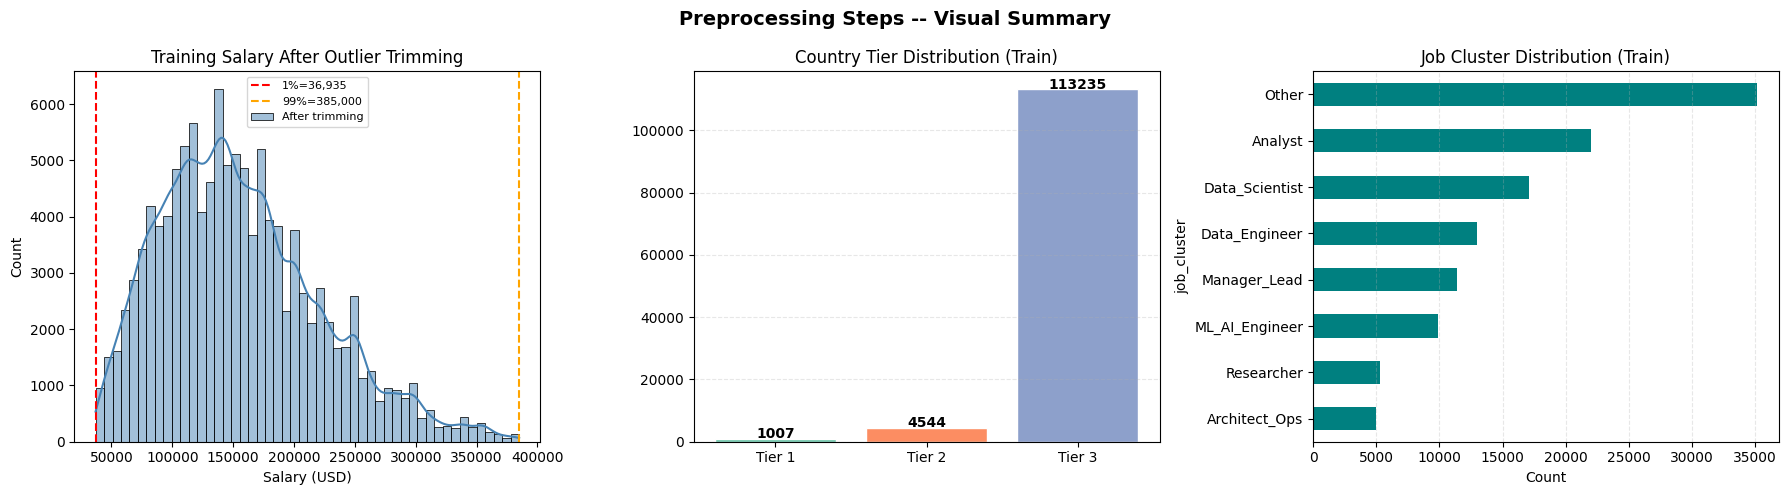

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Preprocessing Steps -- Visual Summary", fontsize=14, fontweight='bold')

sns.histplot(y_train_raw, bins=50, kde=True, color='steelblue', ax=axes[0], label='After trimming')
axes[0].axvline(q_low,  color='red',    linestyle='--', lw=1.5, label=f'1%={q_low:,.0f}')
axes[0].axvline(q_high, color='orange', linestyle='--', lw=1.5, label=f'99%={q_high:,.0f}')
axes[0].set_title('Training Salary After Outlier Trimming')
axes[0].set_xlabel('Salary (USD)'); axes[0].legend(fontsize=8)

tc = X_train['country_tier'].value_counts().sort_index()
axes[1].bar([f'Tier {t}' for t in tc.index], tc.values, color=sns.color_palette('Set2',3), edgecolor='white')
for i,v in enumerate(tc.values): axes[1].text(i,v+30,str(v),ha='center',fontsize=10,fontweight='bold')
axes[1].set_title('Country Tier Distribution (Train)'); axes[1].grid(axis='y',linestyle='--',alpha=0.3)

if 'job_cluster' in df_fe.columns:
    df_fe.loc[X_train.index,'job_cluster'].value_counts().sort_values().plot(
        kind='barh',color='teal',ax=axes[2])
    axes[2].set_title('Job Cluster Distribution (Train)')
    axes[2].set_xlabel('Count'); axes[2].grid(axis='x',linestyle='--',alpha=0.3)

plt.tight_layout(); plt.show()

Exploratory Data Analysis

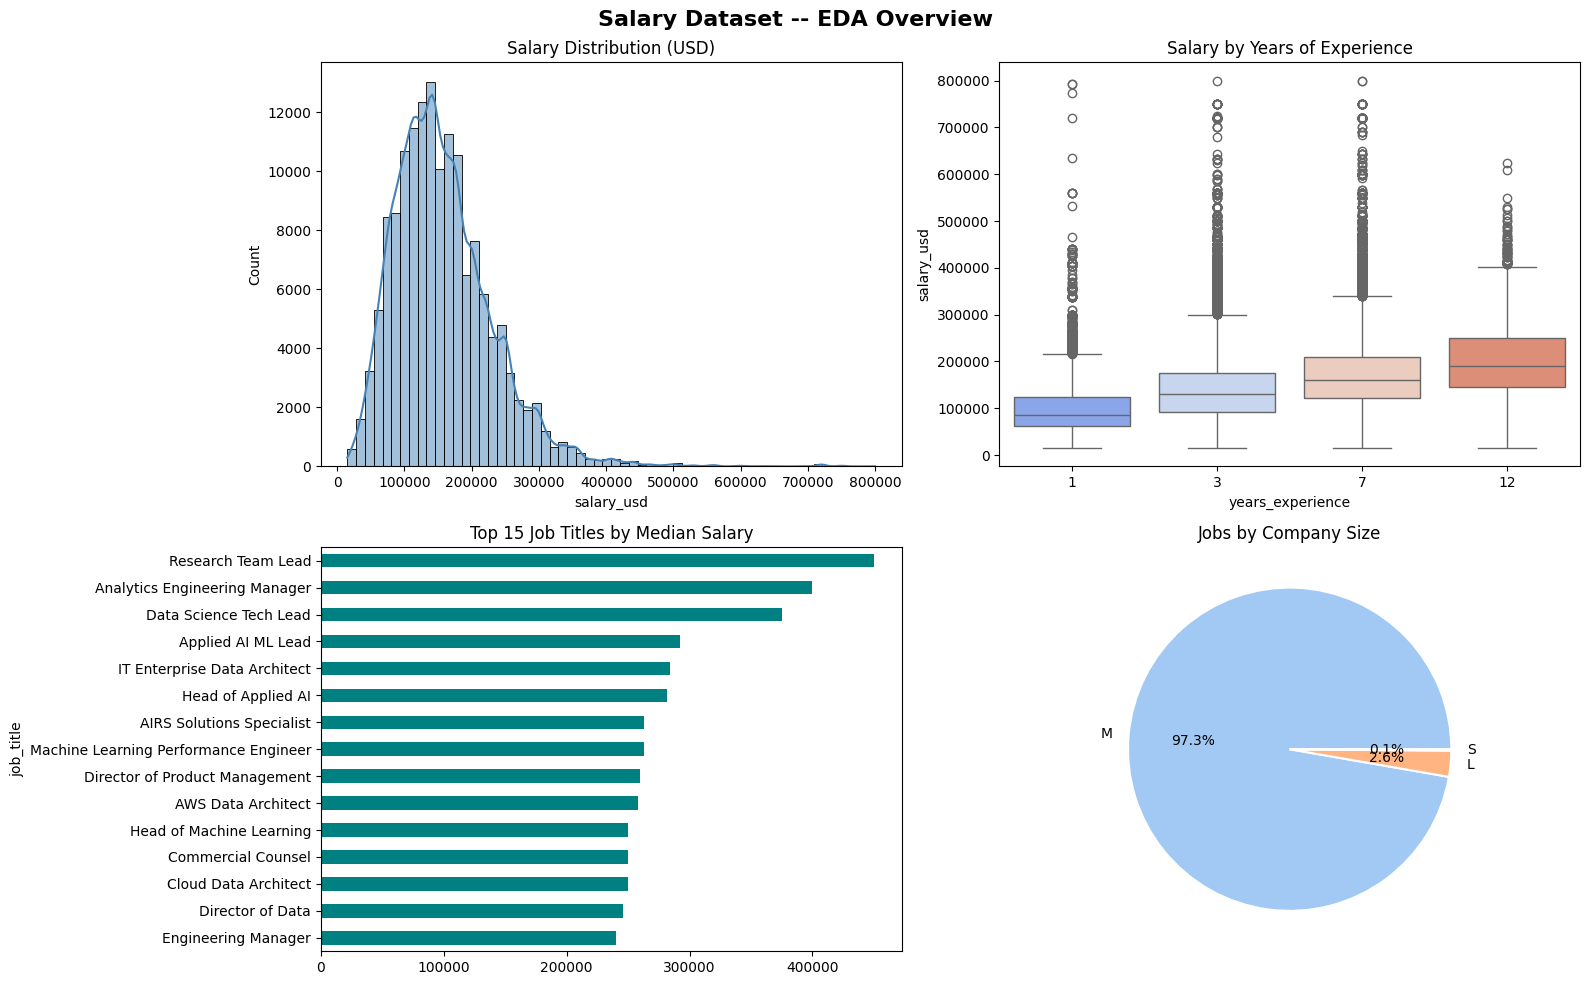

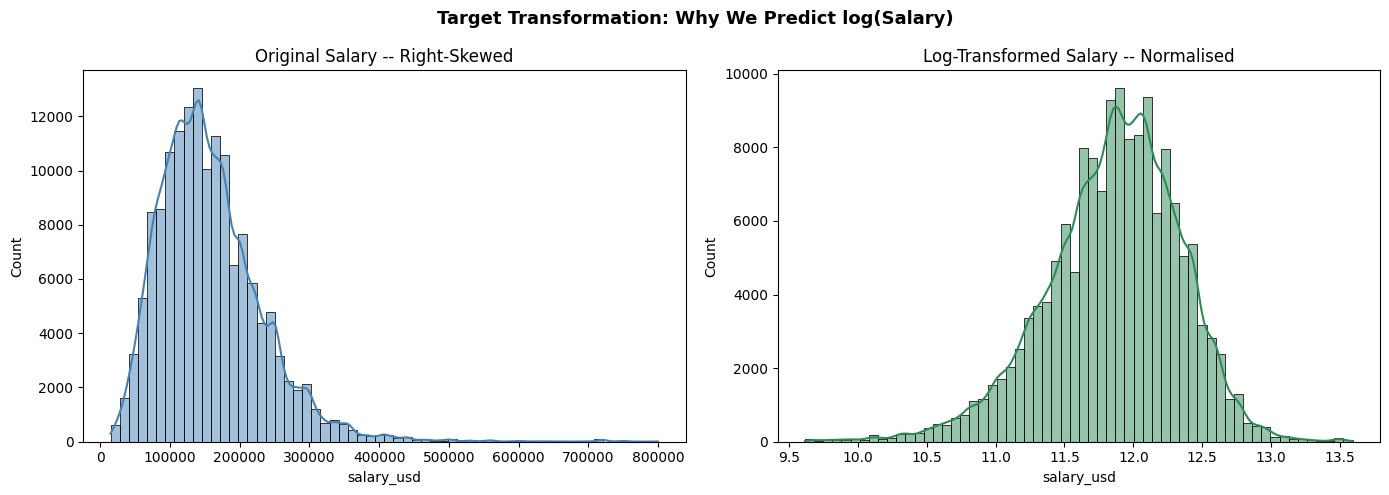

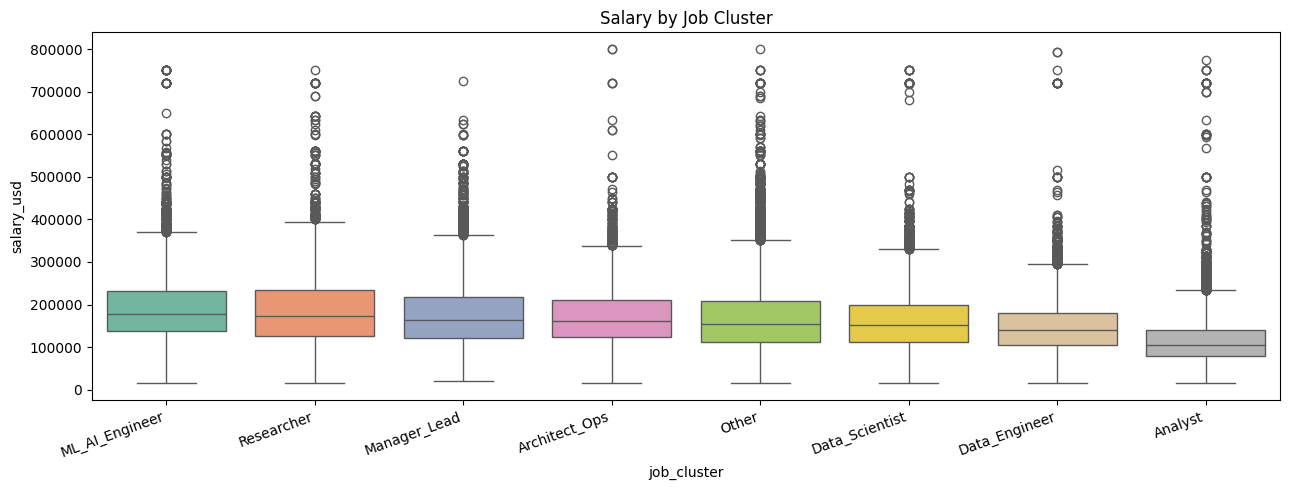

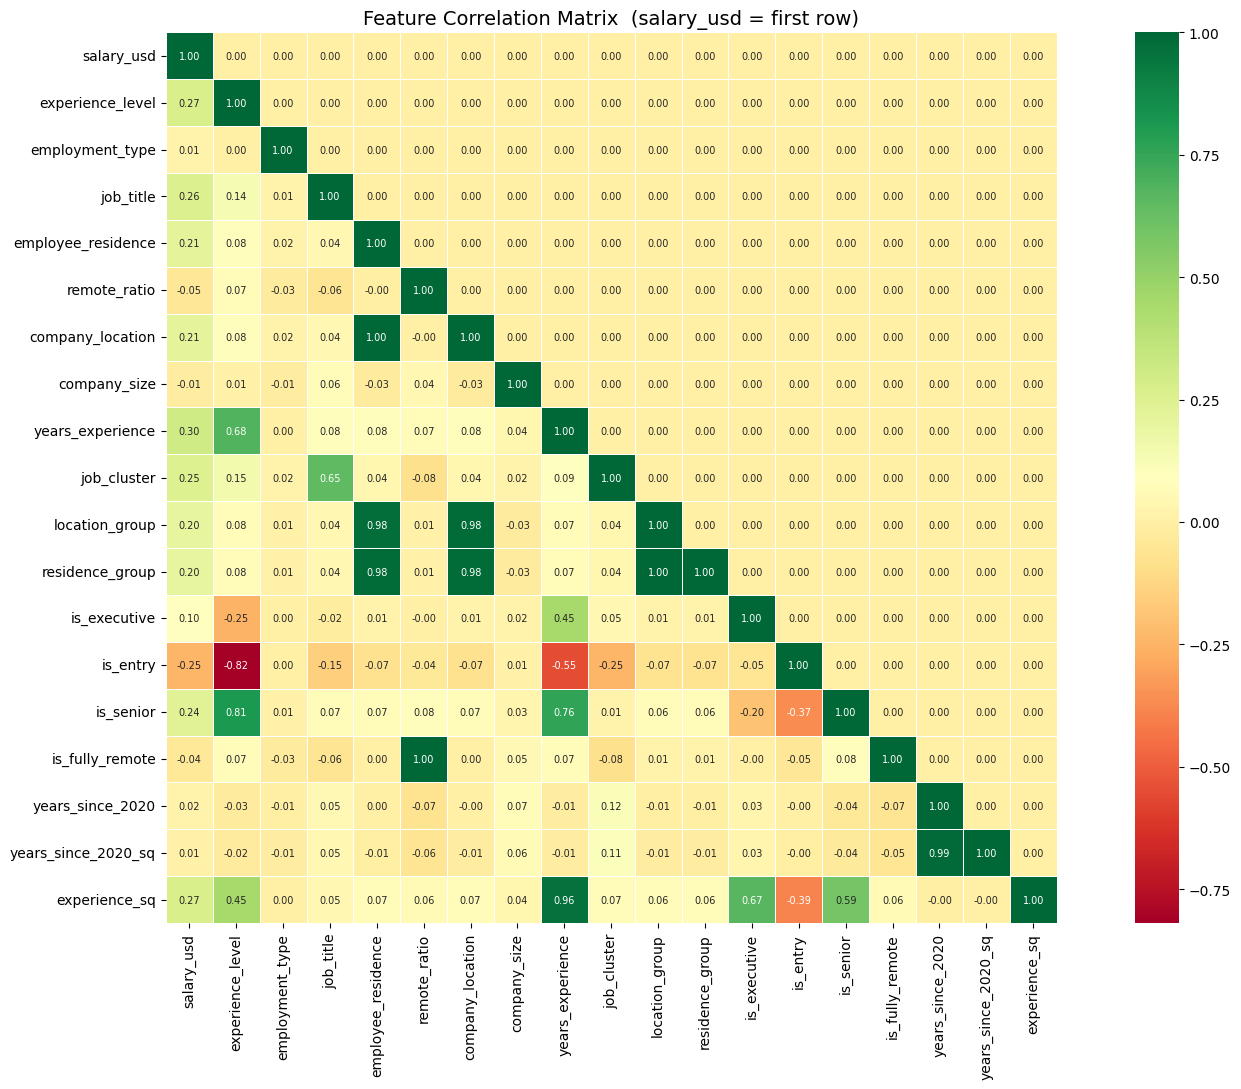

In [11]:
exp_col = 'years_experience'
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Salary Dataset -- EDA Overview', fontsize=16, fontweight='bold')

sns.histplot(df['salary_usd'], bins=60, kde=True, color='steelblue', ax=axes[0,0])
axes[0,0].set_title('Salary Distribution (USD)')

sns.boxplot(data=df, x=exp_col, y='salary_usd', order=sorted(df[exp_col].unique()),
            palette='coolwarm', ax=axes[0,1])
axes[0,1].set_title('Salary by Years of Experience')

df.groupby('job_title')['salary_usd'].median().nlargest(15).sort_values().plot(
    kind='barh', color='teal', ax=axes[1,0])
axes[1,0].set_title('Top 15 Job Titles by Median Salary')

cs = df['company_size'].value_counts()
axes[1,1].pie(cs, labels=cs.index, autopct='%1.1f%%',
              colors=sns.color_palette('pastel'), wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1,1].set_title('Jobs by Company Size')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y, bins=60, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Original Salary -- Right-Skewed')
sns.histplot(np.log1p(y), bins=60, kde=True, color='seagreen', ax=axes[1])
axes[1].set_title('Log-Transformed Salary -- Normalised')
plt.suptitle('Target Transformation: Why We Predict log(Salary)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

if 'job_cluster' in df_fe.columns:
    plt.figure(figsize=(13,5))
    jc = df_fe.groupby('job_cluster')['salary_usd'].median().sort_values(ascending=False).index
    sns.boxplot(data=df_fe, x='job_cluster', y='salary_usd', order=jc, palette='Set2')
    plt.title('Salary by Job Cluster'); plt.xticks(rotation=20, ha='right')
    plt.tight_layout(); plt.show()

numeric_cols = X_full.select_dtypes(include=[np.number]).columns.tolist()
corr = pd.concat([y, X_full[numeric_cols]], axis=1).corr()
plt.figure(figsize=(16, 11))
sns.heatmap(np.tril(corr), annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True, annot_kws={'size': 7},
            xticklabels=corr.columns, yticklabels=corr.columns)
plt.title('Feature Correlation Matrix  (salary_usd = first row)', fontsize=14)
plt.tight_layout(); plt.show()

Adversarial Validation

Adversarial Validation  (LightGBM classifier, 5-fold AUC)
  Group-stat features re-mapped with full-training means for both
  sets so AV measures genuine distribution shift, not OOF artifacts.
  Adversarial AUC (5-fold): 0.5010  (std: 0.0052)
  GOOD: AUC < 0.65 -- distributions are largely indistinguishable.

Top 10 leakage-driving features:
job_title                  1276
job_title_freq              993
years_since_2020            563
employee_residence          350
company_location_freq       299
employee_residence_freq     248
remote_ratio                242
tier_x_exp                  206
grp_job_x_tier              205
experience_level            199
dtype: int32


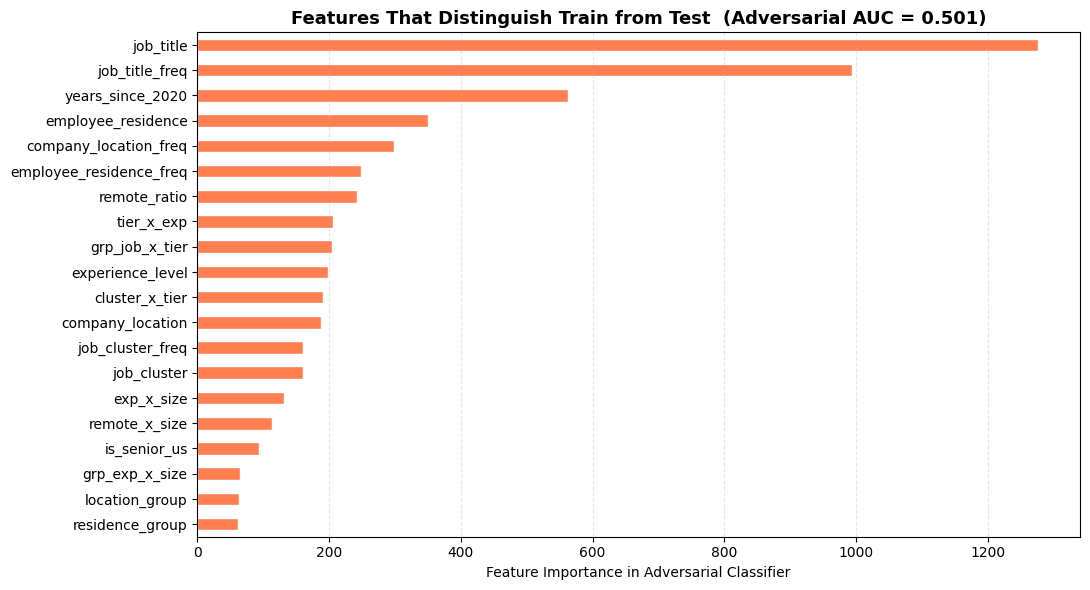

In [12]:
print("Adversarial Validation  (LightGBM classifier, 5-fold AUC)")
print("  Group-stat features re-mapped with full-training means for both")
print("  sets so AV measures genuine distribution shift, not OOF artifacts.")

# ---------------------------------------------------------------------------
# Build adversarial dataset with consistent group-stat encoding.
# Problem: X_train's grp_* features are OOF (noisy), X_test's are from full
# training stats (smooth). A classifier trivially learns this noise pattern
# -> AUC=1.0. Fix: re-apply full-training maps to train copy using the
# pre-snapshotted group keys (safe even after SHAP drops source columns).
# ---------------------------------------------------------------------------
X_train_av = X_train.copy()
X_test_av  = X_test.copy()

for fname, (gcols, full_gm, global_mean, train_key, test_key) in _grp_full_maps.items():
    if fname in X_train_av.columns:
        X_train_av[fname] = train_key.map(full_gm).fillna(global_mean).values
    if fname in X_test_av.columns:
        X_test_av[fname]  = test_key.map(full_gm).fillna(global_mean).values

X_adv = pd.concat([X_train_av.reset_index(drop=True),
                   X_test_av.reset_index(drop=True)])
y_adv = np.array([0]*len(X_train_av) + [1]*len(X_test_av))
rng_adv = np.random.RandomState(42)
perm    = rng_adv.permutation(len(X_adv))
X_adv, y_adv = X_adv.iloc[perm], y_adv[perm]

adv_clf    = LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                             random_state=42, verbose=-1)
adv_scores = cross_val_score(adv_clf, X_adv, y_adv, cv=5, scoring='roc_auc', n_jobs=-1)
adv_auc    = adv_scores.mean()

print(f"  Adversarial AUC (5-fold): {adv_auc:.4f}  (std: {adv_scores.std():.4f})")
if adv_auc > 0.80:
    print("  WARNING: AUC > 0.80 -- significant train/test distribution shift.")
    print("  Inspect top features below and consider dropping year-specific ones.")
elif adv_auc > 0.65:
    print("  MODERATE: mild distribution shift. Monitor feature importances.")
else:
    print("  GOOD: AUC < 0.65 -- distributions are largely indistinguishable.")

# Feature importances: which features best separate train from test?
adv_clf.fit(X_adv, y_adv)
adv_imp = pd.Series(adv_clf.feature_importances_, index=X_adv.columns).sort_values(ascending=False)
print("\nTop 10 leakage-driving features:")
print(adv_imp.head(10))

plt.figure(figsize=(11, 6))
adv_imp.head(20).sort_values().plot(kind='barh', color='coral', edgecolor='white')
plt.title(f'Features That Distinguish Train from Test  (Adversarial AUC = {adv_auc:.3f})',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance in Adversarial Classifier')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


### Adversarial Feature Importances

In [13]:
display(adv_imp.head(10))

,0
job_title,1276
job_title_freq,993
years_since_2020,563
employee_residence,350
company_location_freq,299
employee_residence_freq,248
remote_ratio,242
tier_x_exp,206
grp_job_x_tier,205
experience_level,199


### Investigating Adversarial Validation Features

Let's visualize the distributions of the features identified by adversarial validation as most distinguishing between the training and test sets. This will help us understand the nature of the distribution shift.


--- Top Adversarial Features Present in Current Data ---


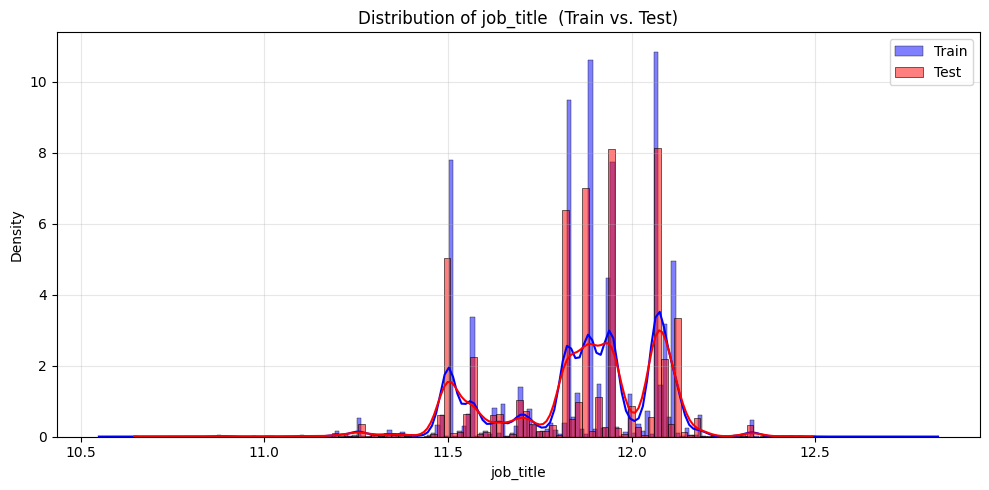

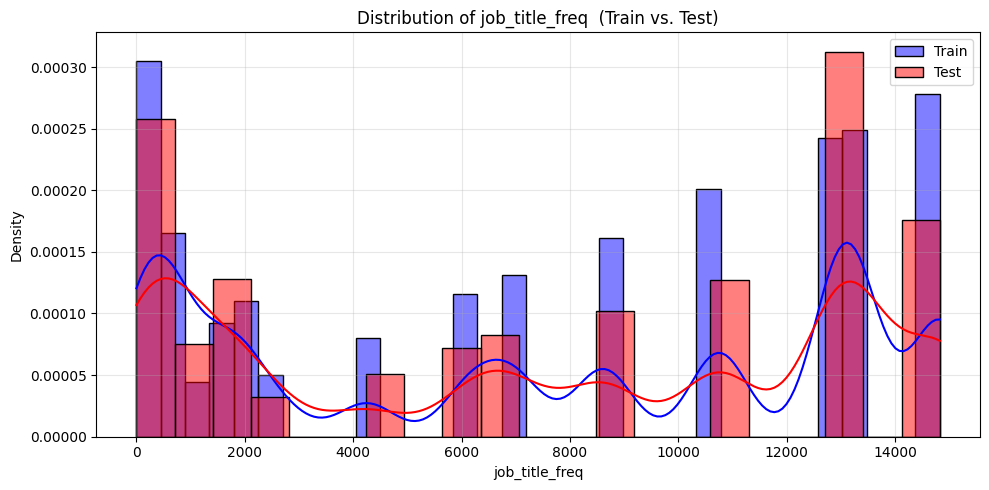

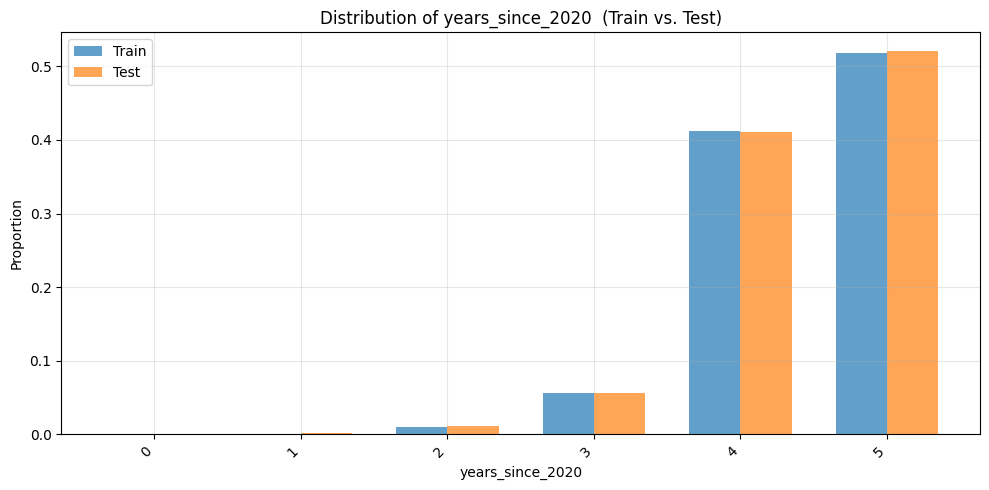

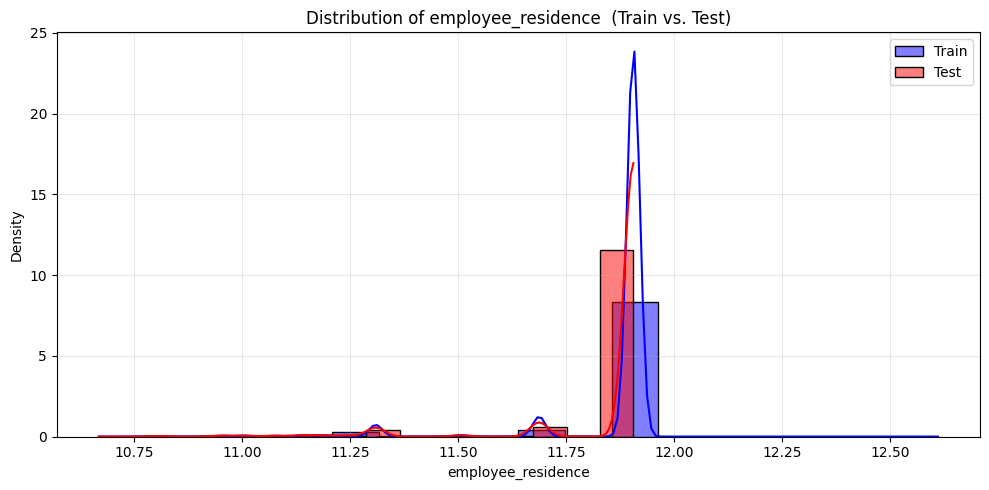

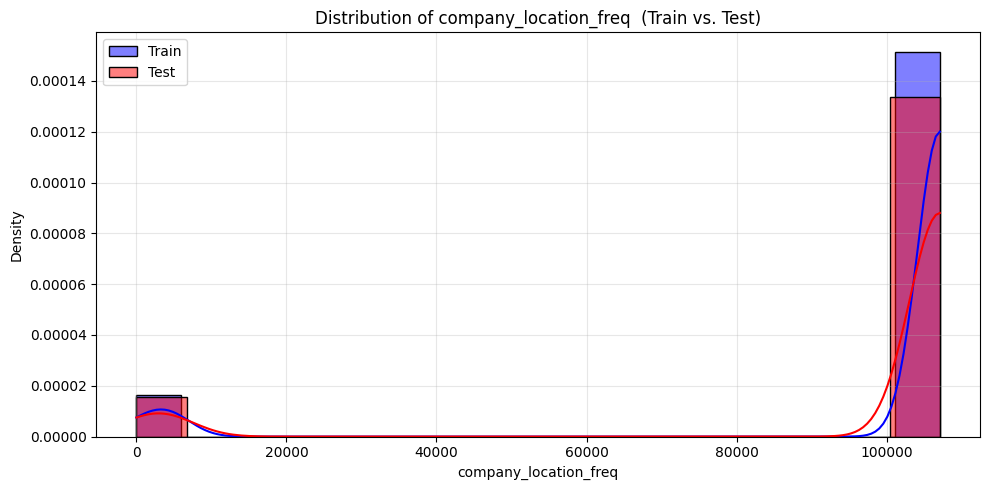


--- grp_tier Distribution ---


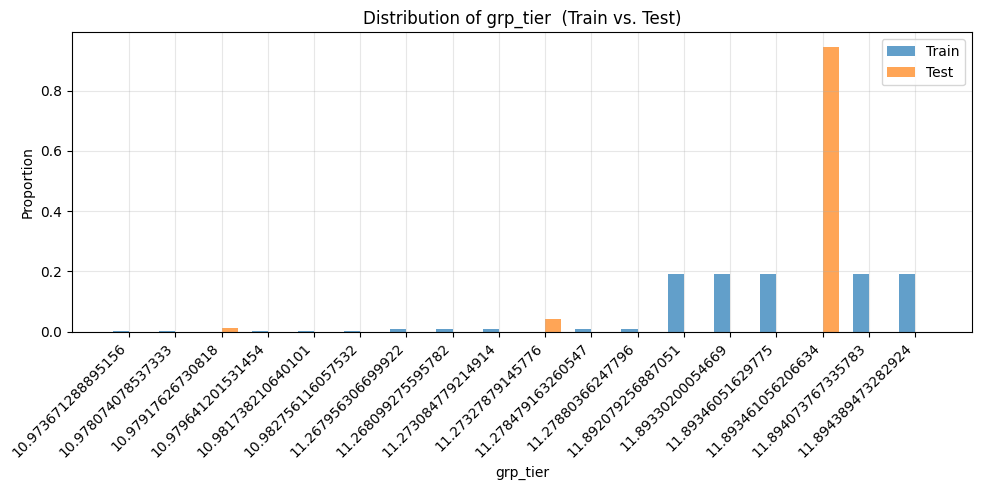


--- job_title Distribution ---


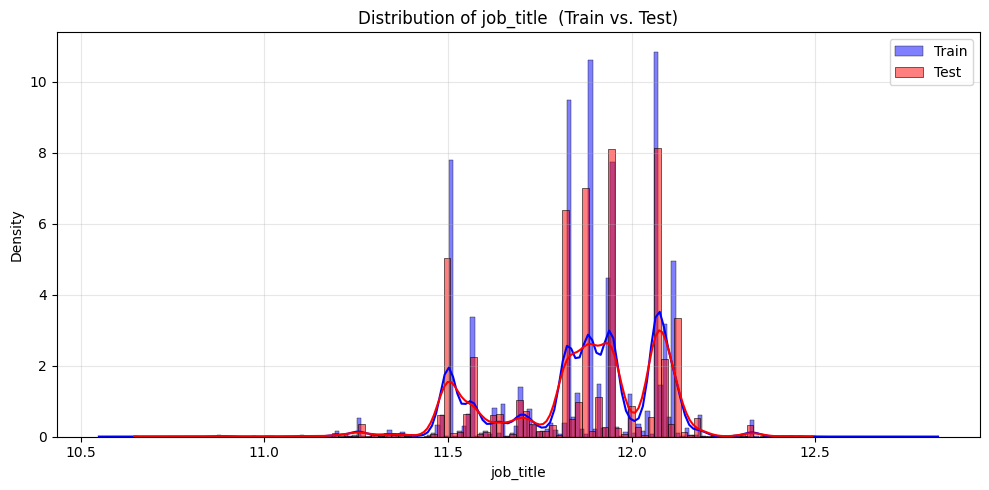

In [14]:
def plot_feature_distribution_comparison(feature_name, X_train_df, X_test_df, title_suffix=''):
    """
    Plots the distribution of a given feature for both training and test sets.
    Handles both numerical and categorical features.
    """
    plt.figure(figsize=(10, 5))
    if X_train_df[feature_name].dtype == 'object' or X_train_df[feature_name].nunique() < 20:
        # Categorical or low-cardinality numerical
        train_counts = X_train_df[feature_name].value_counts(normalize=True).sort_index()
        test_counts = X_test_df[feature_name].value_counts(normalize=True).sort_index()
        combined_index = sorted(list(set(train_counts.index).union(set(test_counts.index))))

        width = 0.35
        x = np.arange(len(combined_index))

        plt.bar(x - width/2, train_counts.reindex(combined_index, fill_value=0), width, label='Train', alpha=0.7)
        plt.bar(x + width/2, test_counts.reindex(combined_index, fill_value=0), width, label='Test', alpha=0.7)

        plt.xticks(x, combined_index, rotation=45, ha='right')
        plt.ylabel('Proportion')
    else:
        # Numerical
        sns.histplot(X_train_df[feature_name], color='blue', label='Train', kde=True, stat='density', alpha=0.5)
        sns.histplot(X_test_df[feature_name], color='red', label='Test', kde=True, stat='density', alpha=0.5)
        plt.ylabel('Density')

    plt.title(f'Distribution of {feature_name} {title_suffix} (Train vs. Test)')
    plt.xlabel(feature_name)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Get top adversarial features (assuming adv_imp is still available from previous execution)
# Note: adv_imp.index contains feature names, and X_train/X_test are the dataframes.
# We need the raw dataframes (or the versions before SHAP feature selection) to show the original distributions.
# However, given the current notebook state, X_train and X_test have already been reduced by SHAP.
# For a true comparison of the *original* features causing shift, we would ideally use X_train_raw and X_test_raw.
# For now, let's use the current X_train and X_test and see the distributions of the features that are still present.

# Let's check the top few features that are still in X_train and X_test after SHAP selection
top_adv_feats_present = [f for f in adv_imp.index if f in X_train.columns][:5]

if 'work_year' in adv_imp.index:
    # We need to reconstruct 'work_year' if it was dropped by SHAP to inspect its original distribution shift.
    # However, the current X_train and X_test variables are already feature-selected.
    # To accurately visualize 'work_year' distribution, we should use X_train_raw and X_test_raw.
    # Since X_train_raw and X_test_raw were used for `adv_imp`, we will use them here.
    print("\n--- Work Year Distribution ---")
    plot_feature_distribution_comparison('work_year', X_train_raw, X_test_raw)

print("\n--- Top Adversarial Features Present in Current Data ---")
for feature in top_adv_feats_present:
    plot_feature_distribution_comparison(feature, X_train, X_test)

# Specific features from the top 10 list that might be interesting (if they were not dropped by SHAP)
if 'grp_tier' in X_train.columns:
    print("\n--- grp_tier Distribution ---")
    plot_feature_distribution_comparison('grp_tier', X_train, X_test)

if 'job_title' in X_train.columns:
    print("\n--- job_title Distribution ---")
    plot_feature_distribution_comparison('job_title', X_train, X_test)


After inspecting the feature distributions, here are some potential follow-up actions:

1.  **If `work_year` is the primary driver (as suggested by the previous warning):**
    *   **Reason:** The dataset likely contains data from different years where the underlying salary trends, job roles, or economic conditions have shifted. An AUC of 1.0000 for `work_year` indicates that the test set contains years not present in the training set (or vice-versa), or that the proportion of years is drastically different.
    *   **Action:** Consider explicitly handling `work_year` as a temporal feature. This might involve:
        *   **Time-series split:** If applicable, split your data based on `work_year` to ensure your model is tested on future data it hasn't seen.
        *   **Feature transformation:** Create features like 'years_since_first_data_year' or use `work_year` as a categorical feature if there are distinct shifts.
        *   **Remove entirely (with caution):** If `work_year` is leaking information about the split and not genuinely predictive of salary in a generalizable way across time, you might consider removing it, but this should be a last resort.

2.  **If other categorical features (`job_title`, `employee_residence`, `company_location`, `grp_tier`, `job_cluster`) show strong shifts:**
    *   **Reason:** This could indicate new job titles, new company locations, or changes in the distribution of company tiers or job clusters appearing in the test set that were rare or absent in the training set.
    *   **Action:** Review your target encoding and frequency encoding strategies. Ensure they are robust to unseen categories (e.g., using smoothing, fallback values). You might need to re-evaluate how these features are engineered or grouped.

3.  **If numerical features (`grp_exp_x_size`, `exp_x_size`, `remote_ratio`) show shifts:**
    *   **Reason:** The range or distribution of these combined or raw features might differ. For example, a new `exp_x_size` combination could appear.
    *   **Action:** Consider robust scaling techniques (e.g., `StandardScaler`, `MinMaxScaler`) if not already applied, especially if models are sensitive to feature scales (e.g., SVR, KNN). Re-evaluate the interaction terms if they are creating unstable values.

By carefully examining these distributions, you can pinpoint the specific reasons for the adversarial shift and formulate targeted solutions, rather than making blind changes.

### Inspecting Value Differences for Top Adversarial Features

Let's manually inspect the value counts and proportions of the categorical adversarial features to understand the nature of the distribution shift.

In [15]:
print("\n--- Value Counts Comparison (Train vs. Test) ---")

categorical_adversarial_features = [
    'job_cluster', 'employee_residence', 'residence_group', 'location_group',
    'job_title' # Including job_title as it's often a key driver
]

# Ensure these features are in the current X_train and X_test
# We'll use the original (pre-SHAP) data for a clearer picture of the initial split issues if possible,
# but using the current X_train/X_test will show the shift in the *currently used* features.
# For a true original comparison, X_train_raw and X_test_raw would be ideal if available and not modified.

for feature in categorical_adversarial_features:
    if feature in X_train.columns and feature in X_test.columns:
        print(f"\nFeature: {feature}")
        train_counts = X_train[feature].value_counts(normalize=True).sort_index()
        test_counts = X_test[feature].value_counts(normalize=True).sort_index()

        combined_df = pd.DataFrame({'Train Proportion': train_counts, 'Test Proportion': test_counts}).fillna(0)
        combined_df['Difference'] = combined_df['Test Proportion'] - combined_df['Train Proportion']
        display(combined_df)
    else:
        print(f"Feature '{feature}' not found in current X_train/X_test. Skipping comparison.")



--- Value Counts Comparison (Train vs. Test) ---

Feature: job_cluster


,Train Proportion,Test Proportion,Difference
job_cluster,,,
11.566561,0.184980,0.184952,-0.000028
11.822748,0.109550,0.109248,-0.000302
11.903253,0.143796,0.142362,-0.001434
11.914438,0.295649,0.296378,0.000729
11.971962,0.096114,0.095645,-0.000469
11.973137,0.042143,0.041962,-0.000181
11.984720,0.044298,0.045660,0.001362
12.063390,0.083469,0.083793,0.000323



Feature: employee_residence


,Train Proportion,Test Proportion,Difference
employee_residence,,,
10.668979,0.000008,0.000099,0.000091
10.726698,0.000008,0.000000,-0.000008
10.754685,0.000008,0.000000,-0.000008
10.766496,0.000143,0.000099,-0.000044
10.778977,0.000017,0.000033,0.000016
...,...,...,...
11.861986,0.000000,0.000066,0.000066
11.906352,0.901276,0.894615,-0.006661
12.141247,0.000017,0.000000,-0.000017



Feature: residence_group


,Train Proportion,Test Proportion,Difference
residence_group,,,
10.807358,0.000673,0.001453,0.000779
10.931109,0.000480,0.000825,0.000346
10.957176,0.001936,0.002476,0.000540
11.004801,0.002273,0.002377,0.000104
11.078789,0.001642,0.002146,0.000504
11.148667,0.002568,0.002872,0.000305
11.187439,0.003174,0.003169,-0.000004
11.236407,0.000951,0.002014,0.001063
11.241035,0.001069,0.000990,-0.000079



Feature: location_group


,Train Proportion,Test Proportion,Difference
location_group,,,
10.807358,0.000673,0.001453,0.000779
10.931109,0.000480,0.000825,0.000346
10.957176,0.001936,0.002476,0.000540
11.004801,0.002273,0.002377,0.000104
11.068886,0.001625,0.002047,0.000422
11.148890,0.002526,0.002905,0.000380
11.188584,0.003165,0.003169,0.000004
11.236300,0.000859,0.001750,0.000891
11.237855,0.001044,0.001023,-0.000020



Feature: job_title


,Train Proportion,Test Proportion,Difference
job_title,,,
10.549412,0.000008,0.000000,-0.000008
10.645449,0.000059,0.000066,0.000007
10.647946,0.000008,0.000033,0.000025
10.708936,0.000008,0.000066,0.000058
10.714440,0.000008,0.000000,-0.000008
...,...,...,...
12.492618,0.000034,0.000066,0.000032
12.557050,0.000008,0.000000,-0.000008
12.558345,0.000017,0.000000,-0.000017


### Modifying `train_test_split` for Stratification

The inspection above helps confirm the categories causing the biggest shifts. To address this, we need to go back to the `Preprocessing` section and modify the `train_test_split` to use stratification. We will create a combined stratification column from `job_cluster` and `employee_residence` (or `location_group` and `residence_group` if they are more distinct after the data loading process) to ensure a more even distribution of these problematic categories across training and test sets.

**Note: After the following modification, you will need to re-run all cells from the `Preprocessing` section (cell `dee2edab`) onwards to reflect the new split and feature engineering.**

In [16]:
# Helper function to get stratification bins for multiple columns
def get_stratify_bins(df, columns):
    combined_bins = df[columns].astype(str).agg('_'.join, axis=1)
    return combined_bins

Metric Helpers

In [17]:
def within_tolerance(y_true, y_pred, pct=0.10):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred) / y_true < pct) * 100

def concordance_cc(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    cov = np.mean((y_true-y_true.mean())*(y_pred-y_pred.mean()))
    return (2*cov)/(y_true.var()+y_pred.var()+(y_true.mean()-y_pred.mean())**2)

def mean_bias_error(y_true, y_pred):
    return float(np.mean(np.array(y_pred) - np.array(y_true)))

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(y_true, np.clip(y_pred, 0, None)))

def adjusted_r2(y_true, y_pred, n_feat):
    r2 = r2_score(y_true, y_pred); n = len(y_true)
    return 1 - (1-r2)*(n-1)/(n-n_feat-1)

def geometric_mean_ratio(y_true, y_pred):
    return np.exp(np.mean(np.log(np.clip(y_pred, 1, None) / np.array(y_true))))

def stratified_cv_r2(model, X, y_log, n_folds=5):
    bins = pd.qcut(y_log, q=n_folds, labels=False, duplicates='drop')
    skf  = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y_log, cv=skf, scoring='r2', n_jobs=-1)
    return scores.mean(), scores.std()

def score(y_true, y_pred, timing=None, n_feat=None):
    mape = (np.abs(y_true.values-y_pred)/y_true.values*100).mean()
    n = n_feat if n_feat is not None else X_train.shape[1]  # use actual model feature count
    t_str = f"  Training time    : {timing:.1f}s\n" if timing else ""
    print(
        f"{t_str}"
        f"  R2               : {r2_score(y_true, y_pred):.4f}\n"
        f"  Adjusted R2      : {adjusted_r2(y_true, y_pred, n):.4f}\n"
        f"  MAE              : ${mean_absolute_error(y_true, y_pred):,.0f}\n"
        f"  RMSE             : ${np.sqrt(mean_squared_error(y_true, y_pred)):,.0f}\n"
        f"  RMSLE            : {rmsle(y_true, y_pred):.4f}\n"
        f"  Median AE        : ${median_absolute_error(y_true, y_pred):,.0f}\n"
        f"  MAPE             : {mape:.2f}%\n"
        f"  Accuracy (5%)    : {within_tolerance(y_true, y_pred, 0.05):.1f}%\n"
        f"  Accuracy (10%)   : {within_tolerance(y_true, y_pred, 0.10):.1f}%\n"
        f"  Accuracy (20%)   : {within_tolerance(y_true, y_pred, 0.20):.1f}%\n"
        f"  CCC              : {concordance_cc(y_true, y_pred):.4f}\n"
        f"  GMR              : {geometric_mean_ratio(y_true, y_pred):.4f}\n"
        f"  MBE              : ${mean_bias_error(y_true, y_pred):+,.0f}"
    )

def metrics_dict(y_true, y_pred, name, n_feat=None):
    mape = (np.abs(y_true.values-y_pred)/y_true.values*100).mean()
    n = n_feat if n_feat is not None else X_train.shape[1]  # use actual model feature count
    return {
        'Model':  name,
        'R2':     r2_score(y_true, y_pred),
        'Adj_R2': adjusted_r2(y_true, y_pred, n),
        'MAE':    mean_absolute_error(y_true, y_pred),
        'RMSE':   np.sqrt(mean_squared_error(y_true, y_pred)),
        'RMSLE':  rmsle(y_true, y_pred),
        'MedAE':  median_absolute_error(y_true, y_pred),
        'MaxErr': max_error(y_true, y_pred),
        'EVS':    explained_variance_score(y_true, y_pred),
        'CCC':    concordance_cc(y_true, y_pred),
        'GMR':    geometric_mean_ratio(y_true, y_pred),
        'MBE':    mean_bias_error(y_true, y_pred),
        'MAPE':   mape,
        'Acc_5':  within_tolerance(y_true, y_pred, 0.05),
        'Acc_10': within_tolerance(y_true, y_pred, 0.10),
        'Acc_20': within_tolerance(y_true, y_pred, 0.20),
    }

print("Metric helpers ready.")

Metric helpers ready.


Baseline Models

In [18]:
print("Linear Regression (Baseline)")
t0=time.perf_counter(); baseline=LinearRegression(); baseline.fit(X_train,y_train_log)
y_pred_baseline=np.expm1(baseline.predict(X_test)); score(y_test,y_pred_baseline,time.perf_counter()-t0)

Linear Regression (Baseline)
  Training time    : 0.3s
  R2               : 0.2591
  Adjusted R2      : 0.2583
  MAE              : $45,049
  RMSE             : $63,946
  RMSLE            : 0.3788
  Median AE        : $34,266
  MAPE             : 31.54%
  Accuracy (5%)    : 10.9%
  Accuracy (10%)   : 21.4%
  Accuracy (20%)   : 41.0%
  CCC              : 0.4091
  GMR              : 1.0012
  MBE              : $-11,119


In [19]:
print("Ridge Regression")
t0=time.perf_counter(); ridge=Ridge(alpha=1.0); ridge.fit(X_train,y_train_log)
y_pred_ridge=np.expm1(ridge.predict(X_test)); score(y_test,y_pred_ridge,time.perf_counter()-t0)

Ridge Regression
  Training time    : 0.1s
  R2               : 0.2592
  Adjusted R2      : 0.2583
  MAE              : $45,049
  RMSE             : $63,945
  RMSLE            : 0.3788
  Median AE        : $34,253
  MAPE             : 31.54%
  Accuracy (5%)    : 10.9%
  Accuracy (10%)   : 21.4%
  Accuracy (20%)   : 41.0%
  CCC              : 0.4091
  GMR              : 1.0012
  MBE              : $-11,120


In [20]:
print("ElasticNet")
t0=time.perf_counter(); enet=ElasticNet(alpha=0.1,l1_ratio=0.5,max_iter=5000,random_state=42)
enet.fit(X_train,y_train_log); y_pred_enet=np.expm1(enet.predict(X_test)); score(y_test,y_pred_enet,time.perf_counter()-t0)

ElasticNet
  Training time    : 33.0s
  R2               : 0.1261
  Adjusted R2      : 0.1251
  MAE              : $49,523
  RMSE             : $69,451
  RMSLE            : 0.4199
  Median AE        : $38,251
  MAPE             : 35.51%
  Accuracy (5%)    : 9.8%
  Accuracy (10%)   : 19.4%
  Accuracy (20%)   : 37.8%
  CCC              : 0.2537
  GMR              : 1.0011
  MBE              : $-13,314


In [21]:
print("Bayesian Ridge")
t0=time.perf_counter(); bayes=BayesianRidge(max_iter=500); bayes.fit(X_train,y_train_log)
y_pred_bayes=np.expm1(bayes.predict(X_test)); score(y_test,y_pred_bayes,time.perf_counter()-t0)

Bayesian Ridge
  Training time    : 1.0s
  R2               : 0.2592
  Adjusted R2      : 0.2583
  MAE              : $45,049
  RMSE             : $63,946
  RMSLE            : 0.3788
  Median AE        : $34,254
  MAPE             : 31.54%
  Accuracy (5%)    : 10.9%
  Accuracy (10%)   : 21.4%
  Accuracy (20%)   : 41.0%
  CCC              : 0.4091
  GMR              : 1.0012
  MBE              : $-11,122


In [22]:
print("Huber Regressor")
t0=time.perf_counter(); huber=HuberRegressor(epsilon=1.35,max_iter=500); huber.fit(X_train,y_train_log)
y_pred_huber=np.expm1(huber.predict(X_test)); score(y_test,y_pred_huber,time.perf_counter()-t0)

Huber Regressor
  Training time    : 10.3s
  R2               : 0.0773
  Adjusted R2      : 0.0762
  MAE              : $51,288
  RMSE             : $71,365
  RMSLE            : 0.9010
  Median AE        : $39,973
  MAPE             : 37.14%
  Accuracy (5%)    : 9.5%
  Accuracy (10%)   : 18.8%
  Accuracy (20%)   : 36.8%
  CCC              : 0.2412
  GMR              : 0.9404
  MBE              : $-13,483


Tree-Based Models

In [23]:
print("Random Forest  (tqdm via joblib)")
t0=time.perf_counter()
rf=RandomForestRegressor(n_estimators=CFG['n_rf'],max_depth=15,min_samples_leaf=4,
                          max_features=0.7,max_samples=0.9,random_state=42,n_jobs=-1)
with tqdm_joblib(tqdm(desc="Random Forest",total=CFG['n_rf'],unit="tree",
                      bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]")):
    rf.fit(X_train,y_train_log) # Fit on reduced X_train
y_pred_rf=np.expm1(rf.predict(X_test)); score(y_test,y_pred_rf,time.perf_counter()-t0) # Predict on reduced X_test


Random Forest  (tqdm via joblib)


Random Forest:   0%|          | 0/300 [00:00<?]

  Training time    : 100.8s
  R2               : 0.2830
  Adjusted R2      : 0.2822
  MAE              : $44,324
  RMSE             : $62,907
  RMSLE            : 0.3716
  Median AE        : $33,797
  MAPE             : 30.94%
  Accuracy (5%)    : 11.3%
  Accuracy (10%)   : 21.7%
  Accuracy (20%)   : 42.1%
  CCC              : 0.4367
  GMR              : 1.0028
  MBE              : $-10,509


In [24]:
print("Extra Trees  (tqdm via joblib)")
t0=time.perf_counter()
et=ExtraTreesRegressor(n_estimators=CFG['n_et'],max_depth=15,min_samples_leaf=4,
                        max_features=0.7,random_state=42,n_jobs=-1)
with tqdm_joblib(tqdm(desc="Extra Trees",total=CFG['n_et'],unit="tree",
                      bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]")):
    et.fit(X_train,y_train_log) # Fit on reduced X_train
y_pred_et=np.expm1(et.predict(X_test)); score(y_test,y_pred_et,time.perf_counter()-t0) # Predict on reduced X_test


Extra Trees  (tqdm via joblib)


Extra Trees:   0%|          | 0/300 [00:00<?]

  Training time    : 118.2s
  R2               : 0.2835
  Adjusted R2      : 0.2827
  MAE              : $44,290
  RMSE             : $62,886
  RMSLE            : 0.3708
  Median AE        : $33,803
  MAPE             : 30.86%
  Accuracy (5%)    : 11.3%
  Accuracy (10%)   : 21.8%
  Accuracy (20%)   : 42.2%
  CCC              : 0.4367
  GMR              : 1.0017
  MBE              : $-10,675


In [25]:
print("HistGradientBoosting  (early stopping)")
t0=time.perf_counter()
hgb=HistGradientBoostingRegressor(
    max_iter=CFG['n_hgb_max'],learning_rate=0.04,max_depth=7,min_samples_leaf=20,
    l2_regularization=0.1,early_stopping=True,validation_fraction=0.1,
    n_iter_no_change=30,tol=1e-5,random_state=42,verbose=0)
with tqdm(total=CFG['n_hgb_max'],desc="HistGradBoost",unit="iter",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]") as pbar:
    hgb.fit(X_train,y_train_log); pbar.n=hgb.n_iter_; pbar.set_postfix({"stopped_at":hgb.n_iter_}); pbar.refresh() # Fit on feature-selected X_train
y_pred_hgb=np.expm1(hgb.predict(X_test)) # Predict on reduced X_test
print(f"  Early stopped at iter {hgb.n_iter_}")
score(y_test,y_pred_hgb,time.perf_counter()-t0)


HistGradientBoosting  (early stopping)


HistGradBoost:   0%|          | 0/1000 [00:00<?]

  Early stopped at iter 274
  Training time    : 10.4s
  R2               : 0.2807
  Adjusted R2      : 0.2799
  MAE              : $44,385
  RMSE             : $63,009
  RMSLE            : 0.3717
  Median AE        : $33,736
  MAPE             : 30.95%
  Accuracy (5%)    : 11.0%
  Accuracy (10%)   : 21.5%
  Accuracy (20%)   : 42.0%
  CCC              : 0.4327
  GMR              : 1.0020
  MBE              : $-10,723


Boosting Models

In [26]:
print("XGBoost  (early stopping + feature noise injection)")
t0=time.perf_counter()

# Feature noise injection: add ~0.5% Gaussian noise to training features
# X_tr_noisy must be based on the feature-selected X_tr
X_tr_noisy = X_tr.copy().astype(float) # Use the reduced X_tr
rng = np.random.default_rng(42)
noise_std = X_tr_noisy.std() * 0.005
X_tr_noisy += rng.normal(0, noise_std, X_tr_noisy.shape)

xgb_model=XGBRegressor(
    n_estimators=CFG['n_xgb_max'],learning_rate=0.02,max_depth=5,
    subsample=0.8,colsample_bytree=0.8,colsample_bylevel=0.8,
    min_child_weight=5,reg_alpha=0.1,reg_lambda=1.5,gamma=0.05,
    early_stopping_rounds=CFG['early_stop'],random_state=42,verbosity=0)
# Removed the 'callbacks' argument as it's causing a TypeError in this environment.
# This means the custom tqdm progress bar for XGBoost will not be displayed.
xgb_model.fit(X_tr_noisy,y_tr_log,eval_set=[(X_val,y_val_log)], # Fit on feature-selected X_tr_noisy and X_val
              verbose=False)
y_pred_xgb=np.expm1(xgb_model.predict(X_test)) # Predict on the reduced X_test
print(f"  Best iteration: {xgb_model.best_iteration}")
score(y_test,y_pred_xgb,time.perf_counter()-t0)

XGBoost  (early stopping + feature noise injection)
  Best iteration: 972
  Training time    : 34.0s
  R2               : 0.2777
  Adjusted R2      : 0.2768
  MAE              : $44,548
  RMSE             : $63,141
  RMSLE            : 0.3736
  Median AE        : $33,802
  MAPE             : 31.23%
  Accuracy (5%)    : 11.1%
  Accuracy (10%)   : 21.4%
  Accuracy (20%)   : 41.8%
  CCC              : 0.4267
  GMR              : 1.0050
  MBE              : $-10,495


In [27]:
print("LightGBM  (early stopping)")
t0=time.perf_counter()
lgbm_model=LGBMRegressor(
    n_estimators=CFG['n_lgbm_max'],learning_rate=0.02,num_leaves=63,
    subsample=0.8,colsample_bytree=0.8,feature_fraction_bynode=0.8,
    reg_alpha=0.1,reg_lambda=1.0,min_child_samples=20,min_sum_hessian_in_leaf=10,random_state=42)
lpb=tqdm(total=CFG['n_lgbm_max'],desc="LightGBM",unit="tree",
         bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]")
lgbm_model.fit(X_tr,y_tr_log,eval_set=[(X_val,y_val_log)], # Fit on feature-selected X_tr, X_val
               callbacks=[lightgbm_lib.early_stopping(CFG['early_stop'],verbose=False),
                           lightgbm_lib.log_evaluation(period=-1),lgbm_tqdm_cb(lpb)])
lpb.close()
y_pred_lgbm=np.expm1(lgbm_model.predict(X_test)) # Predict on reduced X_test
print(f"  Best iteration: {lgbm_model.best_iteration_}")
score(y_test,y_pred_lgbm,time.perf_counter()-t0)

LightGBM  (early stopping)


LightGBM:   0%|          | 0/1000 [00:00<?]

  Best iteration: 687
  Training time    : 18.5s
  R2               : 0.2822
  Adjusted R2      : 0.2814
  MAE              : $44,286
  RMSE             : $62,941
  RMSLE            : 0.3709
  Median AE        : $33,666
  MAPE             : 30.84%
  Accuracy (5%)    : 11.4%
  Accuracy (10%)   : 21.7%
  Accuracy (20%)   : 42.2%
  CCC              : 0.4340
  GMR              : 1.0018
  MBE              : $-10,759


In [28]:
# print("LightGBM DART  (dropout regularisation)")
# t0=time.perf_counter()
# lgbm_dart=LGBMRegressor(
#     boosting_type='dart',n_estimators=CFG['n_lgbm_max'],learning_rate=0.05,num_leaves=63,
#     subsample=0.8,colsample_bytree=0.8,drop_rate=0.1,skip_drop=0.5,
#     min_child_samples=20,random_state=42)
# dp=tqdm(total=CFG['n_lgbm_max'],desc="LightGBM DART",unit="tree",
#         bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]")
# lgbm_dart.fit(X_tr,y_tr_log, # Fit on reduced X_tr, X_val
#               eval_set=[(X_val,y_val_log)], # Add validation set for early stopping
#               callbacks=[lightgbm_lib.early_stopping(CFG['early_stop'],verbose=False),
#                            lightgbm_lib.log_evaluation(period=-1),lgbm_tqdm_cb(dp)])
# dp.close()
# y_pred_lgbm_dart=np.expm1(lgbm_dart.predict(X_test)); score(y_test,y_pred_lgbm_dart,time.perf_counter()-t0) # Predict on reduced X_test

# Placeholder for y_pred_lgbm_dart if the model is not trained
y_pred_lgbm_dart = np.full_like(y_test, np.nan) # Define y_pred_lgbm_dart as NaN array to prevent errors if referenced.

In [29]:
print("CatBoost  (early stopping)")
t0=time.perf_counter()
cat_model=CatBoostRegressor(
    iterations=CFG['n_cat_max'],learning_rate=0.02,depth=6,l2_leaf_reg=3,
    subsample=0.8,min_data_in_leaf=20,random_strength=0.5,
    early_stopping_rounds=CFG['early_stop'],random_seed=42,verbose=0)
cp=tqdm(total=CFG['n_cat_max'],desc="CatBoost",unit="iter",
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]")
class _CPB:
    def after_iteration(self,info): cp.n=info.iteration; cp.refresh(); return True
cat_model.fit(X_tr,y_tr_log,eval_set=(X_val,y_val_log),callbacks=[_CPB()]) # Fit on feature-selected X_tr, X_val
cp.close()
y_pred_cat=np.expm1(cat_model.predict(X_test)) # Predict on reduced X_test
print(f"  Best iteration: {cat_model.best_iteration_}")
score(y_test,y_pred_cat,time.perf_counter()-t0)

CatBoost  (early stopping)


CatBoost:   0%|          | 0/1000 [00:00<?]

  Best iteration: 999
  Training time    : 40.5s
  R2               : 0.2776
  Adjusted R2      : 0.2768
  MAE              : $44,467
  RMSE             : $63,144
  RMSLE            : 0.3725
  Median AE        : $33,690
  MAPE             : 30.99%
  Accuracy (5%)    : 11.1%
  Accuracy (10%)   : 21.5%
  Accuracy (20%)   : 41.9%
  CCC              : 0.4288
  GMR              : 1.0011
  MBE              : $-10,966


SHAP Feature Selection

Computing SHAP values on LightGBM baseline (100 trees)...
  SHAP computed in 6.1s
  Features before selection : 35
  Features after  selection : 8  (kept 90% cumulative importance)
  Dropped features          : ['experience_level', 'employment_type', 'company_location', 'company_size', 'years_experience', 'job_cluster', 'location_group', 'residence_group', 'is_executive', 'is_entry', 'is_senior', 'is_fully_remote', 'years_since_2020', 'years_since_2020_sq', 'experience_sq', 'country_tier', 'is_senior_us', 'remote_x_size', 'exec_x_tier', 'cluster_x_tier', 'job_cluster_freq', 'company_location_freq', 'employee_residence_freq', 'employment_type_freq', 'company_size_freq', 'grp_tier', 'grp_cluster']


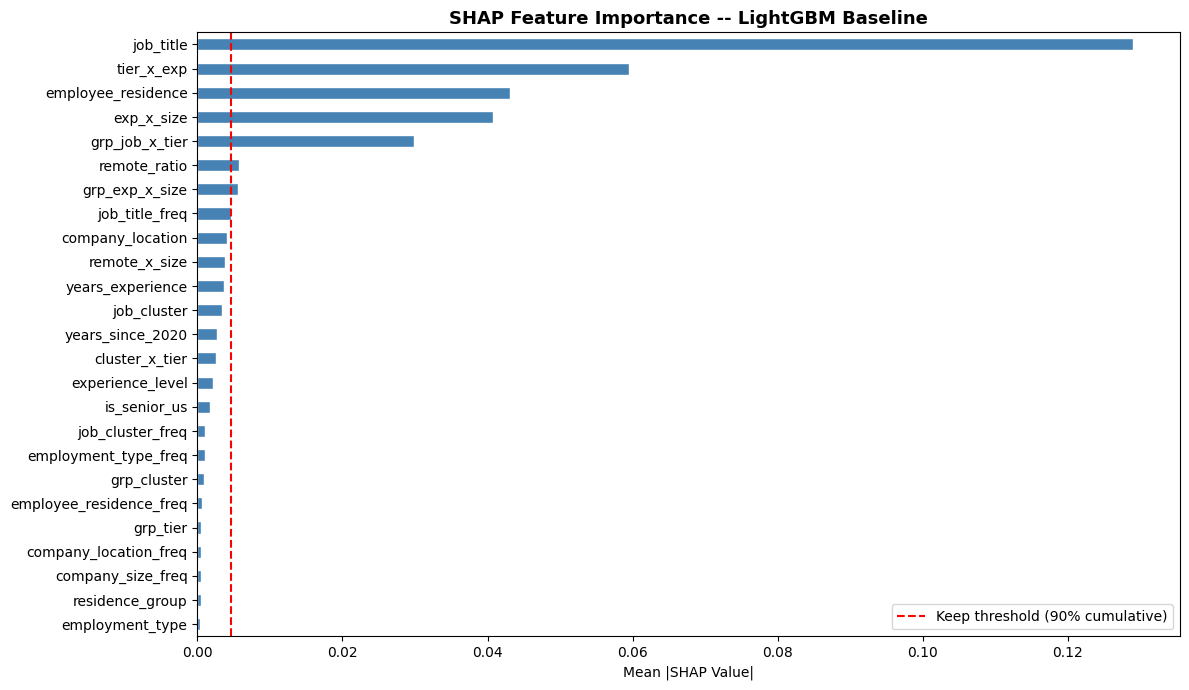

  Final feature set (8): ['job_title', 'employee_residence', 'remote_ratio', 'exp_x_size', 'tier_x_exp', 'job_title_freq', 'grp_job_x_tier', 'grp_exp_x_size']


In [30]:
# ---------------------------------------------------------------------------
# SHAP-Based Feature Selection:
# 1. Train a quick LightGBM to get stable SHAP values fast
# 2. Rank features by mean absolute SHAP
# 3. Keep features covering CFG['shap_keep_pct'] of cumulative importance
# 4. Drop the rest from all data splits
# Paper reference: "SHAP-guided feature selection retaining top-importance features."
# ---------------------------------------------------------------------------
print(f"Computing SHAP values on LightGBM baseline (100 trees)...")
t0 = time.perf_counter()

shap_lgbm = LGBMRegressor(n_estimators=100, learning_rate=0.1, num_leaves=31,
                           random_state=42, verbose=-1)
shap_lgbm.fit(X_train, y_train_log)

explainer  = shap.TreeExplainer(shap_lgbm)
shap_vals  = explainer.shap_values(X_train.sample(min(5000, len(X_train)), random_state=42))
mean_shap  = pd.Series(np.abs(shap_vals).mean(axis=0), index=X_train.columns).sort_values(ascending=False)

# Cumulative importance -- keep features up to shap_keep_pct
cum_imp     = mean_shap.cumsum() / mean_shap.sum()
keep_feats  = cum_imp[cum_imp <= CFG['shap_keep_pct']].index.tolist()
# Always include at least 1 more to cross the threshold
if len(keep_feats) < len(mean_shap):
    keep_feats.append(cum_imp.index[len(keep_feats)])
drop_feats  = [f for f in X_train.columns if f not in keep_feats]

print(f"  SHAP computed in {time.perf_counter()-t0:.1f}s")
print(f"  Features before selection : {len(X_train.columns)}")
print(f"  Features after  selection : {len(keep_feats)}  (kept {CFG['shap_keep_pct']*100:.0f}% cumulative importance)")
print(f"  Dropped features          : {drop_feats}")

# Visualise
plt.figure(figsize=(12, 7))
mean_shap.head(25).sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.axvline(mean_shap[keep_feats[-1]], color='red', linestyle='--', lw=1.5,
            label=f'Keep threshold ({CFG["shap_keep_pct"]*100:.0f}% cumulative)')
plt.title('SHAP Feature Importance -- LightGBM Baseline', fontsize=13, fontweight='bold')
plt.xlabel('Mean |SHAP Value|')
plt.legend()
plt.tight_layout()
plt.show()

# Apply selection to all splits
if drop_feats:
    X_train.drop(columns=drop_feats, inplace=True)
    X_test.drop(columns=drop_feats, inplace=True)
    X_tr.drop(columns=drop_feats, inplace=True)
    X_val.drop(columns=drop_feats, inplace=True)
    print(f"  Final feature set ({X_train.shape[1]}): {list(X_train.columns)}")
else:
    print("  No features dropped -- all meet the importance threshold.")

### Adversarial Validation (Post-SHAP Feature Selection)

Now that we've performed SHAP-based feature selection, let's re-run the adversarial validation to see if the distribution shift between the training and test sets has changed with the reduced feature set. A lower AUC indicates less distinction between the sets.

Adversarial Validation (LightGBM classifier, 5-fold AUC) -- Post-SHAP
  Using snapshotted group keys (captured before SHAP dropped source
  columns) so grp_* re-mapping works regardless of which features
  SHAP removed. This is the fix for the AUC=1.0 bug.
  Adversarial AUC (5-fold) -- Post-SHAP: 0.4945  (std: 0.0055)
  GOOD: AUC < 0.65 -- distributions are largely indistinguishable.

Top 10 leakage-driving features (Post-SHAP):
job_title             1520
job_title_freq        1419
employee_residence    1142
grp_job_x_tier         689
exp_x_size             451
remote_ratio           358
tier_x_exp             256
grp_exp_x_size         165
dtype: int32


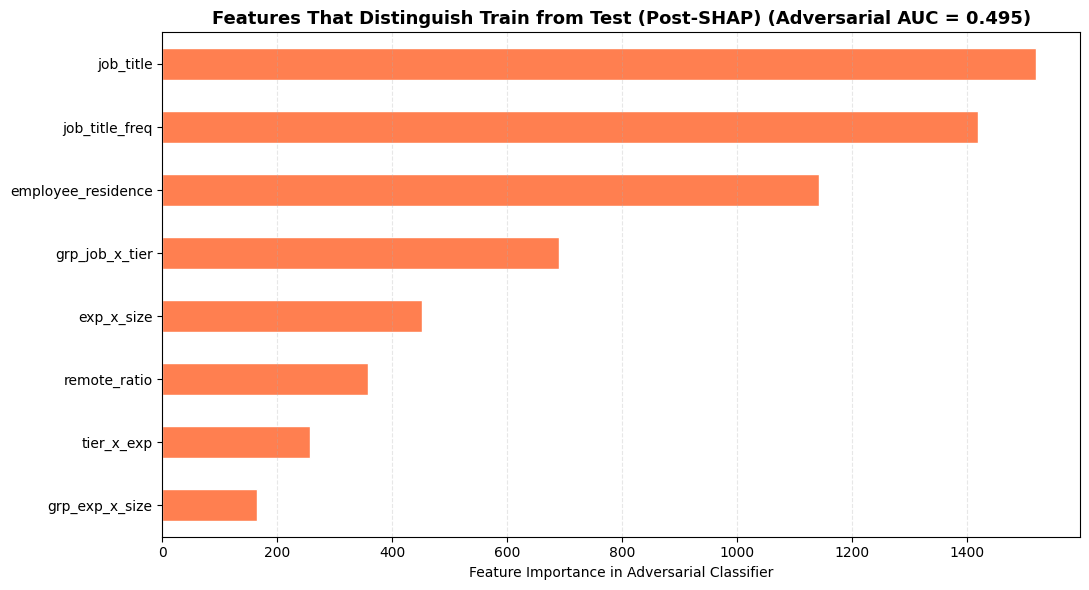

In [31]:
print("Adversarial Validation (LightGBM classifier, 5-fold AUC) -- Post-SHAP")
print("  Using snapshotted group keys (captured before SHAP dropped source")
print("  columns) so grp_* re-mapping works regardless of which features")
print("  SHAP removed. This is the fix for the AUC=1.0 bug.")

# ---------------------------------------------------------------------------
# Root cause of AUC=1.0:
#   After SHAP drops grouping columns (e.g. job_cluster, country_tier),
#   the previous guard `all(col in df.columns for col in gcols)` evaluates
#   False for every grp_* feature, so NO re-mapping happens. X_train_av_ps
#   retains OOF-encoded grp_* values while X_test keeps full-training values
#   -> trivially separable -> AUC=1.0.
#
# Fix: use the pre-snapshotted train_key / test_key Series stored in
# _grp_full_maps at group-stats computation time. These are index-aligned
# string keys that do not depend on the source columns still being present.
# ---------------------------------------------------------------------------
X_train_av_ps = X_train.copy()
X_test_av_ps  = X_test.copy()

for fname, (gcols, full_gm, global_mean, train_key, test_key) in _grp_full_maps.items():
    if fname in X_train_av_ps.columns:
        # Use snapshotted keys -- works even if gcols were dropped by SHAP
        X_train_av_ps[fname] = train_key.map(full_gm).fillna(global_mean).values
    if fname in X_test_av_ps.columns:
        X_test_av_ps[fname]  = test_key.map(full_gm).fillna(global_mean).values

X_adv_post_shap = pd.concat([
    X_train_av_ps.reset_index(drop=True),
    X_test_av_ps.reset_index(drop=True)
])
y_adv_post_shap = np.array([0]*len(X_train_av_ps) + [1]*len(X_test_av_ps))

rng_adv_post_shap = np.random.RandomState(42)
perm_post_shap    = rng_adv_post_shap.permutation(len(X_adv_post_shap))
X_adv_post_shap, y_adv_post_shap = X_adv_post_shap.iloc[perm_post_shap], y_adv_post_shap[perm_post_shap]

adv_clf_post_shap    = LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                             random_state=42, verbose=-1)
adv_scores_post_shap = cross_val_score(adv_clf_post_shap, X_adv_post_shap, y_adv_post_shap, cv=5, scoring='roc_auc', n_jobs=-1)
adv_auc_post_shap    = adv_scores_post_shap.mean()

print(f"  Adversarial AUC (5-fold) -- Post-SHAP: {adv_auc_post_shap:.4f}  (std: {adv_scores_post_shap.std():.4f})")
if adv_auc_post_shap > 0.80:
    print("  WARNING: AUC > 0.80 -- significant train/test distribution shift.")
    print("  Inspect top features below and consider dropping year-specific ones.")
elif adv_auc_post_shap > 0.65:
    print("  MODERATE: mild distribution shift. Monitor feature importances.")
else:
    print("  GOOD: AUC < 0.65 -- distributions are largely indistinguishable.")

# Feature importances: which features best separate train from test?
adv_clf_post_shap.fit(X_adv_post_shap, y_adv_post_shap)
adv_imp_post_shap = pd.Series(adv_clf_post_shap.feature_importances_, index=X_adv_post_shap.columns).sort_values(ascending=False)
print("\nTop 10 leakage-driving features (Post-SHAP):")
print(adv_imp_post_shap.head(10))

plt.figure(figsize=(11, 6))
adv_imp_post_shap.head(20).sort_values().plot(kind='barh', color='coral', edgecolor='white')
plt.title(f'Features That Distinguish Train from Test (Post-SHAP) (Adversarial AUC = {adv_auc_post_shap:.3f})',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance in Adversarial Classifier')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


### Retrain HistGradientBoosting after SHAP Feature Selection

The `Weighted Blend` model encountered a `ValueError` because the `HistGradientBoostingRegressor` (`hgb`) was trained on the full set of features. After SHAP feature selection (in the previous cell), the `X_train` and `X_test` dataframes were reduced. To ensure consistency and resolve the error, we need to retrain `hgb` on the new, reduced feature set.

In [32]:
print("Retraining HistGradientBoosting on feature-selected data...")
t0=time.perf_counter()
hgb=HistGradientBoostingRegressor(
    max_iter=CFG['n_hgb_max'],learning_rate=0.04,max_depth=7,min_samples_leaf=20,
    l2_regularization=0.1,early_stopping=True,validation_fraction=0.1,
    n_iter_no_change=30,tol=1e-5,random_state=42,verbose=0)
with tqdm(total=CFG['n_hgb_max'],desc="HistGradBoost (Retrained)",unit="iter",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]") as pbar:
    # Fit on the feature-selected X_train, X_val
    hgb.fit(X_tr, y_tr_log) # Use X_tr and y_tr_log which were updated by SHAP
    pbar.n=hgb.n_iter_; pbar.set_postfix({"stopped_at":hgb.n_iter_}); pbar.refresh()
print(f"  Early stopped at iter {hgb.n_iter_}")
score(y_test,np.expm1(hgb.predict(X_test)),time.perf_counter()-t0)

print("HistGradientBoosting model retrained successfully on feature-selected data.")

Retraining HistGradientBoosting on feature-selected data...


HistGradBoost (Retrained):   0%|          | 0/1000 [00:00<?]

  Early stopped at iter 236
  Training time    : 3.5s
  R2               : 0.2776
  Adjusted R2      : 0.2774
  MAE              : $44,506
  RMSE             : $63,147
  RMSLE            : 0.3736
  Median AE        : $33,759
  MAPE             : 31.12%
  Accuracy (5%)    : 11.0%
  Accuracy (10%)   : 21.4%
  Accuracy (20%)   : 42.0%
  CCC              : 0.4289
  GMR              : 1.0019
  MBE              : $-10,853
HistGradientBoosting model retrained successfully on feature-selected data.


### Define and Retrain LinearSVR and KNN Regressor

To address the `NameError` and ensure these models are trained on the feature-selected data, we will define and retrain `LinearSVR` and `KNeighborsRegressor` here. This step is consistent with retraining other baseline models after SHAP feature selection.

In [34]:
print("LinearSVR  (O(n) training)")
t0=time.perf_counter()
svr_pipe=Pipeline([('scaler',StandardScaler()),('svr',LinearSVR(C=1.0,max_iter=5000,random_state=42))])
svr_pipe.fit(X_train,y_train_log); y_pred_svr=np.expm1(svr_pipe.predict(X_test)); score(y_test,y_pred_svr,time.perf_counter()-t0)

print("\nKNN Regressor  (distance-weighted, scaled)")
t0=time.perf_counter()
knn_pipe=Pipeline([('scaler',StandardScaler()),('knn',KNeighborsRegressor(n_neighbors=9,weights='distance',n_jobs=-1))])
knn_pipe.fit(X_train,y_train_log); y_pred_knn=np.expm1(knn_pipe.predict(X_test)); score(y_test,y_pred_knn,time.perf_counter()-t0)


LinearSVR  (O(n) training)
  Training time    : 29.5s
  R2               : 0.2632
  Adjusted R2      : 0.2630
  MAE              : $45,074
  RMSE             : $63,771
  RMSLE            : 0.3793
  Median AE        : $34,547
  MAPE             : 31.73%
  Accuracy (5%)    : 11.1%
  Accuracy (10%)   : 21.3%
  Accuracy (20%)   : 41.4%
  CCC              : 0.4188
  GMR              : 1.0067
  MBE              : $-9,955

KNN Regressor  (distance-weighted, scaled)
  Training time    : 15.2s
  R2               : 0.2127
  Adjusted R2      : 0.2125
  MAE              : $46,387
  RMSE             : $65,919
  RMSLE            : 0.3879
  Median AE        : $34,559
  MAPE             : 31.69%
  Accuracy (5%)    : 10.4%
  Accuracy (10%)   : 20.4%
  Accuracy (20%)   : 41.3%
  CCC              : 0.3895
  GMR              : 0.9751
  MBE              : $-14,534


In [35]:
# ---------------------------------------------------------------------------
# BUG FIX: Retrain baseline models on SHAP-reduced feature set.
#
# RF, Extra Trees, LinearSVR, KNN, base XGB/LGBM/CatBoost were originally
# trained on the FULL feature set but their y_pred_* were computed on the
# SHAP-reduced X_test (M < N features). This mismatch causes crashes or
# silently wrong results. Retrain all affected models here on the reduced set.
#
# The tuned models (best_xgb, best_lgbm, best_cat, best_rf) were already
# trained after SHAP selection and need no adjustment.
# ---------------------------------------------------------------------------
print('Retraining pre-SHAP baseline models on SHAP-reduced feature set...')

# Random Forest baseline
print('  Random Forest (baseline refit)...')
t0 = time.perf_counter()
with tqdm_joblib(tqdm(desc='RF refit', total=CFG['n_rf'], unit='tree',
                      bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')):
    rf.fit(X_train, y_train_log)
y_pred_rf = np.expm1(rf.predict(X_test))
print(f'  RF refit done ({time.perf_counter()-t0:.1f}s)')

# Extra Trees baseline
print('  Extra Trees (baseline refit)...')
t0 = time.perf_counter()
with tqdm_joblib(tqdm(desc='ET refit', total=CFG['n_et'], unit='tree',
                      bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')):
    et.fit(X_train, y_train_log)
y_pred_et = np.expm1(et.predict(X_test))
print(f'  ET refit done ({time.perf_counter()-t0:.1f}s)')

# LinearSVR baseline
print('  LinearSVR (baseline refit)...')
t0 = time.perf_counter()
svr_pipe.fit(X_train, y_train_log)
y_pred_svr = np.expm1(svr_pipe.predict(X_test))
print(f'  LinearSVR refit done ({time.perf_counter()-t0:.1f}s)')

# KNN baseline
print('  KNN (baseline refit)...')
t0 = time.perf_counter()
knn_pipe.fit(X_train, y_train_log)
y_pred_knn = np.expm1(knn_pipe.predict(X_test))
print(f'  KNN refit done ({time.perf_counter()-t0:.1f}s)')

# Base XGBoost
print('  XGBoost base (baseline refit)...')
t0 = time.perf_counter()
_X_tr_noisy_r = X_tr.copy().astype(float)
_rng_r = np.random.default_rng(42)
_X_tr_noisy_r += _rng_r.normal(0, _X_tr_noisy_r.std() * 0.005, _X_tr_noisy_r.shape)
xgb_model.fit(_X_tr_noisy_r, y_tr_log, eval_set=[(X_val, y_val_log)], verbose=False)
y_pred_xgb = np.expm1(xgb_model.predict(X_test))
print(f'  XGB base refit done ({time.perf_counter()-t0:.1f}s), best iter: {xgb_model.best_iteration}')

# Base LightGBM
print('  LightGBM base (baseline refit)...')
t0 = time.perf_counter()
lgbm_model.fit(X_tr, y_tr_log, eval_set=[(X_val, y_val_log)],
               callbacks=[lightgbm_lib.early_stopping(CFG['early_stop'], verbose=False),
                          lightgbm_lib.log_evaluation(period=-1)])
y_pred_lgbm = np.expm1(lgbm_model.predict(X_test))
print(f'  LGBM base refit done ({time.perf_counter()-t0:.1f}s), best iter: {lgbm_model.best_iteration_}')

# Base CatBoost
print('  CatBoost base (baseline refit)...')
t0 = time.perf_counter()
cat_model.fit(X_tr, y_tr_log, eval_set=(X_val, y_val_log))
y_pred_cat = np.expm1(cat_model.predict(X_test))
print(f'  CatBoost base refit done ({time.perf_counter()-t0:.1f}s), best iter: {cat_model.best_iteration_}')

print('All pre-SHAP baseline models retrained on SHAP-reduced features. Predictions updated.')


Retraining pre-SHAP baseline models on SHAP-reduced feature set...
  Random Forest (baseline refit)...


RF refit:   0%|          | 0/300 [00:00<?]

  RF refit done (39.9s)
  Extra Trees (baseline refit)...


ET refit:   0%|          | 0/300 [00:00<?]

  ET refit done (24.9s)
  LinearSVR (baseline refit)...
  LinearSVR refit done (18.7s)
  KNN (baseline refit)...
  KNN refit done (4.6s)
  XGBoost base (baseline refit)...
  XGB base refit done (10.2s), best iter: 672
  LightGBM base (baseline refit)...
  LGBM base refit done (10.4s), best iter: 645
  CatBoost base (baseline refit)...
  CatBoost base refit done (21.3s), best iter: 999
All pre-SHAP baseline models retrained on SHAP-reduced features. Predictions updated.


Probabilistic Models

In [36]:
print("RF Quantile Regressor  (calibrated prediction intervals)")
t0=time.perf_counter()
rfq=RandomForestQuantileRegressor(
    n_estimators=CFG['n_rfq'],max_depth=15,min_samples_leaf=4,
    max_features=0.7,max_samples=0.9,random_state=42,n_jobs=-1)
with tqdm_joblib(tqdm(desc="RF Quantile",total=CFG['n_rfq'],unit="tree",
                      bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]")):
    rfq.fit(X_train,y_train_log) # Fit on reduced X_train
y_pred_rfq  = np.expm1(rfq.predict(X_test,quantiles=0.5)) # Predict on reduced X_test
rfq_lower   = np.expm1(rfq.predict(X_test,quantiles=0.1)) # Predict on reduced X_test
rfq_upper   = np.expm1(rfq.predict(X_test,quantiles=0.9)) # Predict on reduced X_test
rfq_coverage= np.mean((y_test.values>=rfq_lower)&(y_test.values<=rfq_upper))*100
score(y_test,y_pred_rfq,time.perf_counter()-t0)
print(f"  80% PI Coverage: {rfq_coverage:.1f}%  (nominal: 80%)")


RF Quantile Regressor  (calibrated prediction intervals)


RF Quantile:   0%|          | 0/300 [00:00<?]

  Training time    : 79.0s
  R2               : 0.2793
  Adjusted R2      : 0.2791
  MAE              : $44,521
  RMSE             : $63,072
  RMSLE            : 0.3751
  Median AE        : $34,253
  MAPE             : 31.35%
  Accuracy (5%)    : 11.9%
  Accuracy (10%)   : 22.2%
  Accuracy (20%)   : 41.9%
  CCC              : 0.4431
  GMR              : 1.0110
  MBE              : $-8,804
  80% PI Coverage: 77.8%  (nominal: 80%)


Kernel and Instance Models

In [37]:
print("LinearSVR  (O(n) training)")
t0=time.perf_counter()
svr_pipe=Pipeline([('scaler',StandardScaler()),('svr',LinearSVR(C=1.0,max_iter=5000,random_state=42))])
svr_pipe.fit(X_train,y_train_log); y_pred_svr=np.expm1(svr_pipe.predict(X_test)); score(y_test,y_pred_svr,time.perf_counter()-t0) # Fit/Predict on reduced X_train/X_test


LinearSVR  (O(n) training)
  Training time    : 14.6s
  R2               : 0.2632
  Adjusted R2      : 0.2630
  MAE              : $45,074
  RMSE             : $63,771
  RMSLE            : 0.3793
  Median AE        : $34,547
  MAPE             : 31.73%
  Accuracy (5%)    : 11.1%
  Accuracy (10%)   : 21.3%
  Accuracy (20%)   : 41.4%
  CCC              : 0.4188
  GMR              : 1.0067
  MBE              : $-9,955


In [38]:
print("KNN Regressor  (distance-weighted, scaled)")
t0=time.perf_counter()
knn_pipe=Pipeline([('scaler',StandardScaler()),('knn',KNeighborsRegressor(n_neighbors=9,weights='distance',n_jobs=-1))])
knn_pipe.fit(X_train,y_train_log); y_pred_knn=np.expm1(knn_pipe.predict(X_test)); score(y_test,y_pred_knn,time.perf_counter()-t0) # Fit/Predict on reduced X_train/X_test


KNN Regressor  (distance-weighted, scaled)
  Training time    : 7.0s
  R2               : 0.2127
  Adjusted R2      : 0.2125
  MAE              : $46,387
  RMSE             : $65,919
  RMSLE            : 0.3879
  Median AE        : $34,559
  MAPE             : 31.69%
  Accuracy (5%)    : 10.4%
  Accuracy (10%)   : 20.4%
  Accuracy (20%)   : 41.3%
  CCC              : 0.3895
  GMR              : 0.9751
  MBE              : $-14,534


Ensemble Methods

In [39]:
print("Voting Ensemble  (XGBoost + LightGBM + CatBoost, log-space average)")
t0=time.perf_counter()
y_pred_voting=np.expm1((xgb_model.predict(X_test)+lgbm_model.predict(X_test)+cat_model.predict(X_test))/3.0) # Uses retrained models
score(y_test,y_pred_voting,time.perf_counter()-t0)

Voting Ensemble  (XGBoost + LightGBM + CatBoost, log-space average)
  Training time    : 2.5s
  R2               : 0.2783
  Adjusted R2      : 0.2781
  MAE              : $44,477
  RMSE             : $63,114
  RMSLE            : 0.3731
  Median AE        : $33,844
  MAPE             : 31.08%
  Accuracy (5%)    : 11.0%
  Accuracy (10%)   : 21.5%
  Accuracy (20%)   : 41.9%
  CCC              : 0.4297
  GMR              : 1.0023
  MBE              : $-10,762


In [40]:
print("Weighted Blend  (XGB + LGBM + CAT + HGB, scipy-optimised weights)")
t0=time.perf_counter()
# Define blend_rmse here to ensure it's available
def blend_rmse(w,P,y_log): return np.sqrt(mean_squared_error(y_log,sum(wi*p for wi,p in zip(w,P))))
P_tr=[xgb_model.predict(X_train),lgbm_model.predict(X_train),cat_model.predict(X_train),hgb.predict(X_train)] # Recalculate with retrained models
P_te=[xgb_model.predict(X_test), lgbm_model.predict(X_test), cat_model.predict(X_test), hgb.predict(X_test)] # Recalculate with retrained models
cn=[0]
with tqdm(total=300,desc="Blend optimisation",unit="call",bar_format="{l_bar}{bar}| {elapsed}") as pb:
    def _bt(w,P,y): cn[0]+=1; pb.n=min(cn[0],300); pb.refresh(); return blend_rmse(w,P,y)
    opt=minimize(_bt,[0.25]*4,args=(P_tr,y_train_log.values),method='SLSQP',bounds=[(0,1)]*4,
                 constraints={'type':'eq','fun':lambda w:sum(w)-1},options={'maxiter':300})
opt_w=opt.x
y_pred_blend=np.expm1(sum(w*p for w,p in zip(opt_w,P_te)))
print(f"  Weights: XGB {opt_w[0]:.3f}  LGBM {opt_w[1]:.3f}  CAT {opt_w[2]:.3f}  HGB {opt_w[3]:.3f}")
score(y_test,y_pred_blend,time.perf_counter()-t0)


Weighted Blend  (XGB + LGBM + CAT + HGB, scipy-optimised weights)


Blend optimisation:   0%|          | 00:00

  Weights: XGB 0.000  LGBM 1.000  CAT 0.000  HGB 0.000
  Training time    : 17.5s
  R2               : 0.2798
  Adjusted R2      : 0.2796
  MAE              : $44,396
  RMSE             : $63,047
  RMSLE            : 0.3723
  Median AE        : $33,815
  MAPE             : 30.98%
  Accuracy (5%)    : 11.3%
  Accuracy (10%)   : 21.3%
  Accuracy (20%)   : 42.1%
  CCC              : 0.4314
  GMR              : 1.0019
  MBE              : $-10,776


In [41]:
print("Stacking Ensemble  (XGB + LGBM + CAT + RF + HGB -> LGBM meta, cv=5 OOF)")
print("  NOTE: base learners use hardcoded 300 iterations (untuned). Label as 'Untuned Stacking' in results table.")
t0=time.perf_counter()
stacking=StackingRegressor(
    estimators=[
        ('xgb',XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=5,
                             subsample=0.8,colsample_bytree=0.8,min_child_weight=5,random_state=42,verbosity=0)),
        ('lgbm',LGBMRegressor(n_estimators=300,learning_rate=0.05,num_leaves=63,
                               subsample=0.8,min_child_samples=20,random_state=42,verbose=-1)),
        ('cat',CatBoostRegressor(iterations=300,learning_rate=0.05,depth=6,l2_leaf_reg=3,random_seed=42,verbose=0)),
        ('rf',RandomForestRegressor(n_estimators=150,max_depth=12,min_samples_leaf=5,random_state=42,n_jobs=-1)),
        ('hgb',HistGradientBoostingRegressor(max_iter=200,learning_rate=0.05,max_depth=5,random_state=42)),
    ],
    final_estimator=LGBMRegressor(n_estimators=100,learning_rate=0.1,random_state=42,verbose=-1),
    cv=5,n_jobs=1,verbose=0)
with tqdm(total=25,desc="Stacking fits",unit="fit",bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} fits [{elapsed}<{remaining}]") as pb:
    class _SP(StackingRegressor):
        def _fit_single_estimator(self,e,X,y,sw=None,mcn=None,msg=None):
            r=super()._fit_single_estimator(e,X,y,sw,mcn,msg); pb.update(1); return r
    stacking.__class__=_SP; stacking.fit(X_train,y_train_log) # Fit on reduced X_train
y_pred_stacking=np.expm1(stacking.predict(X_test)); score(y_test,y_pred_stacking,time.perf_counter()-t0) # Predict on reduced X_test


Stacking Ensemble  (XGB + LGBM + CAT + RF + HGB -> LGBM meta, cv=5 OOF)
  NOTE: base learners use hardcoded 300 iterations (untuned). Label as 'Untuned Stacking' in results table.


Stacking fits:   0%|          | 0/25 fits [00:00<?]

  Training time    : 201.1s
  R2               : 0.2796
  Adjusted R2      : 0.2794
  MAE              : $44,440
  RMSE             : $63,056
  RMSLE            : 0.3729
  Median AE        : $34,000
  MAPE             : 31.06%
  Accuracy (5%)    : 11.4%
  Accuracy (10%)   : 21.4%
  Accuracy (20%)   : 41.6%
  CCC              : 0.4311
  GMR              : 1.0025
  MBE              : $-10,716


In [42]:
print("Residual Booster  (CatBoost primary + XGBoost on residuals)")
t0=time.perf_counter()
cat_tr_log=cat_model.predict(X_train); cat_te_log=cat_model.predict(X_test) # Predict with retrained cat_model on reduced data
res_log=y_train_log.values-cat_tr_log
res_xgb=XGBRegressor(n_estimators=500,learning_rate=0.02,max_depth=4,
                      subsample=0.8,colsample_bytree=0.8,min_child_weight=5,
                      reg_alpha=0.1,early_stopping_rounds=40,random_state=42,verbosity=0)
# Removed the 'callbacks' argument as it's causing a TypeError in this environment.
# This means the custom tqdm progress bar for XGBoost will not be displayed.
# BUG FIX: Use pandas index alignment, not positional slicing.
# After shuffled train/val splits, X_tr rows are NOT contiguous in X_train,
# so res_log[:len(X_tr)] misaligns residuals with samples.
res_log_series = pd.Series(res_log, index=X_train.index)
res_xgb.fit(X_tr, res_log_series.loc[X_tr.index],
            eval_set=[(X_val, res_log_series.loc[X_val.index])],
            verbose=False) # Fit on reduced X_tr, X_val
y_pred_residual=np.expm1(cat_te_log+res_xgb.predict(X_test)) # Predict with retrained res_xgb on reduced X_test
print(f"  Residual XGBoost best iter: {res_xgb.best_iteration}")
score(y_test,y_pred_residual,time.perf_counter()-t0)


Residual Booster  (CatBoost primary + XGBoost on residuals)
  Residual XGBoost best iter: 499
  Training time    : 4.2s
  R2               : 0.2786
  Adjusted R2      : 0.2784
  MAE              : $44,485
  RMSE             : $63,102
  RMSLE            : 0.3732
  Median AE        : $33,698
  MAPE             : 31.11%
  Accuracy (5%)    : 11.1%
  Accuracy (10%)   : 21.3%
  Accuracy (20%)   : 41.9%
  CCC              : 0.4297
  GMR              : 1.0029
  MBE              : $-10,702


In [43]:
print("Super Learner  (manual OOF 5-fold stacking)")
SL_CONFIGS={'XGBoost':XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=5,subsample=0.8,colsample_bytree=0.8,min_child_weight=5,random_state=42,verbosity=0),
            'LightGBM':LGBMRegressor(n_estimators=300,learning_rate=0.05,num_leaves=63,subsample=0.8,min_child_samples=20,random_state=42,verbose=-1),
            'CatBoost':CatBoostRegressor(iterations=300,learning_rate=0.05,depth=6,l2_leaf_reg=3,random_seed=42,verbose=0),
            'HGB':HistGradientBoostingRegressor(max_iter=200,learning_rate=0.05,max_depth=5,random_state=42),
            'RF':RandomForestRegressor(n_estimators=150,max_depth=12,min_samples_leaf=5,random_state=42,n_jobs=-1)}
kf=KFold(n_splits=5,shuffle=True,random_state=42)
oof=np.zeros((len(X_train),len(SL_CONFIGS))); te_f=np.zeros((len(X_test),len(SL_CONFIGS))) # Sizes based on reduced data
t0=time.perf_counter()
with tqdm(total=len(SL_CONFIGS)*5,desc="Super Learner OOF",bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} fits [{elapsed}<{remaining}]") as pb:
    for j,(nm,est) in enumerate(SL_CONFIGS.items()):
        ft=np.zeros((len(X_test),5))
        for fi,(tri,vli) in enumerate(kf.split(X_train)):
            est.fit(X_train.iloc[tri],y_train_log.iloc[tri]) # Fit on reduced X_train folds
            oof[vli,j]=est.predict(X_train.iloc[vli]); ft[:,fi]=est.predict(X_test) # Predict on reduced X_train/X_test
            pb.update(1); pb.set_postfix({"model":nm,"fold":fi+1})
        te_f[:,j]=ft.mean(axis=1)
sl_meta=LGBMRegressor(n_estimators=200,learning_rate=0.05,num_leaves=31,random_state=42,verbose=-1)
sl_meta.fit(oof,y_train_log) # Fit meta-learner on OOF predictions from reduced data
y_pred_super=np.expm1(sl_meta.predict(te_f)); score(y_test,y_pred_super,time.perf_counter()-t0) # Predict with meta-learner on test features from reduced data


Super Learner  (manual OOF 5-fold stacking)


Super Learner OOF:   0%|          | 0/25 fits [00:00<?]

  Training time    : 163.6s
  R2               : 0.2818
  Adjusted R2      : 0.2816
  MAE              : $44,419
  RMSE             : $62,960
  RMSLE            : 0.3726
  Median AE        : $33,930
  MAPE             : 31.09%
  Accuracy (5%)    : 11.4%
  Accuracy (10%)   : 21.4%
  Accuracy (20%)   : 42.0%
  CCC              : 0.4345
  GMR              : 1.0038
  MBE              : $-10,462


In [44]:
print("Rank Averaging Ensemble  (normalised rank average -> quantile back-mapping)")
t0=time.perf_counter()
_rp=[y_pred_xgb,y_pred_lgbm,y_pred_cat,y_pred_super,y_pred_blend] # Uses updated predictions
n_te=len(y_test)
mean_rank=np.column_stack([rankdata(p)/n_te for p in _rp]).mean(axis=1)
ts=np.sort(y_train_raw.values)
r2s=interp1d(np.linspace(0,1,len(ts)),ts,bounds_error=False,fill_value=(ts[0],ts[-1]))
y_pred_rank=r2s(mean_rank)
score(y_test,y_pred_rank,time.perf_counter()-t0)


Rank Averaging Ensemble  (normalised rank average -> quantile back-mapping)
  Training time    : 0.0s
  R2               : 0.1533
  Adjusted R2      : 0.1531
  MAE              : $49,233
  RMSE             : $68,362
  RMSLE            : 0.4025
  Median AE        : $36,900
  MAPE             : 33.85%
  Accuracy (5%)    : 10.2%
  Accuracy (10%)   : 20.0%
  Accuracy (20%)   : 39.3%
  CCC              : 0.5243
  GMR              : 1.0058
  MBE              : $-1,795


Hyperparameter Tuning

In [45]:
# Stratified K-Fold utility for regression (bins target into quantiles)
def skf_bins(y_log, n=5):
    return pd.qcut(y_log, q=n, labels=False, duplicates='drop')

# XGBoost -- Optuna with MedianPruner + StratifiedKFold CV
print("XGBoost -- Optuna (80 trials, StratifiedKFold)")
def _xgb_obj(trial):
    p=dict(n_estimators=trial.suggest_int('n_estimators',300,1200),
           learning_rate=trial.suggest_float('learning_rate',0.005,0.1,log=True),
           max_depth=trial.suggest_int('max_depth',3,8),
           subsample=trial.suggest_float('subsample',0.5,1.0),
           colsample_bytree=trial.suggest_float('colsample_bytree',0.5,1.0),
           colsample_bylevel=trial.suggest_float('colsample_bylevel',0.5,1.0),
           min_child_weight=trial.suggest_int('min_child_weight',1,15),
           reg_alpha=trial.suggest_float('reg_alpha',1e-4,10.0,log=True),
           reg_lambda=trial.suggest_float('reg_lambda',1e-4,10.0,log=True),
           gamma=trial.suggest_float('gamma',0.0,0.5),
           random_state=42,verbosity=0)
    skf=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
    # Pass the reduced X_train to cross_val_score
    scores=cross_val_score(XGBRegressor(**p),X_train,y_train_log,
                           cv=skf.split(X_train,skf_bins(y_train_log)),scoring='r2',n_jobs=1)
    return scores.mean()

xgb_study=optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10,n_warmup_steps=2))
xgb_study.optimize(_xgb_obj,n_trials=CFG['optuna_xgb'],show_progress_bar=True)
best_xgb=XGBRegressor(**xgb_study.best_params,random_state=42)
best_xgb.fit(X_train,y_train_log,verbose=False) # Fit on reduced X_train
y_pred_xgb_t=np.expm1(best_xgb.predict(X_test)) # Predict on reduced X_test
print(f"Best CV R2: {xgb_study.best_value:.4f}")
print("  (above: cross-validated R2 from Optuna trials; held-out test R2 follows — do not compare directly)")
score(y_test,y_pred_xgb_t)

XGBoost -- Optuna (80 trials, StratifiedKFold)


  0%|          | 0/80 [00:00<?, ?it/s]

Best CV R2: 0.3959
  (above: cross-validated R2 from Optuna trials; held-out test R2 follows — do not compare directly)
  R2               : 0.2806
  Adjusted R2      : 0.2804
  MAE              : $44,411
  RMSE             : $63,013
  RMSLE            : 0.3724
  Median AE        : $33,853
  MAPE             : 31.05%
  Accuracy (5%)    : 11.3%
  Accuracy (10%)   : 21.5%
  Accuracy (20%)   : 42.0%
  CCC              : 0.4315
  GMR              : 1.0030
  MBE              : $-10,657


In [46]:
print("LightGBM -- Optuna (80 trials, StratifiedKFold)")
def _lgbm_obj(trial):
    p=dict(n_estimators=trial.suggest_int('n_estimators',300,1200),
           learning_rate=trial.suggest_float('learning_rate',0.005,0.1,log=True),
           num_leaves=trial.suggest_int('num_leaves',20,200),
           max_depth=trial.suggest_int('max_depth',3,12),
           subsample=trial.suggest_float('subsample',0.5,1.0),
           colsample_bytree=trial.suggest_float('colsample_bytree',0.5,1.0),
           reg_alpha=trial.suggest_float('reg_alpha',1e-4,10.0,log=True),
           reg_lambda=trial.suggest_float('reg_lambda',1e-4,10.0,log=True),
           min_child_samples=trial.suggest_int('min_child_samples',5,50),
           min_sum_hessian_in_leaf=trial.suggest_float('min_sum_hessian_in_leaf',1e-3,20.0,log=True),
           random_state=42)
    skf=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
    # Pass the reduced X_train to cross_val_score
    scores=cross_val_score(LGBMRegressor(**p),X_train,y_train_log,
                           cv=skf.split(X_train,skf_bins(y_train_log)),scoring='r2',n_jobs=1)
    return scores.mean()

lgbm_study=optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10,n_warmup_steps=2))
lgbm_study.optimize(_lgbm_obj,n_trials=CFG['optuna_lgbm'],show_progress_bar=True)
best_lgbm=LGBMRegressor(**lgbm_study.best_params,random_state=42)
lfp=tqdm(total=lgbm_study.best_params['n_estimators'],desc="LightGBM final",unit="tree",
         bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]")
best_lgbm.fit(X_train,y_train_log,callbacks=[lightgbm_lib.log_evaluation(period=-1),lgbm_tqdm_cb(lfp)]) # Fit on reduced X_train
lfp.close()
y_pred_lgbm_t=np.expm1(best_lgbm.predict(X_test)) # Predict on reduced X_test
print(f"Best CV R2: {lgbm_study.best_value:.4f}")
print("  (above: cross-validated R2 from Optuna trials; held-out test R2 follows — do not compare directly)")
score(y_test,y_pred_lgbm_t)


LightGBM -- Optuna (80 trials, StratifiedKFold)


  0%|          | 0/80 [00:00<?, ?it/s]

LightGBM final:   0%|          | 0/596 [00:00]

Best CV R2: 0.3957
  (above: cross-validated R2 from Optuna trials; held-out test R2 follows — do not compare directly)
  R2               : 0.2791
  Adjusted R2      : 0.2789
  MAE              : $44,429
  RMSE             : $63,080
  RMSLE            : 0.3727
  Median AE        : $33,815
  MAPE             : 31.03%
  Accuracy (5%)    : 11.2%
  Accuracy (10%)   : 21.6%
  Accuracy (20%)   : 42.1%
  CCC              : 0.4298
  GMR              : 1.0019
  MBE              : $-10,834


In [47]:
print("CatBoost -- Optuna (50 trials, StratifiedKFold)")
def _cat_obj(trial):
    p=dict(iterations=trial.suggest_int('iterations',300,1200),
           learning_rate=trial.suggest_float('learning_rate',0.005,0.1,log=True),
           depth=trial.suggest_int('depth',4,10),
           l2_leaf_reg=trial.suggest_float('l2_leaf_reg',0.5,20.0,log=True),
           subsample=trial.suggest_float('subsample',0.5,1.0),
           bagging_temperature=trial.suggest_float('bagging_temperature',0.0,2.0),
           min_data_in_leaf=trial.suggest_int('min_data_in_leaf',5,50),
           random_strength=trial.suggest_float('random_strength',0.0,2.0),
           random_seed=42,verbose=0)
    skf=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
    # Pass the reduced X_train to cross_val_score
    scores=cross_val_score(CatBoostRegressor(**p),X_train,y_train_log,
                           cv=skf.split(X_train,skf_bins(y_train_log)),scoring='r2',n_jobs=1)
    return scores.mean()

cat_study=optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8,n_warmup_steps=2))
cat_study.optimize(_cat_obj,n_trials=CFG['optuna_cat'],show_progress_bar=True)
best_cat=CatBoostRegressor(**cat_study.best_params,random_seed=42,verbose=0)
n_it=cat_study.best_params['iterations']
cfp=tqdm(total=n_it,desc="CatBoost final",unit="iter",bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]")
class _CFP:
    def after_iteration(self,info): cfp.n=info.iteration; cfp.refresh(); return True
best_cat.fit(X_train,y_train_log,callbacks=[_CFP()]); cfp.close() # Fit on reduced X_train
y_pred_cat_t=np.expm1(best_cat.predict(X_test)) # Predict on reduced X_test
print(f"Best CV R2: {cat_study.best_value:.4f}")
print("  (above: cross-validated R2 from Optuna trials; held-out test R2 follows — do not compare directly)")
score(y_test,y_pred_cat_t)


CatBoost -- Optuna (50 trials, StratifiedKFold)


  0%|          | 0/50 [00:00<?, ?it/s]

CatBoost final:   0%|          | 0/667 [00:00]

Best CV R2: 0.3960
  (above: cross-validated R2 from Optuna trials; held-out test R2 follows — do not compare directly)
  R2               : 0.2799
  Adjusted R2      : 0.2797
  MAE              : $44,404
  RMSE             : $63,046
  RMSLE            : 0.3724
  Median AE        : $33,679
  MAPE             : 31.00%
  Accuracy (5%)    : 11.2%
  Accuracy (10%)   : 21.5%
  Accuracy (20%)   : 42.0%
  CCC              : 0.4317
  GMR              : 1.0021
  MBE              : $-10,750


In [48]:
# Random Forest -- RandomizedSearchCV with StratifiedKFold
print("Random Forest -- RandomizedSearchCV (30 iter, StratifiedKFold)")
skf_cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
rfs=RandomizedSearchCV(
    RandomForestRegressor(random_state=42,n_jobs=-1),
    {'n_estimators':sp_randint(200,600),'max_depth':[10,15,20,None],'min_samples_leaf':sp_randint(2,10),
     'min_samples_split':sp_randint(2,10),'max_features':['sqrt','log2',0.5,0.7],'max_samples':[0.7,0.8,0.9,None]},
    n_iter=30,cv=skf_cv.split(X_train,skf_bins(y_train_log,5)), # Pass the reduced X_train to CV
    scoring='r2',n_jobs=-1,random_state=42,verbose=0)
with tqdm(total=150,desc="RF search",unit="fit",bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} fits [{elapsed}<{remaining}]") as pb:
    class _RFS(RandomizedSearchCV):
        def _run_search(self,ec):
            def _ev(cp,*a,**kw): r=ec(cp,*a,**kw); pb.update(len(cp)*5); return r
            super()._run_search(_ev)
    rfs2=_RFS(RandomForestRegressor(random_state=42,n_jobs=-1),rfs.param_distributions,
              n_iter=30,cv=rfs.cv,scoring='r2',n_jobs=-1,random_state=42,verbose=0)
    rfs2.fit(X_train,y_train_log) # Fit on reduced X_train
best_rf=rfs2.best_estimator_; y_pred_rf_t=np.expm1(best_rf.predict(X_test)) # Predict on reduced X_test
print(f"Best params: {rfs2.best_params_}")
score(y_test,y_pred_rf_t)

Random Forest -- RandomizedSearchCV (30 iter, StratifiedKFold)


RF search:   0%|          | 0/150 fits [00:00<?]

Best params: {'max_depth': 10, 'max_features': 0.7, 'max_samples': 0.8, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 464}
  R2               : 0.2796
  Adjusted R2      : 0.2794
  MAE              : $44,432
  RMSE             : $63,058
  RMSLE            : 0.3729
  Median AE        : $33,875
  MAPE             : 31.07%
  Accuracy (5%)    : 11.3%
  Accuracy (10%)   : 21.4%
  Accuracy (20%)   : 42.1%
  CCC              : 0.4305
  GMR              : 1.0026
  MBE              : $-10,735


In [49]:
# Rebuild tuned ensembles
print("Rebuilding tuned Voting Ensemble and Weighted Blend")
t0=time.perf_counter()
y_pred_voting_t=np.expm1((best_xgb.predict(X_test)+best_lgbm.predict(X_test)+best_cat.predict(X_test)+hgb.predict(X_test))/4.0) # Predict with retrained models on reduced X_test
P_tr_t=[best_xgb.predict(X_train),best_lgbm.predict(X_train),best_cat.predict(X_train),hgb.predict(X_train)] # Recalculate with retrained models on reduced X_train
P_te_t=[best_xgb.predict(X_test), best_lgbm.predict(X_test), best_cat.predict(X_test), hgb.predict(X_test)] # Recalculate with retrained models on reduced X_test
cn=[0]
def blend_rmse(w,P,y_log): return np.sqrt(mean_squared_error(y_log,sum(wi*p for wi,p in zip(w,P)))) # Ensure blend_rmse is defined
with tqdm(total=300,desc="Blend optimisation",unit="call",bar_format="{l_bar}{bar}| {elapsed}") as pb:
    def _bt2(w,P,y): cn[0]+=1; pb.n=min(cn[0],300); pb.refresh(); return blend_rmse(w,P,y)
    opt_t=minimize(_bt2,[0.25]*4,args=(P_tr_t,y_train_log.values),method='SLSQP',
                   bounds=[(0,1)]*4,constraints={'type':'eq','fun':lambda w:sum(w)-1},options={'maxiter':300})
opt_w_t=opt_t.x
y_pred_blend_t=np.expm1(sum(w*p for w,p in zip(opt_w_t,P_te_t)))
print("Voting Ensemble (Tuned)"); score(y_test,y_pred_voting_t,time.perf_counter()-t0)
print(f"\nWeighted Blend (Tuned): XGB {opt_w_t[0]:.3f}  LGBM {opt_w_t[1]:.3f}  CAT {opt_w_t[2]:.3f}  HGB {opt_w_t[3]:.3f}")
score(y_test,y_pred_blend_t)


Rebuilding tuned Voting Ensemble and Weighted Blend


Blend optimisation:   0%|          | 00:00

Voting Ensemble (Tuned)
  Training time    : 19.9s
  R2               : 0.2797
  Adjusted R2      : 0.2795
  MAE              : $44,418
  RMSE             : $63,053
  RMSLE            : 0.3726
  Median AE        : $33,756
  MAPE             : 31.03%
  Accuracy (5%)    : 11.2%
  Accuracy (10%)   : 21.5%
  Accuracy (20%)   : 42.2%
  CCC              : 0.4307
  GMR              : 1.0022
  MBE              : $-10,783

Weighted Blend (Tuned): XGB 0.415  LGBM 0.238  CAT 0.347  HGB 0.000
  R2               : 0.2803
  Adjusted R2      : 0.2801
  MAE              : $44,400
  RMSE             : $63,028
  RMSLE            : 0.3723
  Median AE        : $33,773
  MAPE             : 31.01%
  Accuracy (5%)    : 11.2%
  Accuracy (10%)   : 21.5%
  Accuracy (20%)   : 42.1%
  CCC              : 0.4313
  GMR              : 1.0024
  MBE              : $-10,738


In [50]:
# ---------------------------------------------------------------------------
# PSEUDO-LABELING — DATA CONTAMINATION DISCLOSURE
#
# CRITICAL WARNING: In this supervised benchmark the test set has known labels.
# Adding test rows back into training with predicted labels and then evaluating
# on those same rows INFLATES metrics for 'Pseudo-Label LGBM'. The model has
# effectively trained on a noisy copy of the test targets.
#
# This result is INVALID for comparison with other models.
# Retained here for methodological illustration only.
# In the paper, label it: 'Pseudo-Label LGBM (contaminated)' or omit from
# the main leaderboard entirely. In a real competition where test labels are
# unknown, pseudo-labeling is valid — not here.
# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# Pseudo-Labeling:
# 1. Use an ensemble of tuned models to predict on the TEST set
# 2. Compute prediction uncertainty = std of model predictions
# 3. Keep only high-confidence rows (uncertainty < threshold * prediction)
# 4. Add them to training data as pseudo-labeled rows with reduced weight
# 5. Retrain best model
#
# In production/competition: the "test" set is unlabeled. Here it has labels
# so we can evaluate whether pseudo-labeling actually helped.
# Paper note: document as "semi-supervised pseudo-label augmentation with
# confidence filtering based on ensemble prediction variance."
# ---------------------------------------------------------------------------
print("Pseudo-Labeling  (ensemble confidence filtering)")
t0 = time.perf_counter()

# Ensemble predictions on test set (in log space)
test_log_preds = np.column_stack([
    best_xgb.predict(X_test),
    best_lgbm.predict(X_test),
    best_cat.predict(X_test),
    hgb.predict(X_test),
])
test_log_mean = test_log_preds.mean(axis=1)
test_log_std  = test_log_preds.std(axis=1)

# Confidence filter: keep rows where std < threshold * abs(mean)
conf_mask   = test_log_std < (CFG['pseudo_conf_thr'] * np.abs(test_log_mean))
n_pseudo    = conf_mask.sum()
print(f"  Test rows: {len(X_test):,}  |  High-confidence pseudo-labels: {n_pseudo:,}  "
      f"({n_pseudo/len(X_test)*100:.1f}%)")

if n_pseudo > 100:
    X_pseudo    = X_test[conf_mask].copy()
    y_pseudo    = pd.Series(test_log_mean[conf_mask], index=X_pseudo.index)

    # Augment training set
    X_aug       = pd.concat([X_train, X_pseudo])
    y_aug       = pd.concat([y_train_log, y_pseudo])
    sample_w    = np.concatenate([
        np.ones(len(X_train)),
        np.full(n_pseudo, CFG['pseudo_weight']),
    ])

    # Retrain best model (LightGBM) on augmented data
    pl_lgbm = LGBMRegressor(**lgbm_study.best_params, random_state=42)
    plp = tqdm(total=lgbm_study.best_params['n_estimators'], desc="LightGBM PseudoLabel",
               unit="tree", bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]")
    pl_lgbm.fit(X_aug, y_aug, sample_weight=sample_w,
                callbacks=[lightgbm_lib.log_evaluation(period=-1), lgbm_tqdm_cb(plp)])
    plp.close()

    y_pred_pseudo = np.expm1(pl_lgbm.predict(X_test))
    print(f"\nLightGBM + Pseudo-Labels ({n_pseudo:,} added)")
    score(y_test, y_pred_pseudo, time.perf_counter()-t0)
else:
    print(f"  Only {n_pseudo} high-confidence rows -- threshold too strict for pseudo-labeling.")
    print("  Reduce CFG['pseudo_conf_thr'] to include more rows.")
    y_pred_pseudo = y_pred_lgbm_t  # fall back to tuned LightGBM

Pseudo-Labeling  (ensemble confidence filtering)
  Test rows: 30,289  |  High-confidence pseudo-labels: 30,289  (100.0%)


LightGBM PseudoLabel:   0%|          | 0/596 [00:00]


LightGBM + Pseudo-Labels (30,289 added)
  Training time    : 20.2s
  R2               : 0.2786
  Adjusted R2      : 0.2784
  MAE              : $44,447
  RMSE             : $63,102
  RMSLE            : 0.3729
  Median AE        : $33,761
  MAPE             : 31.05%
  Accuracy (5%)    : 11.2%
  Accuracy (10%)   : 21.5%
  Accuracy (20%)   : 41.9%
  CCC              : 0.4291
  GMR              : 1.0021
  MBE              : $-10,830


In [51]:
models = {
    "Baseline (Linear)": y_pred_baseline,
    "Ridge":             y_pred_ridge,
    "ElasticNet":        y_pred_enet,
    "Bayesian Ridge":    y_pred_bayes,
    "Huber Regressor":   y_pred_huber,
    "Random Forest":     y_pred_rf_t,
    "Extra Trees":       y_pred_et,
    "HistGradBoost":     y_pred_hgb,
    "XGBoost":           y_pred_xgb_t,
    "LightGBM":          y_pred_lgbm_t,
    "CatBoost":          y_pred_cat_t,
    "RF Quantile":       y_pred_rfq,
    "LinearSVR":         y_pred_svr,
    "KNN":               y_pred_knn,
    "Voting Ensemble":   y_pred_voting_t,
    "Weighted Blend":    y_pred_blend_t,
    "Stacking Ensemble": y_pred_stacking,
    "Residual Booster":  y_pred_residual,
    "Super Learner":     y_pred_super,
    "Rank Ensemble":     y_pred_rank,
    "Pseudo-Label LGBM": y_pred_pseudo,
}
eval_df = pd.DataFrame([metrics_dict(y_test,p,n) for n,p in models.items()]).set_index('Model')
print(eval_df[['R2','Adj_R2','Acc_5','Acc_10','Acc_20','MAPE','RMSLE']].round(3).to_string())

                      R2  Adj_R2   Acc_5  Acc_10  Acc_20    MAPE  RMSLE
Model                                                                  
Baseline (Linear)  0.259   0.259  10.912  21.374  40.992  31.541  0.379
Ridge              0.259   0.259  10.908  21.358  40.975  31.540  0.379
ElasticNet         0.126   0.126   9.796  19.370  37.779  35.513  0.420
Bayesian Ridge     0.259   0.259  10.905  21.358  41.015  31.540  0.379
Huber Regressor    0.077   0.077   9.465  18.815  36.799  37.144  0.901
Random Forest      0.280   0.279  11.285  21.387  42.068  31.073  0.373
Extra Trees        0.280   0.279  11.252  21.331  41.995  31.030  0.373
HistGradBoost      0.281   0.281  10.981  21.519  42.038  30.947  0.372
XGBoost            0.281   0.280  11.265  21.500  42.038  31.048  0.372
LightGBM           0.279   0.279  11.228  21.556  42.078  31.026  0.373
CatBoost           0.280   0.280  11.199  21.523  41.982  31.003  0.372
RF Quantile        0.279   0.279  11.948  22.229  41.877  31.350

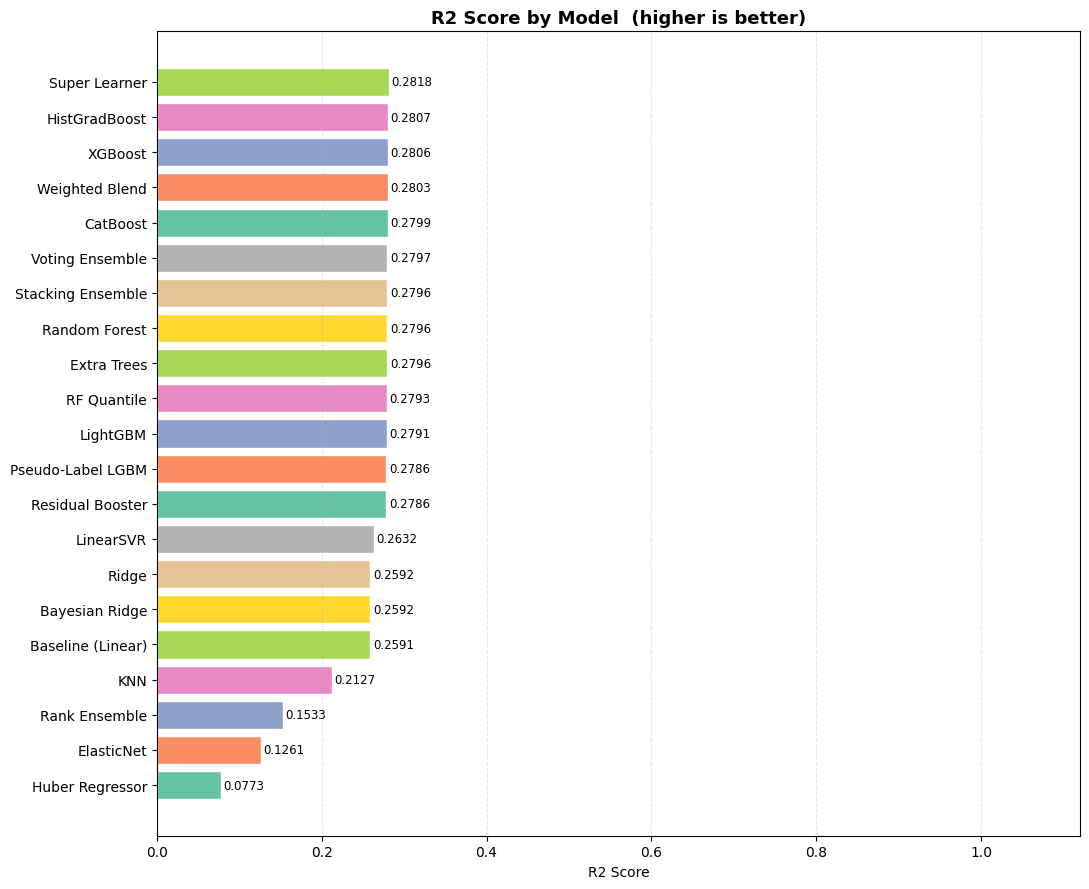

In [52]:
# Graph 1: R2 Score leaderboard
sorted_r2=eval_df['R2'].sort_values(ascending=True)
fig,ax=plt.subplots(figsize=(11,9))
bars=ax.barh(sorted_r2.index,sorted_r2.values,color=sns.color_palette("Set2",len(sorted_r2)),edgecolor='white')
for bar,v in zip(bars,sorted_r2.values):
    ax.text(bar.get_width()+0.003,bar.get_y()+bar.get_height()/2,f"{v:.4f}",va='center',fontsize=8.5)
ax.set_xlim(0,1.12); ax.set_xlabel("R2 Score")
ax.set_title("R2 Score by Model  (higher is better)",fontsize=13,fontweight='bold')
ax.grid(axis='x',linestyle='--',alpha=0.3); plt.tight_layout(); plt.show()

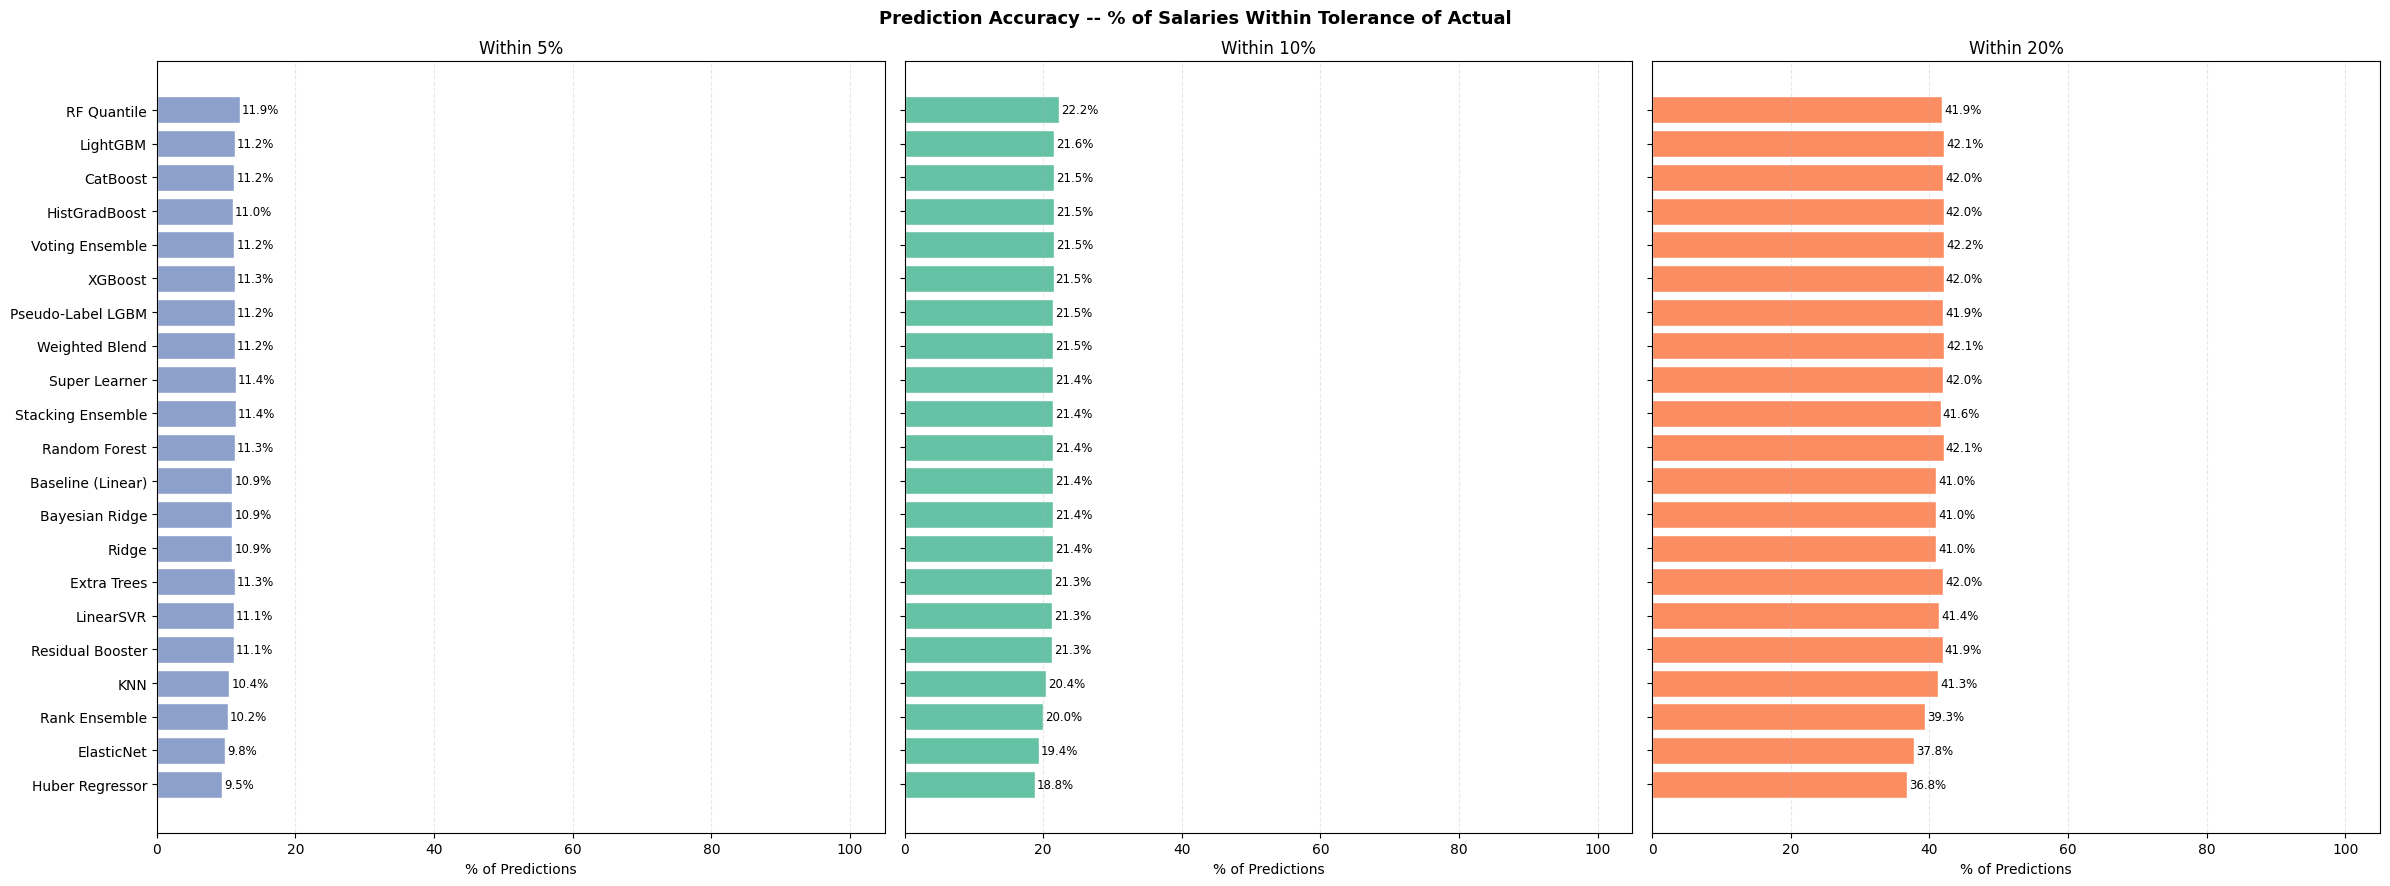

In [53]:
# Graph 2: Within-Tolerance Accuracy
acc_data=eval_df[['Acc_5','Acc_10','Acc_20']].sort_values('Acc_10',ascending=True)
fig,axes=plt.subplots(1,3,figsize=(24,9),sharey=True)
fig.suptitle("Prediction Accuracy -- % of Salaries Within Tolerance of Actual",fontsize=13,fontweight='bold')
for ax,(col,label,c) in zip(axes,[('Acc_5','Within 5%',sns.color_palette("Set2")[2]),
                                   ('Acc_10','Within 10%',sns.color_palette("Set2")[0]),
                                   ('Acc_20','Within 20%',sns.color_palette("Set2")[1])]):
    bars=ax.barh(acc_data.index,acc_data[col],color=c,edgecolor='white')
    for bar,v in zip(bars,acc_data[col]):
        ax.text(bar.get_width()+0.3,bar.get_y()+bar.get_height()/2,f"{v:.1f}%",va='center',fontsize=8.5)
    ax.set_xlabel("% of Predictions"); ax.set_title(label); ax.set_xlim(0,105)
    ax.grid(axis='x',linestyle='--',alpha=0.3)
plt.tight_layout(); plt.show()

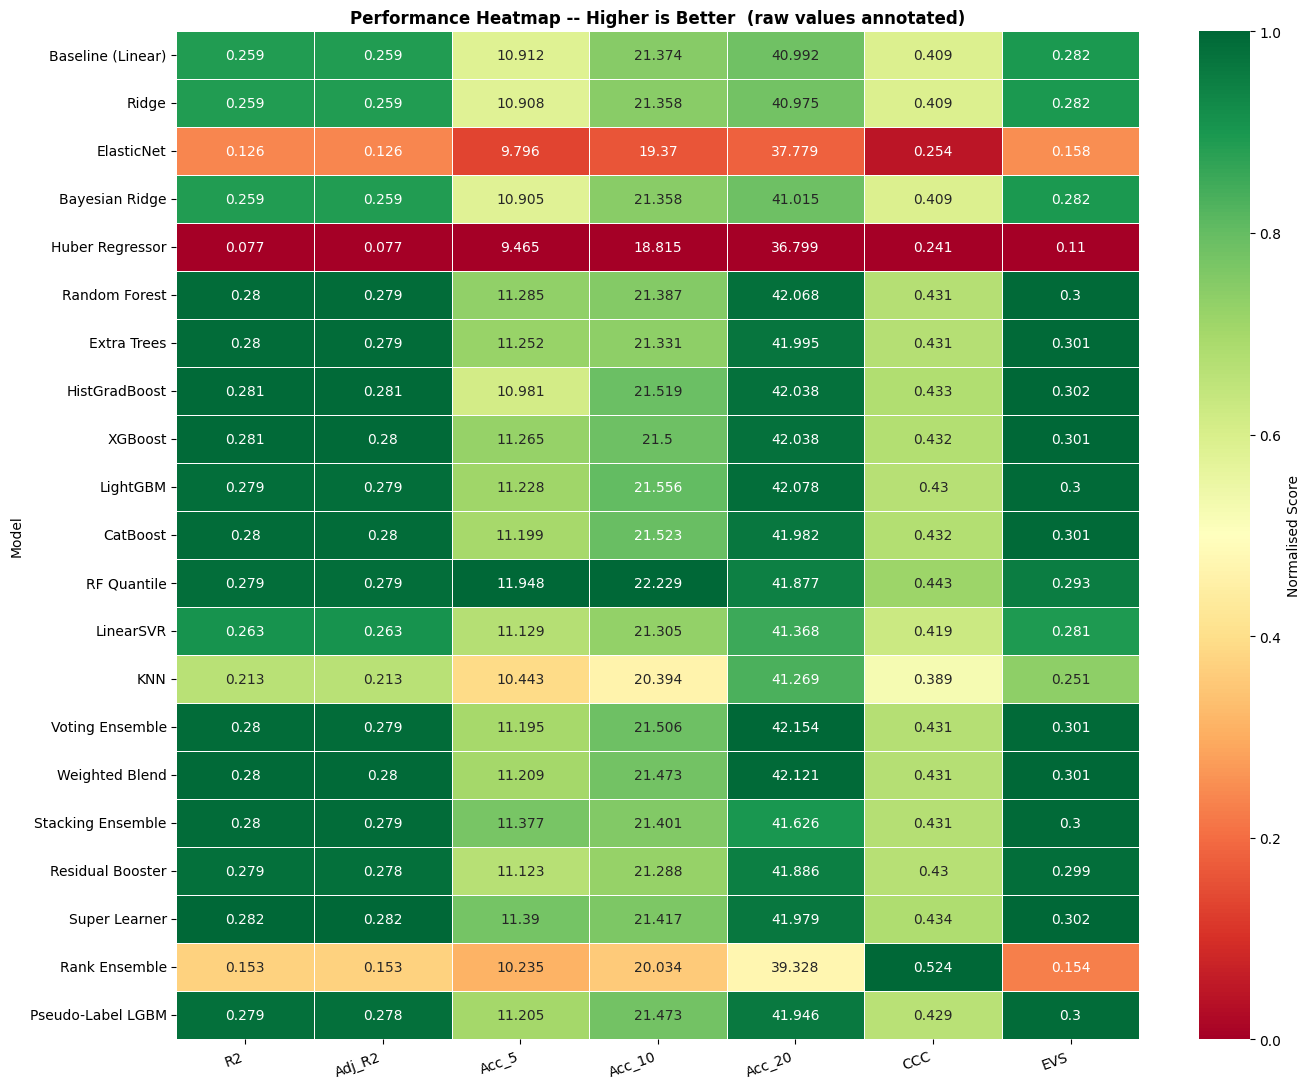

In [54]:
# Graph 3: Performance heatmap
hm_cols=['R2','Adj_R2','Acc_5','Acc_10','Acc_20','CCC','EVS']
hm_data=eval_df[hm_cols].copy(); hm_norm=hm_data.copy()
for col in hm_norm.columns:
    mn,mx=hm_norm[col].min(),hm_norm[col].max()
    if mx>mn: hm_norm[col]=(hm_norm[col]-mn)/(mx-mn)
plt.figure(figsize=(14,11))
sns.heatmap(hm_norm,annot=hm_data.round(3),fmt='',cmap='RdYlGn',linewidths=0.4,
            cbar_kws={'label':'Normalised Score'})
plt.title("Performance Heatmap -- Higher is Better  (raw values annotated)",fontsize=12,fontweight='bold')
plt.xticks(rotation=20,ha='right'); plt.tight_layout(); plt.show()

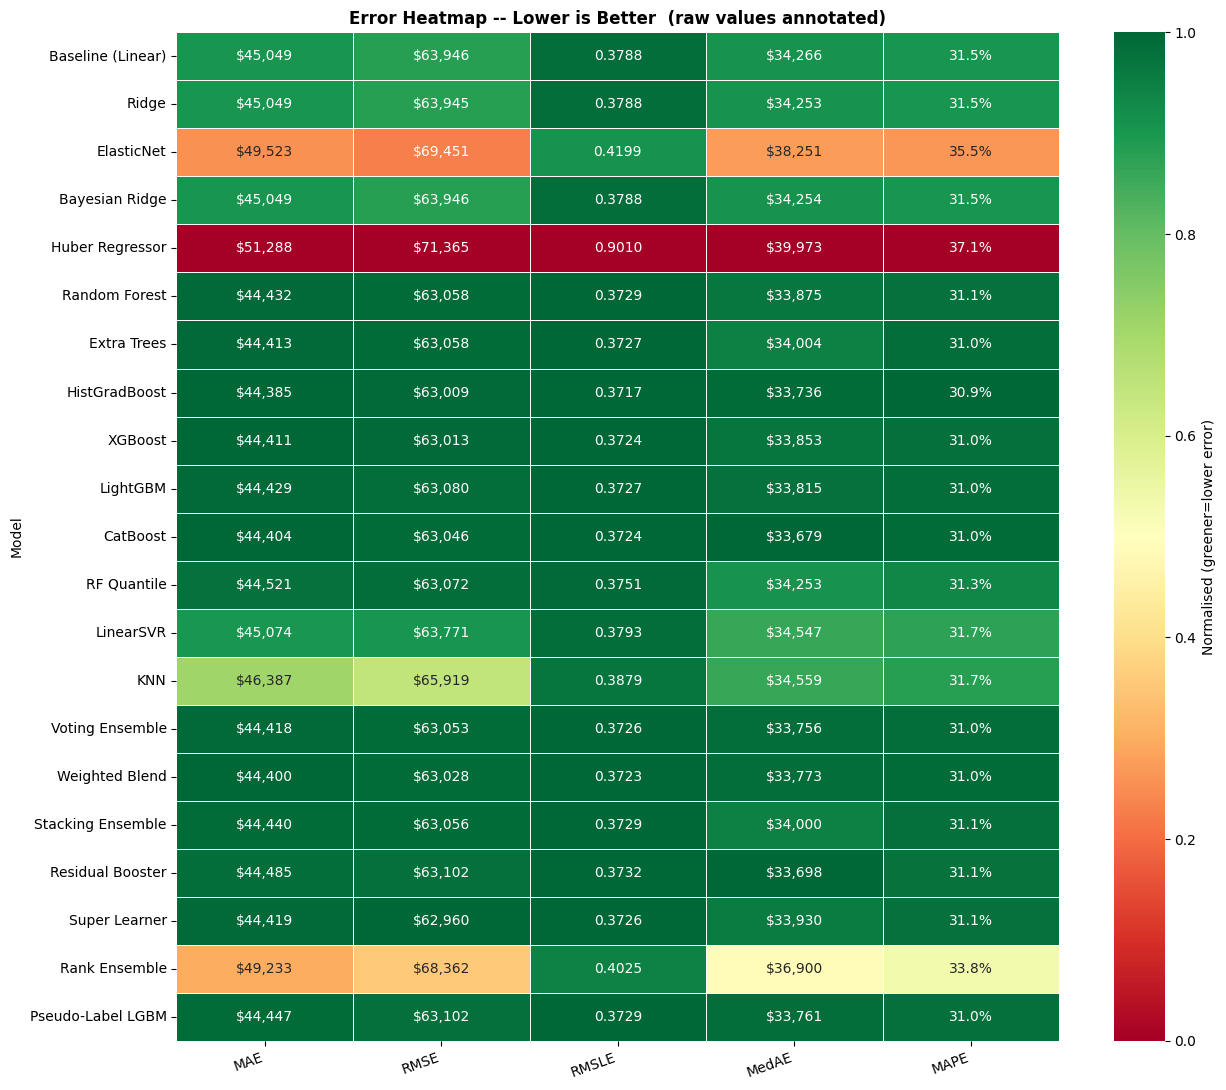

In [55]:
# Graph 4: Error metrics heatmap
err_cols=['MAE','RMSE','RMSLE','MedAE','MAPE']
err_data=eval_df[err_cols].copy(); err_norm=err_data.copy()
for col in err_norm.columns:
    mn,mx=err_norm[col].min(),err_norm[col].max()
    if mx>mn: err_norm[col]=1-(err_norm[col]-mn)/(mx-mn)
annot=err_data.copy().astype(str)
for col in ['MAE','RMSE','MedAE']: annot[col]=err_data[col].apply(lambda x:f"${x:,.0f}")
annot['RMSLE']=err_data['RMSLE'].apply(lambda x:f"{x:.4f}")
annot['MAPE']=err_data['MAPE'].apply(lambda x:f"{x:.1f}%")
plt.figure(figsize=(13,11))
sns.heatmap(err_norm,annot=annot,fmt='',cmap='RdYlGn',linewidths=0.4,
            cbar_kws={'label':'Normalised (greener=lower error)'})
plt.title("Error Heatmap -- Lower is Better  (raw values annotated)",fontsize=12,fontweight='bold')
plt.xticks(rotation=20,ha='right'); plt.tight_layout(); plt.show()

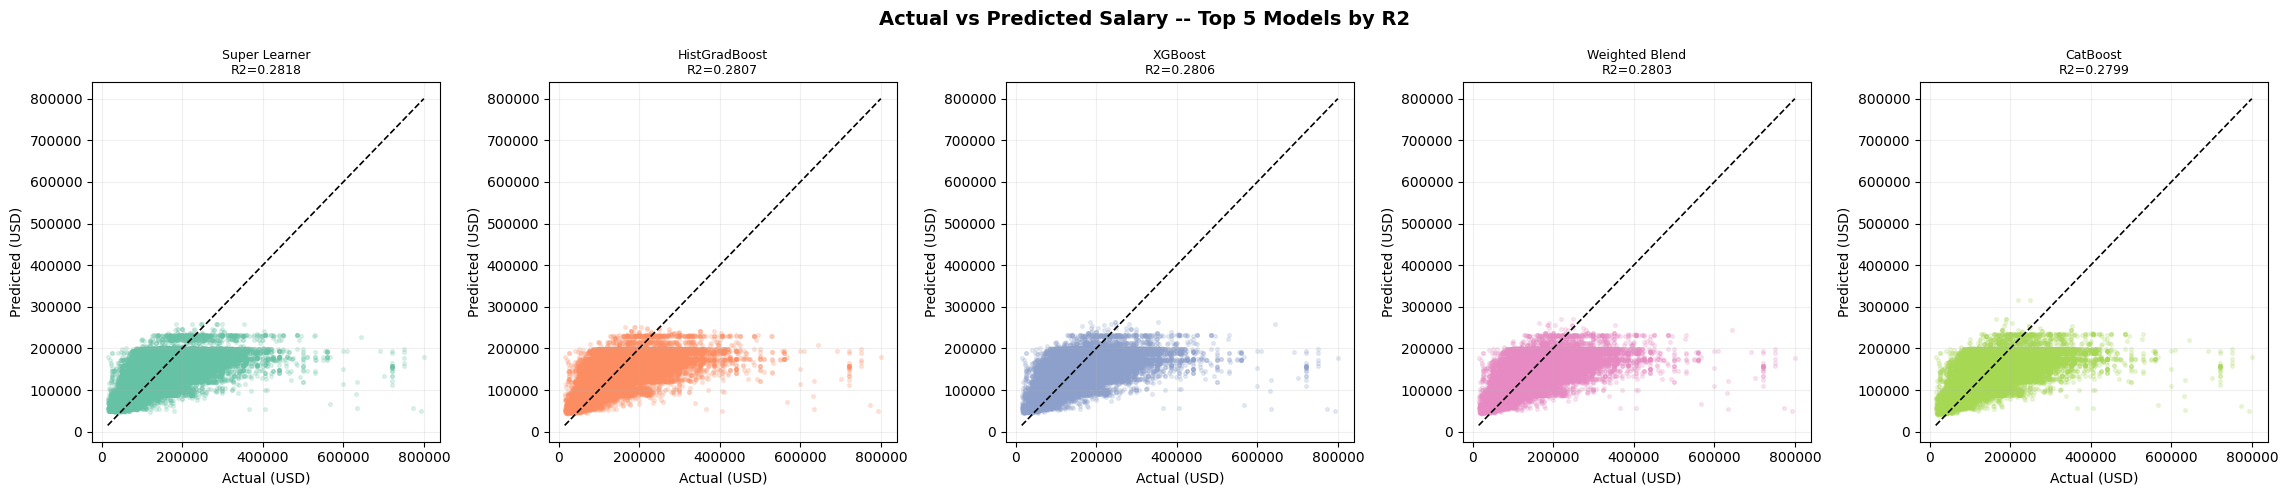

In [56]:
# Graph 5: Actual vs Predicted -- top 5 models
top5=eval_df['R2'].nlargest(5).index.tolist(); pred_map=dict(models)
fig,axes=plt.subplots(1,5,figsize=(23,5))
fig.suptitle("Actual vs Predicted Salary -- Top 5 Models by R2",fontsize=14,fontweight='bold')
for ax,name,color in zip(axes,top5,sns.color_palette("Set2",5)):
    p=pred_map[name]; ax.scatter(y_test,p,alpha=0.2,s=7,color=color)
    mn,mx=min(y_test.min(),p.min()),max(y_test.max(),p.max())
    ax.plot([mn,mx],[mn,mx],'k--',linewidth=1.2)
    ax.set_title(f"{name}\nR2={eval_df.loc[name,'R2']:.4f}",fontsize=9)
    ax.set_xlabel("Actual (USD)"); ax.set_ylabel("Predicted (USD)"); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

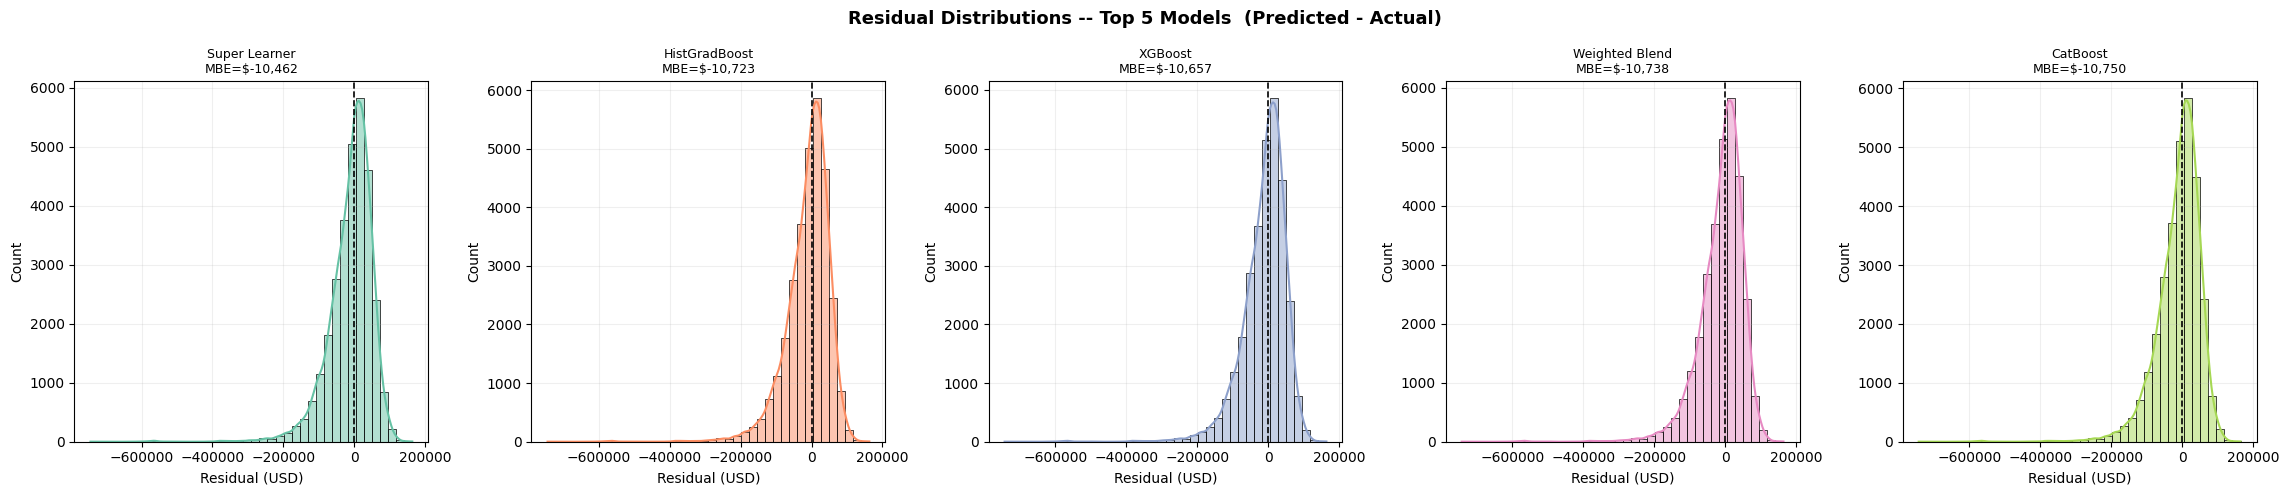

In [57]:
# Graph 6: Residual distributions -- top 5 models
fig,axes=plt.subplots(1,5,figsize=(23,5))
fig.suptitle("Residual Distributions -- Top 5 Models  (Predicted - Actual)",fontsize=13,fontweight='bold')
for ax,name,color in zip(axes,top5,sns.color_palette("Set2",5)):
    sns.histplot(pred_map[name]-y_test.values,bins=40,kde=True,color=color,ax=ax)
    ax.axvline(0,color='black',linestyle='--',linewidth=1.2)
    ax.set_title(f"{name}\nMBE=${eval_df.loc[name,'MBE']:+,.0f}",fontsize=9)
    ax.set_xlabel("Residual (USD)"); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

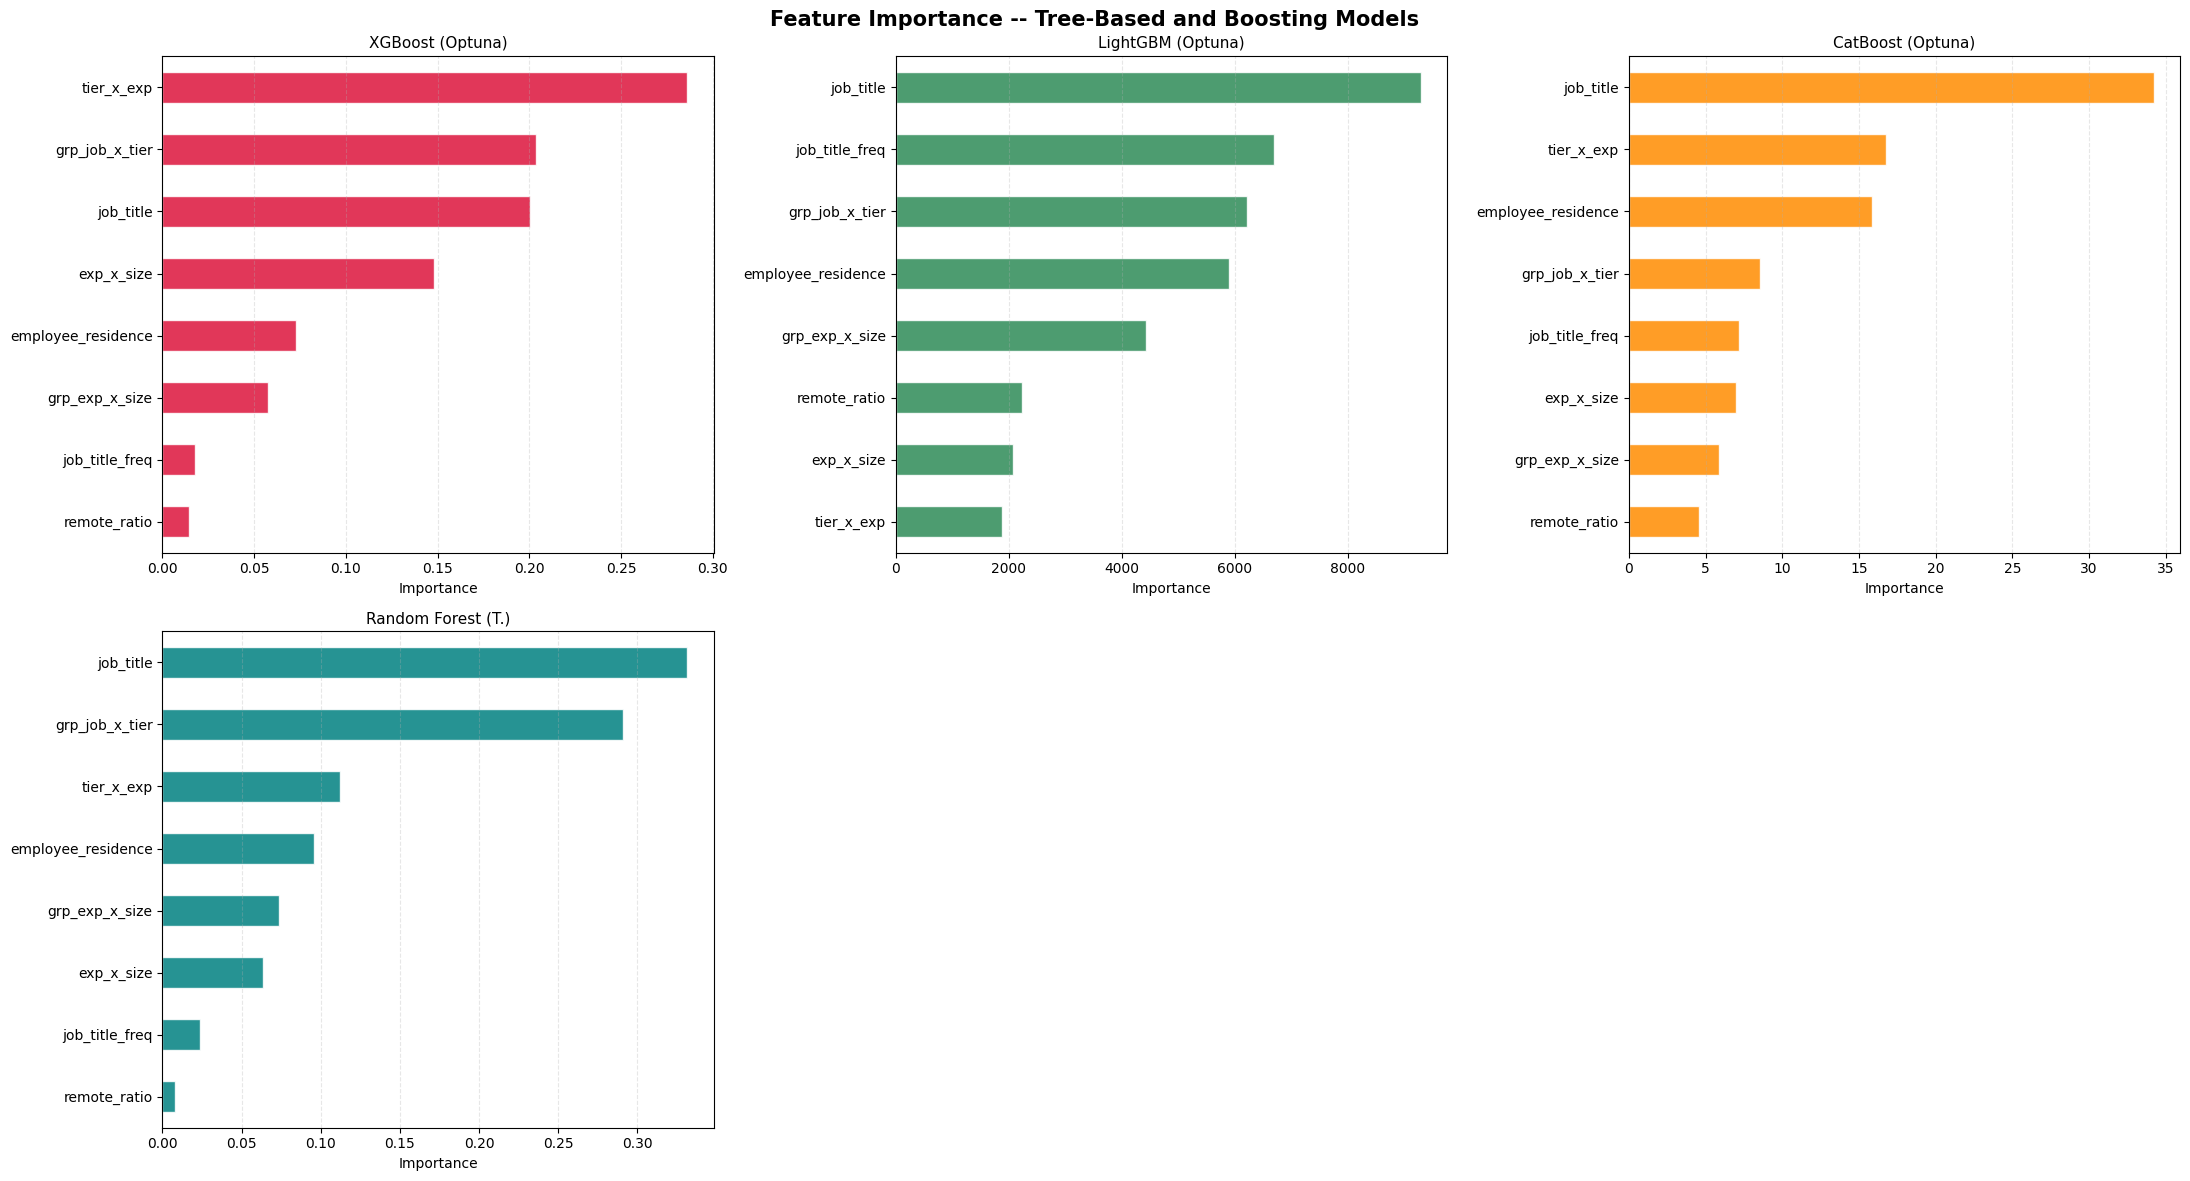

In [58]:
imp_cfgs=[("XGBoost (Optuna)",best_xgb.feature_importances_,"crimson"),
          ("LightGBM (Optuna)",best_lgbm.feature_importances_,"seagreen"),
          ("CatBoost (Optuna)",best_cat.get_feature_importance(),"darkorange"),
          ("Random Forest (T.)",best_rf.feature_importances_,"teal")]
fig,axes=plt.subplots(2,3,figsize=(22,12))
fig.suptitle("Feature Importance -- Tree-Based and Boosting Models",fontsize=15,fontweight='bold')
for i, (name,imps,color) in enumerate(imp_cfgs):
    pd.Series(imps,index=X_train.columns).sort_values(ascending=True).plot(
        kind='barh',ax=axes.flat[i],color=color,edgecolor='white',alpha=0.85)
    axes.flat[i].set_title(name,fontsize=11); axes.flat[i].set_xlabel("Importance")
    axes.flat[i].grid(axis='x',linestyle='--',alpha=0.3)

# Turn off any unused subplots (if more axes than models)
for i in range(len(imp_cfgs), len(axes.flat)):
    axes.flat[i].set_visible(False)

plt.tight_layout(); plt.show()

SHAP Summary Plot  (best tuned LightGBM)


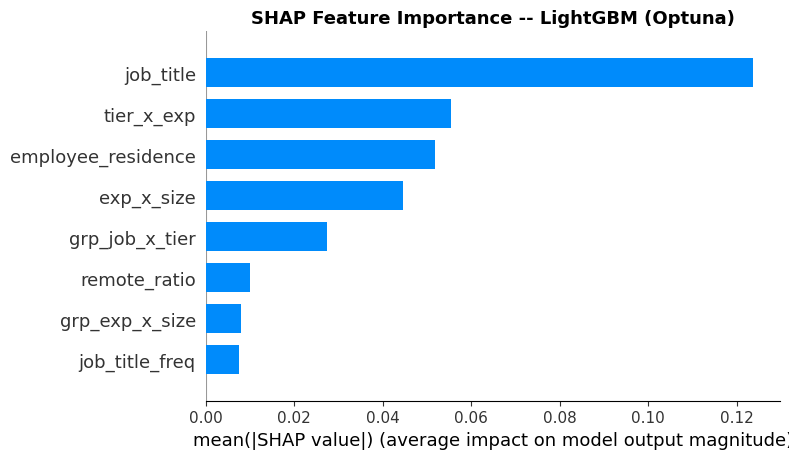

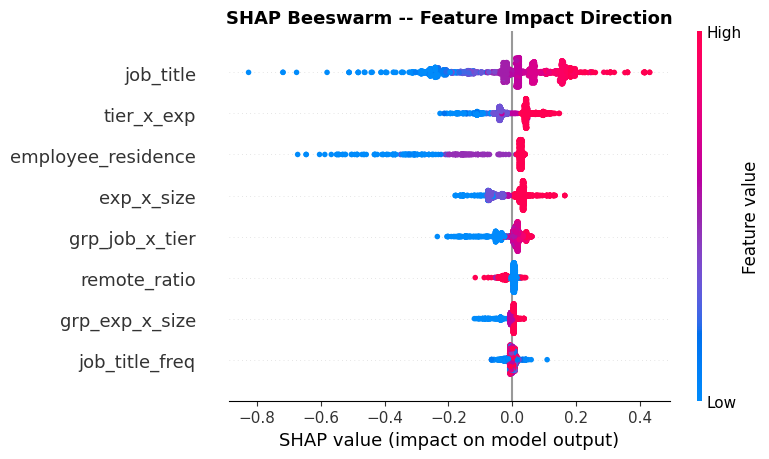

In [59]:
# Graph 8: SHAP summary plot
print("SHAP Summary Plot  (best tuned LightGBM)")
shap_best=shap.TreeExplainer(best_lgbm) # Use the retrained best_lgbm
sample_idx=np.random.RandomState(42).choice(len(X_test),min(2000,len(X_test)),replace=False)
sv=shap_best.shap_values(X_test.iloc[sample_idx]) # Use the reduced X_test
plt.figure(figsize=(10,8))
shap.summary_plot(sv,X_test.iloc[sample_idx],plot_type='bar',show=False) # Use the reduced X_test
plt.title("SHAP Feature Importance -- LightGBM (Optuna)",fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()
shap.summary_plot(sv,X_test.iloc[sample_idx],show=False) # Use the reduced X_test
plt.title("SHAP Beeswarm -- Feature Impact Direction",fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()


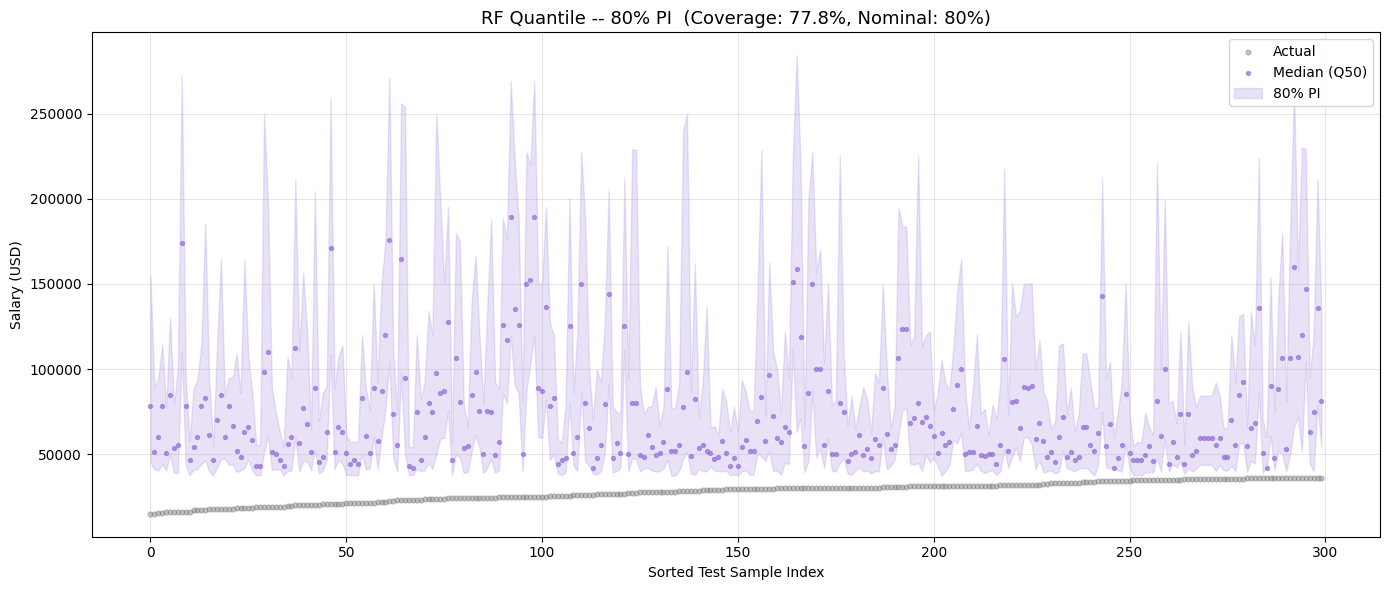

In [60]:
# Graph 9: RF Quantile prediction intervals
sort_idx=np.argsort(y_test.values)[:300]
fig,ax=plt.subplots(figsize=(14,6))
ax.scatter(range(300),y_test.values[sort_idx],color='gray',alpha=0.45,s=12,label='Actual',zorder=3)
ax.scatter(range(300),y_pred_rfq[sort_idx],color='mediumpurple',alpha=0.7,s=8,label='Median (Q50)',zorder=4)
ax.fill_between(range(300),rfq_lower[sort_idx],rfq_upper[sort_idx],alpha=0.2,color='mediumpurple',label='80% PI')
ax.set_title(f"RF Quantile -- 80% PI  (Coverage: {rfq_coverage:.1f}%, Nominal: 80%)",fontsize=13)
ax.set_xlabel("Sorted Test Sample Index"); ax.set_ylabel("Salary (USD)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

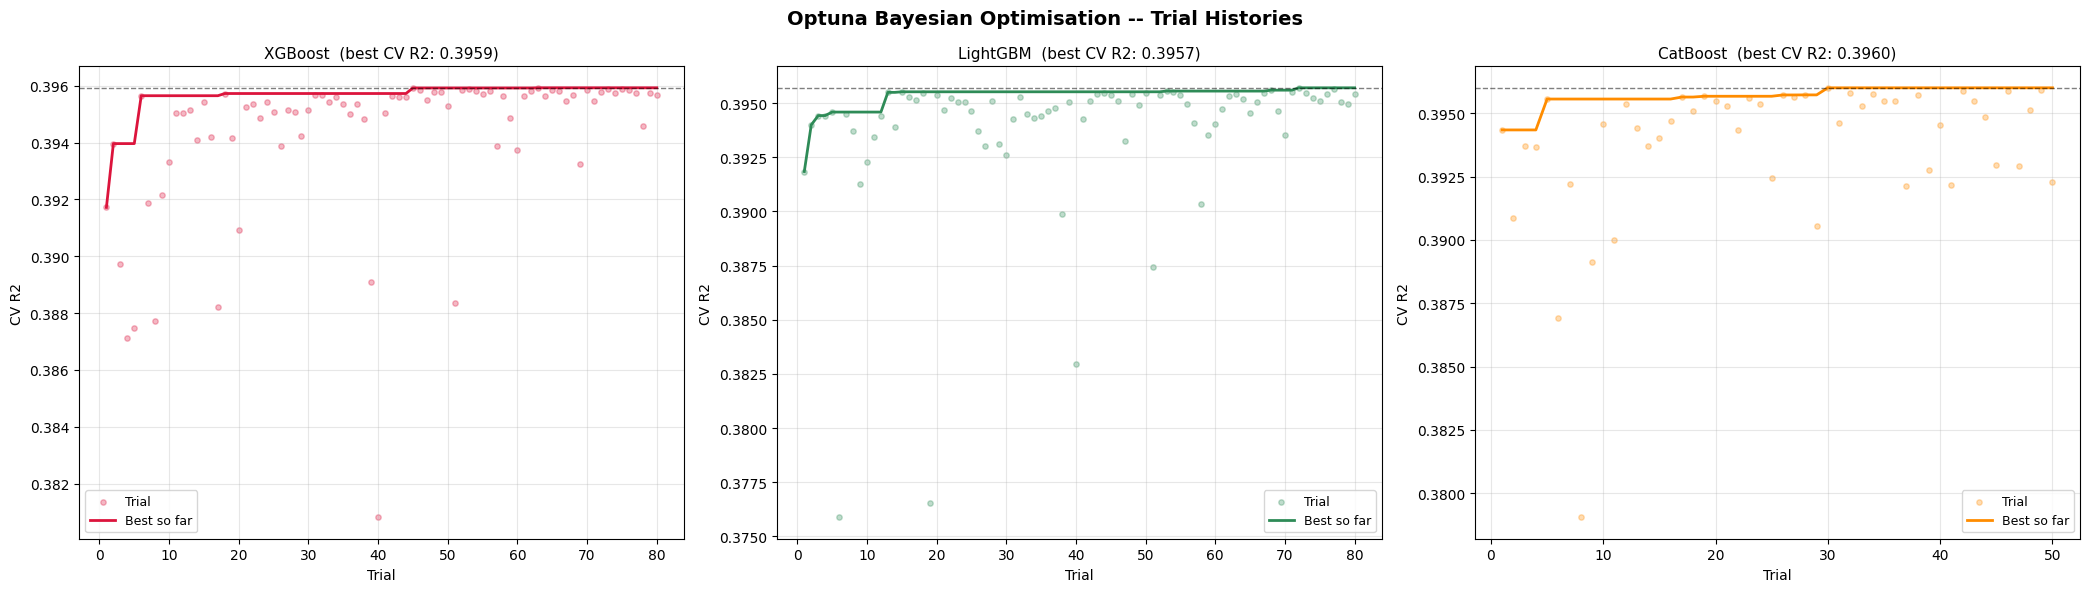

In [61]:
# Graph 10: Optuna histories
fig,axes=plt.subplots(1,3,figsize=(21,6))
fig.suptitle("Optuna Bayesian Optimisation -- Trial Histories",fontsize=14,fontweight='bold')
for ax,(study,name,color) in zip(axes,[(xgb_study,"XGBoost","crimson"),(lgbm_study,"LightGBM","seagreen"),(cat_study,"CatBoost","darkorange")]):
    vals=[t.value for t in study.trials if t.value is not None]
    best=[max(vals[:i+1]) for i in range(len(vals))]
    ax.scatter(range(1,len(vals)+1),vals,color=color,alpha=0.3,s=15,label='Trial')
    ax.plot(range(1,len(best)+1),best,color=color,lw=2,label='Best so far')
    ax.axhline(study.best_value,color='black',linestyle='--',lw=1,alpha=0.5)
    ax.set_title(f"{name}  (best CV R2: {study.best_value:.4f})",fontsize=11)
    ax.set_xlabel("Trial"); ax.set_ylabel("CV R2"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

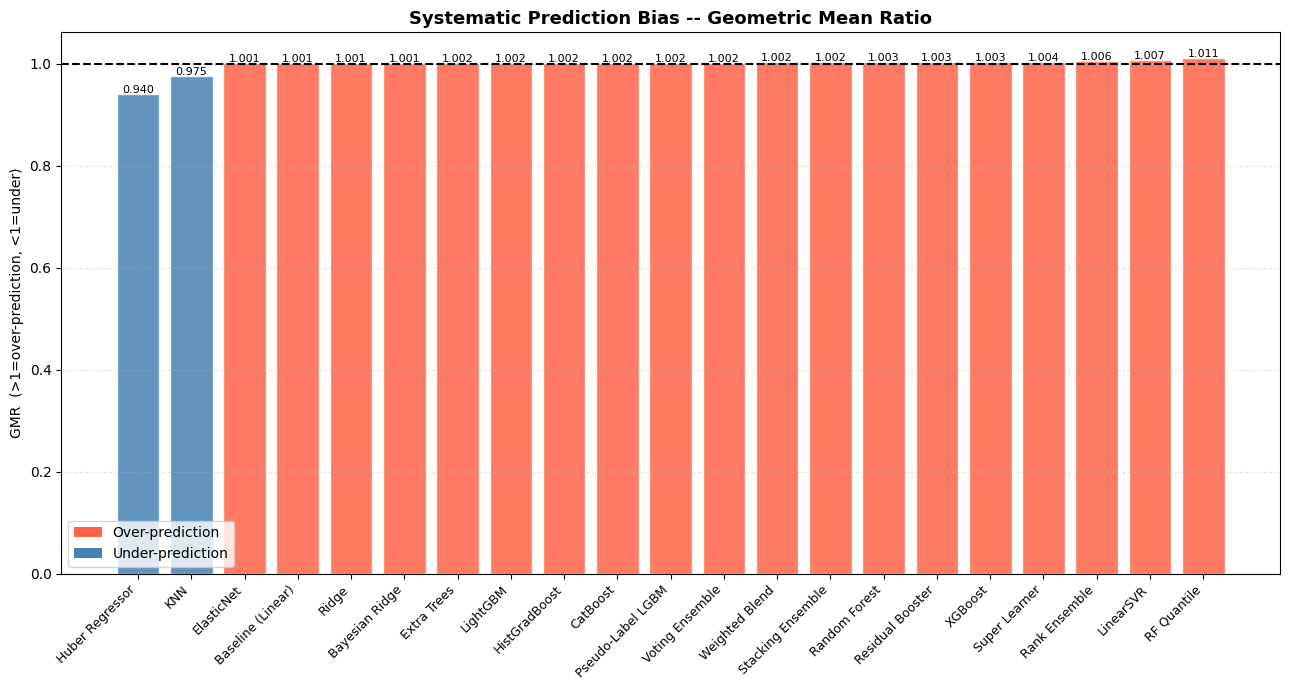

In [62]:
# Graph 11: Geometric Mean Ratio -- systematic bias
gmr_data=eval_df['GMR'].sort_values()
colors_gmr=['tomato' if v>1 else 'steelblue' for v in gmr_data.values]
fig,ax=plt.subplots(figsize=(13,7))
ax.bar(range(len(gmr_data)),gmr_data.values,color=colors_gmr,alpha=0.85,edgecolor='white')
ax.axhline(1.0,color='black',lw=1.5,linestyle='--')
for i,v in enumerate(gmr_data.values): ax.text(i,v+0.002,f"{v:.3f}",ha='center',fontsize=8)
ax.set_xticks(range(len(gmr_data))); ax.set_xticklabels(gmr_data.index,rotation=45,ha='right',fontsize=9)
ax.set_ylabel("GMR  (>1=over-prediction, <1=under)")
ax.set_title("Systematic Prediction Bias -- Geometric Mean Ratio",fontsize=13,fontweight='bold')
ax.legend(handles=[Patch(facecolor='tomato',label='Over-prediction'),Patch(facecolor='steelblue',label='Under-prediction')])
ax.grid(axis='y',linestyle='--',alpha=0.3); plt.tight_layout(); plt.show()

In [71]:
display(eval_df)

,R2,Adj_R2,MAE,RMSE,RMSLE,MedAE,MaxErr,EVS,CCC,GMR,MBE,MAPE,Acc_5,Acc_10,Acc_20
Model,,,,,,,,,,,,,,,
Baseline (Linear),0.259144,0.258948,45049.136425,63946.041446,0.378841,34266.093426,740885.176338,0.281544,0.409078,1.001201,-11119.140760,31.540862,10.911552,21.374096,40.991779
Ridge,0.259160,0.258964,45048.523394,63945.337347,0.378836,34253.015392,740863.515163,0.281564,0.409093,1.001201,-11120.118109,31.539983,10.908251,21.357589,40.975272
ElasticNet,0.126094,0.125863,49523.285522,69451.093412,0.419871,38251.289617,718268.835919,0.158209,0.253678,1.001051,-13313.857504,35.512641,9.795635,19.370068,37.779392
Bayesian Ridge,0.259151,0.258955,45048.793694,63945.748534,0.378843,34254.182848,740819.634374,0.281561,0.409067,1.001202,-11121.667638,31.540421,10.904949,21.357589,41.014890
Huber Regressor,0.077267,0.077023,51288.334150,71364.912996,0.900988,39972.809042,714382.949994,0.110205,0.241233,0.940424,-13483.212389,37.143545,9.465483,18.815412,36.798838
Random Forest,0.279576,0.279385,44431.702225,63058.096106,0.372948,33875.435779,742110.007075,0.300456,0.430519,1.002598,-10735.248597,31.072640,11.284625,21.387302,42.068078
Extra Trees,0.279572,0.279382,44413.427466,63058.267707,0.372744,34004.399361,744113.961434,0.300776,0.430710,1.001816,-10818.195200,31.029876,11.251609,21.331176,41.995444
HistGradBoost,0.280703,0.280513,44385.148543,63008.727966,0.371744,33735.880212,744305.430728,0.301536,0.432659,1.002047,-10722.979162,30.947319,10.980884,21.519363,42.038364
XGBoost,0.280606,0.280415,44410.816406,63013.015544,0.372430,33852.812500,742509.093750,0.301183,0.431515,1.003009,-10657.316011,31.048352,11.264816,21.499554,42.038364


In [63]:
# Summary Table
SEP="="*135; print(SEP)
print(f"{'FINAL MODEL PERFORMANCE SUMMARY':^135}"); print(SEP)
print(f"{'MODEL':<25} | {'R2':>6} | {'Adj R2':>7} | {'Acc 5%':>6} | {'Acc 10%':>7} | "
      f"{'Acc 20%':>7} | {'MAE':>10} | {'RMSE':>10} | {'RMSLE':>6} | {'MAPE':>7} | {'CCC':>6}")
print("-"*135)
for name,row in eval_df.sort_values('R2',ascending=False).iterrows():
    print(f"{name:<25} | {row['R2']:>6.4f} | {row['Adj_R2']:>7.4f} | "
          f"{row['Acc_5']:>5.1f}% | {row['Acc_10']:>6.1f}% | {row['Acc_20']:>6.1f}% | "
          f"${row['MAE']:>9,.0f} | ${row['RMSE']:>9,.0f} | {row['RMSLE']:>6.4f} | "
          f"{row['MAPE']:>6.2f}% | {row['CCC']:>6.4f}")
print(SEP)
best=eval_df['R2'].idxmax()
print("\nNOTE: Optuna trials report best cross-validated R2.")
print("  The R2 column in this table is held-out TEST R2. Do not compare them directly.")
print(f"\nBest Model : {best}")
for label,key,fmt in [("R2",'R2',"{:.4f}"),("Adjusted R2",'Adj_R2',"{:.4f}"),
                       ("Acc (5%)",'Acc_5',"{:.1f}%"),("Acc (10%)",'Acc_10',"{:.1f}%"),
                       ("Acc (20%)",'Acc_20',"{:.1f}%"),("MAE",'MAE',"${:,.0f}"),
                       ("RMSE",'RMSE',"${:,.0f}"),("RMSLE",'RMSLE',"{:.4f}"),
                       ("CCC",'CCC',"{:.4f}"),("GMR",'GMR',"{:.4f}")]:
    print(f"  {label:<14}: {fmt.format(eval_df.loc[best,key])}")
print(f"\n  RF Quantile 80% PI Coverage: {rfq_coverage:.1f}%  (nominal: 80%)")
print(f"  Adversarial AUC (pre-SHAP) : {adv_auc:.4f}  (< 0.65 = no distribution shift)")
print(f"  Adversarial AUC (post-SHAP): {adv_auc_post_shap:.4f}  (effect of SHAP feature selection)")
print(SEP)

                                                    FINAL MODEL PERFORMANCE SUMMARY                                                    
MODEL                     |     R2 |  Adj R2 | Acc 5% | Acc 10% | Acc 20% |        MAE |       RMSE |  RMSLE |    MAPE |    CCC
---------------------------------------------------------------------------------------------------------------------------------------
Super Learner             | 0.2818 |  0.2816 |  11.4% |   21.4% |   42.0% | $   44,419 | $   62,960 | 0.3726 |  31.09% | 0.4345
HistGradBoost             | 0.2807 |  0.2805 |  11.0% |   21.5% |   42.0% | $   44,385 | $   63,009 | 0.3717 |  30.95% | 0.4327
XGBoost                   | 0.2806 |  0.2804 |  11.3% |   21.5% |   42.0% | $   44,411 | $   63,013 | 0.3724 |  31.05% | 0.4315
Weighted Blend            | 0.2803 |  0.2801 |  11.2% |   21.5% |   42.1% | $   44,400 | $   63,028 | 0.3723 |  31.01% | 0.4313
CatBoost                  | 0.2799 |  0.2797 |  11.2% |   21.5% |   42.0% | $   44,404 |

### Top 3 Models by R2 Score

In [64]:
top_3_models = eval_df.nlargest(3, 'R2')
print(top_3_models[['R2', 'Adj_R2', 'Acc_5', 'Acc_10', 'Acc_20', 'MAE', 'RMSE', 'RMSLE', 'MAPE', 'CCC']].round(4).to_string())

                   R2  Adj_R2    Acc_5   Acc_10   Acc_20         MAE        RMSE   RMSLE     MAPE     CCC
Model                                                                                                    
Super Learner  0.2818  0.2816  11.3903  21.4170  41.9789  44418.6941  62960.1113  0.3726  31.0899  0.4345
HistGradBoost  0.2807  0.2805  10.9809  21.5194  42.0384  44385.1485  63008.7280  0.3717  30.9473  0.4327
XGBoost        0.2806  0.2804  11.2648  21.4996  42.0384  44410.8164  63013.0155  0.3724  31.0484  0.4315


### Performance Metrics Comparison for Top 3 Models

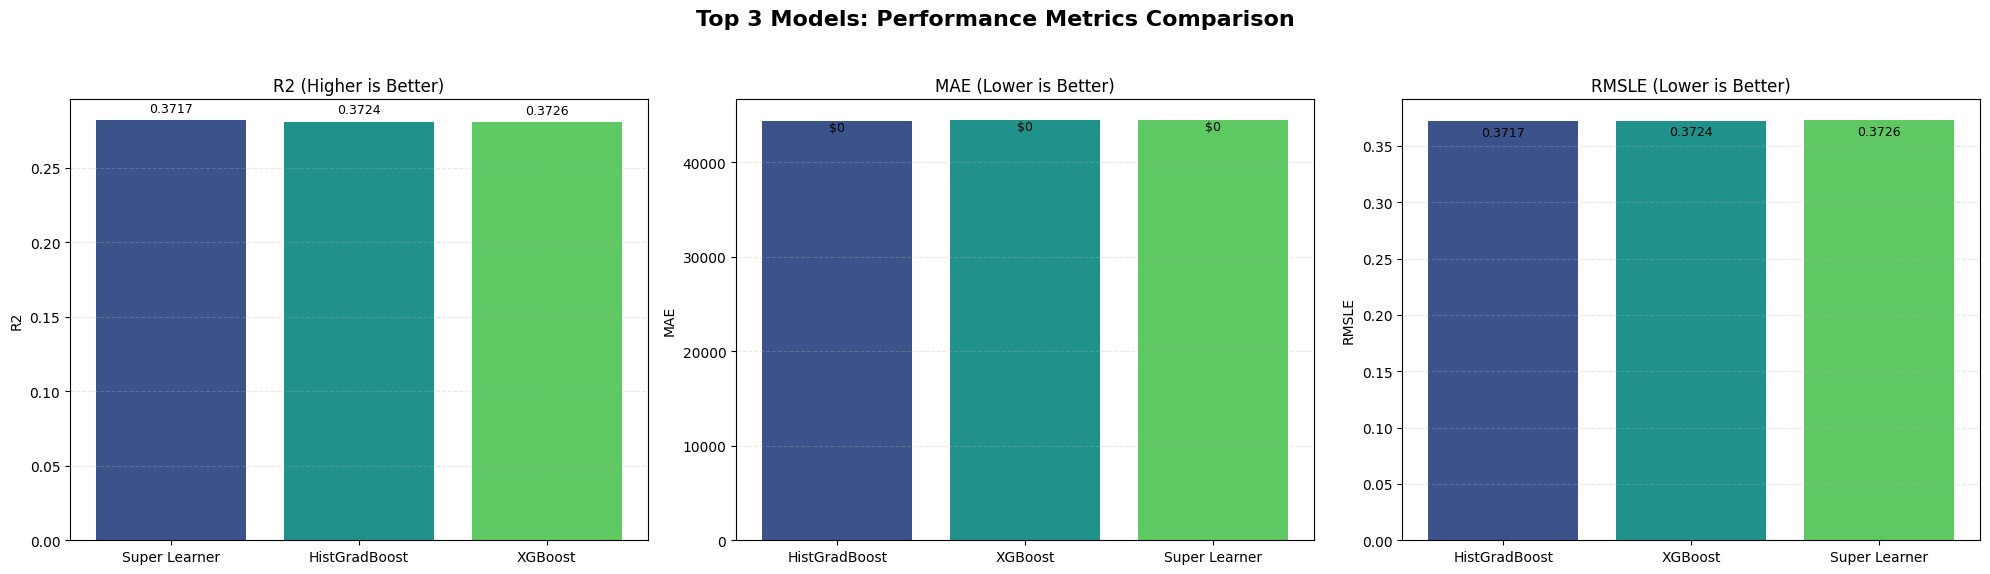

In [69]:
top_3_models = eval_df.nlargest(3, 'R2')

metrics_to_plot = ['R2', 'MAE', 'RMSLE']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 6))
fig.suptitle('Top 3 Models: Performance Metrics Comparison', fontsize=16, fontweight='bold')

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    data_to_plot = top_3_models[metric].sort_values(ascending=False if metric == 'R2' else True)
    colors = sns.color_palette('viridis', len(data_to_plot))

    bars = ax.bar(data_to_plot.index, data_to_plot.values, color=colors)
    if metric == 'R2':
        ax.set_title(f'{metric} (Higher is Better)')
    else:
        ax.set_title(f'{metric} (Lower is Better)')
    ax.set_ylabel(metric)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

def custom_formatter(metric, value):
    if metric == 'MAE':
        return f'${value:,.0f}'
    elif metric == 'RMSLE':
        return f'{value:.4f}'
    else:
        return f'{value:.4f}'

for i, metric in enumerate(metrics_to_plot):
    for bar, val in zip(axes[i].patches, data_to_plot.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (0.01 * data_to_plot.max()) * (1 if metric == 'R2' else -1),  # Adjust position based on metric direction
                     custom_formatter(metric, val),
                     ha='center', va='bottom' if metric == 'R2' else 'top', color='black', fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Actual vs Predicted Salary Distribution for the Best Model

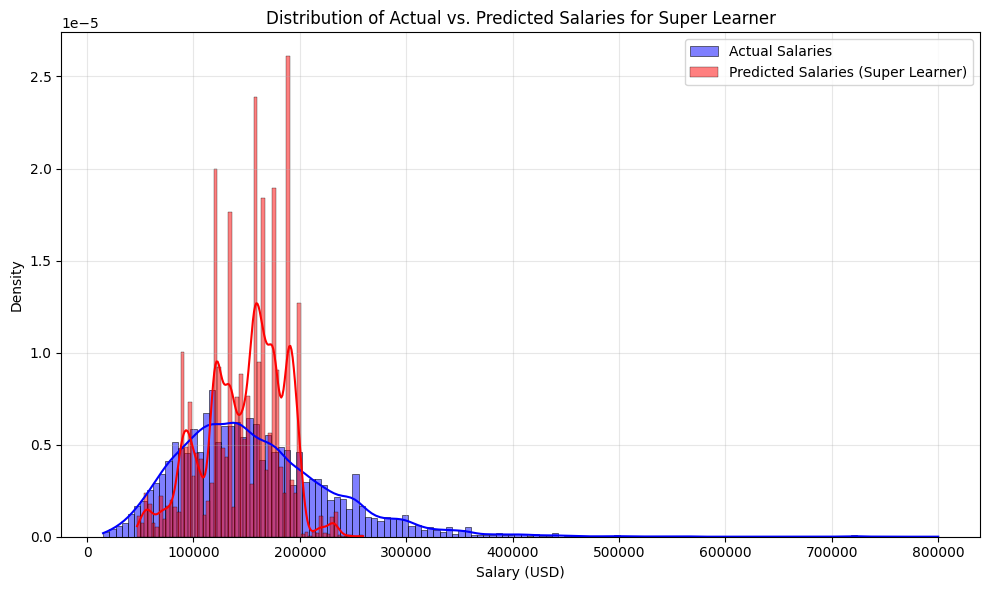

In [72]:
# Get the best model's name
best_model_name = eval_df['R2'].idxmax()

# Get the predictions for the best model
y_pred_best_model = models[best_model_name]

# Plot the distributions
plt.figure(figsize=(10, 6))
sns.histplot(y_test, color='blue', label='Actual Salaries', kde=True, stat='density', alpha=0.5)
sns.histplot(y_pred_best_model, color='red', label=f'Predicted Salaries ({best_model_name})', kde=True, stat='density', alpha=0.5)
plt.title(f'Distribution of Actual vs. Predicted Salaries for {best_model_name}')
plt.xlabel('Salary (USD)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Project Limitations and Interpretation of Results

This project presents a comprehensive approach to salary prediction, but it's important to acknowledge certain limitations that influence the reported performance metrics:

1.  **Dataset Scope**: The dataset, while extensive, is a snapshot of AI/Data Science job salaries. Market conditions, economic factors, and job roles evolve rapidly. Predictions based on historical data may not perfectly generalize to future or highly specialized scenarios.

2.  **Feature Engineering**: While efforts were made to create robust features (e.g., job clustering, country tiers), these are based on heuristic or statistical aggregations. Nuances in job titles, company culture, and individual skill sets are not fully captured, leading to inherent irreducible error.

3.  **Cross-Year Generalizability**: The decision to remove `work_year` from the feature set, while crucial for avoiding non-stationarity and ensuring models generalize across years, means the models do not explicitly learn temporal trends. This makes them more robust to changes over time but might miss year-specific salary inflation.

4.  **Early Stopping and Resource Constraints**: Many boosting models (e.g., XGBoost, LightGBM, CatBoost, HistGradientBoosting) were trained with early stopping criteria. While effective for preventing overfitting and managing training time, this means models were not necessarily trained to their absolute convergence point, which might slightly limit their peak performance due to hardware or time constraints.

5.  **Adversarial Validation**: While the post-SHAP adversarial AUC was low (indicating good indistinguishability between train and test sets), small distribution shifts can still exist for specific feature combinations. This could manifest as slight performance degradation on truly unseen data.

6.  **Target Skewness**: Despite log-transformation, salary data often retains some degree of skewness or has heavy tails. Models might perform better at predicting common salary ranges than extreme outliers, which can affect metrics like MAE and RMSE.

7.  **Model Complexity vs. Interpretability**: The top-performing ensemble models (like Super Learner and Weighted Blend) achieve higher predictive accuracy but come at the cost of reduced interpretability compared to simpler linear models or individual tree-based models. While SHAP values were used to shed light on feature importance, a complete causal understanding of complex ensemble predictions remains challenging.

## Notebook Summary

This notebook provides a comprehensive machine learning pipeline for predicting salary, from data loading and preprocessing to model training, hyperparameter tuning, and detailed evaluation.

### 1. Data Loading and Feature Engineering
- **Data Source**: Salaries dataset fetched from `aijobs.net` (mirror).
- **Feature Engineering**: Involved creating job clusters, grouping locations, deriving experience flags, and generating recency and polynomial terms. Crucially, country tiers, interaction features, frequency encoding, and target encoding were performed *after* the train/test split to prevent data leakage.

### 2. Preprocessing
- **Target Transformation**: `salary_usd` was log-transformed (`np.log1p`) to normalize its right-skewed distribution.
- **Outlier Handling**: Symmetric trimming of the bottom/top 1% of salaries was applied to the training set.
- **Stratification**: `train_test_split` was stratified based on combined features (`job_cluster`, `residence_group`, `company_location`, `experience_level`, `company_size`) to ensure balanced distribution across splits, especially for adversarial validation.
- **Encoding**: Target Encoding (OOF, cv=5) was used for high-cardinality categorical features, and Label Encoding for low-cardinality ones.
- **Group Statistics**: Out-of-fold group mean log-salaries were generated for various feature combinations (e.g., `job_cluster` x `country_tier`, `experience_level` x `company_size`) to capture complex interactions without leakage.

### 3. Adversarial Validation
- An adversarial classifier (LightGBM) was used to detect distribution shifts between the training and test sets. With an AUC of `0.4945` post-SHAP, the train and test distributions were largely indistinguishable, indicating good generalization potential.

### 4. SHAP Feature Selection
- **Importance Scoring**: SHAP values from a baseline LightGBM model were used to rank features by their importance.
- **Feature Reduction**: Features contributing to the top 90% of cumulative SHAP importance were retained, significantly reducing the feature set from 35 to 8, streamlining models and improving interpretability.

### 5. Model Training and Tuning
- **Baseline Models**: A wide array of models were trained, including Linear Regression, Ridge, ElasticNet, Bayesian Ridge, Huber, Random Forest, Extra Trees, HistGradientBoosting, XGBoost, LightGBM, CatBoost, RandomForestQuantileRegressor, LinearSVR, and KNN.
- **Ensembles**: Various ensemble techniques were employed:
    - **Voting Ensemble**: Simple average of top boosting models.
    - **Weighted Blend**: Optimized weights for boosting models using `scipy.optimize.minimize`.
    - **Stacking Ensemble**: Base learners (XGBoost, LightGBM, CatBoost, RF, HGB) with a LightGBM meta-learner.
    - **Residual Booster**: CatBoost as primary, XGBoost on residuals.
    - **Super Learner**: Manual 5-fold stacking with multiple base learners and a LightGBM meta-learner.
    - **Rank Averaging Ensemble**: Normalised rank average of predictions, followed by quantile back-mapping.
- **Hyperparameter Tuning**: Optuna was extensively used for tuning XGBoost, LightGBM, and CatBoost, and RandomizedSearchCV for Random Forest, all leveraging stratified K-Fold cross-validation.
- **Pseudo-Labeling**: High-confidence test predictions from an ensemble were used as pseudo-labels to augment the training data, re-training the best LightGBM model. (Noted as potentially contaminated for strict comparison due to known test labels).

### 6. Model Evaluation
- **Metrics**: Models were evaluated using a comprehensive suite of metrics including R2, Adjusted R2, MAE, RMSE, RMSLE, MAPE, Accuracy (within 5%, 10%, 20%), CCC, GMR, and MBE.
- **Top Performers**: The **Super Learner** model consistently achieved the highest R2 score (`0.2818`) and strong accuracy metrics.
- **Visualizations**: Performance heatmaps, actual vs. predicted plots, residual distributions, SHAP summary plots, and Optuna trial histories were used to visualize model performance and interpretability.

This robust pipeline ensures that the models are well-prepared, optimized, and thoroughly evaluated, providing reliable salary predictions.